# EDA — Part 4: Conditional distributions and stability

Follows county and landcover modes through color-context similarity, conditional distributions, and stability results.


## Optional Colab environment and setup


In [1]:
# Optional Colab environment
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Capstone/Capstone2025_nsi_lvl9_with_landcover_and_color.csv.gz")
df.head()

,h3,fips,st_damcat,bldgtype,lc_type,loc,clr,clr_cc
0,8929a960d6fffff,6047,RES,M,urban+crop,POINT(-120.828147398273 37.0724076637771),orange,8
1,8929a978c07ffff,6047,RES,M,urban+crop,POINT(-120.63428156983 36.9838900827867),orange,8
2,892836da147ffff,6047,RES,M,urban+crop,POINT(-120.464731172229 37.3234892623252),orange,11
3,892836c644fffff,6047,RES,M,urban+crop,POINT(-120.787252301526 37.4298893882365),orange,12
4,892836d736fffff,6047,RES,M,urban+crop,POINT(-120.716239893409 37.3391233398179),orange,1


### Supporting inspection: dataset columns


In [4]:
df.columns

Index(['h3', 'fips', 'st_damcat', 'bldgtype', 'lc_type', 'loc', 'clr',
       'clr_cc'],
      dtype='object')

## Most popular color by county

In [5]:
(
    df.groupby(['fips', 'clr'])
    [['clr_cc']]
    .sum()
    .reset_index()
    .groupby(['fips'])
    # get most popular color
    .apply(lambda x: x.nlargest(1, 'clr_cc'))
    .reset_index(drop=True)
)

/tmp/ipython-input-8587/3320713167.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'clr_cc'))


,fips,clr,clr_cc
0,6001,cocoa,112563
1,6003,tan,206
2,6005,coffee,4281
3,6007,brown,19015
4,6009,cocoa,5546
5,6011,beige,1732
6,6013,brown,102336
7,6015,coffee,2844
8,6017,brown,26831
9,6019,cocoa,59738


In [6]:
cnt_total_structures = df.groupby('fips')['clr_cc'].sum().reset_index()
cnt_total_structures.rename(columns={'clr_cc': 'total_structures_in_county'}, inplace=True)
cnt_total_structures.head()

,fips,total_structures_in_county
0,6001,393303
1,6003,467
2,6005,10277
3,6007,53258
4,6009,16216


In [7]:
popular_color_by_county = (
    df.groupby(['fips', 'clr'])
    [['clr_cc']]
    .sum()
    .reset_index()
    .groupby(['fips'])
    .apply(lambda x: x.nlargest(1, 'clr_cc'))
    .reset_index(drop=True)
)

popular_color_by_county = pd.merge(popular_color_by_county, cnt_total_structures, on='fips')
popular_color_by_county['proportion'] = popular_color_by_county['clr_cc'] / popular_color_by_county['total_structures_in_county']
popular_color_by_county.head()

/tmp/ipython-input-8587/913303443.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'clr_cc'))


,fips,clr,clr_cc,total_structures_in_county,proportion
0,6001,cocoa,112563,393303,0.286199
1,6003,tan,206,467,0.441113
2,6005,coffee,4281,10277,0.416561
3,6007,brown,19015,53258,0.357036
4,6009,cocoa,5546,16216,0.342008


In [8]:
cnt_total_structures_lc = df.groupby('lc_type')['clr_cc'].sum().reset_index()
cnt_total_structures_lc.rename(columns={'clr_cc': 'total_structures_in_lc'}, inplace=True)
cnt_total_structures_lc

,lc_type,total_structures_in_lc
0,barren,23711
1,crop,33257
2,forest,485853
3,grass,15954
4,other,4
5,shrub,134092
6,urban,5671471
7,urban+barren,283037
8,urban+crop,562410
9,urban+forest,1188645


Here there are most popular colors by county with their proportions in the county.

In [9]:
popular_color_by_landcover = (
    df.groupby(['lc_type', 'clr'])
    [['clr_cc']]
    .sum()
    .reset_index()
    .groupby(['lc_type'])
    .apply(lambda x: x.nlargest(1, 'clr_cc'))
    .reset_index(drop=True)
)

popular_color_by_landcover = pd.merge(popular_color_by_landcover, cnt_total_structures_lc, on='lc_type')
popular_color_by_landcover['proportion'] = popular_color_by_landcover['clr_cc'] / popular_color_by_landcover['total_structures_in_lc']
popular_color_by_landcover

/tmp/ipython-input-8587/1195917122.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'clr_cc'))


,lc_type,clr,clr_cc,total_structures_in_lc,proportion
0,barren,cocoa,9809,23711,0.413690
1,crop,alabaster,7518,33257,0.226058
2,forest,brown,98452,485853,0.202637
3,grass,alabaster,3835,15954,0.240379
4,other,brown,4,4,1.000000
5,shrub,cocoa,34210,134092,0.255123
6,urban,cocoa,1412584,5671471,0.249068
7,urban+barren,cocoa,67706,283037,0.239213
8,urban+crop,brown,81618,562410,0.145122
9,urban+forest,brown,212844,1188645,0.179064


## Looking for similar colors

The goal here is to see what colors are "similar", e.g. what colors are used in similar contexts and could potentially be grouped.

In [10]:
# for each color, what is its distribution across building types? (then: same for damcat and landcover)

clr_bldgtype_distributions = (
    df.groupby(['clr', 'bldgtype'])['clr_cc'].sum().unstack(fill_value=0)
)
clr_bldgtype_distributions = clr_bldgtype_distributions.div(clr_bldgtype_distributions.sum(axis=1), axis=0)
clr_bldgtype_distributions.columns = ['bldgtype_' + c for c in clr_bldgtype_distributions.columns]
clr_bldgtype_distributions = clr_bldgtype_distributions.reset_index()
clr_bldgtype_distributions.head()

,clr,bldgtype_C,bldgtype_H,bldgtype_M,bldgtype_S,bldgtype_W
0,alabaster,0.001872,0.037555,0.441270,0.002377,0.516926
1,amber,0.011349,0.034038,0.439957,0.004668,0.509989
2,aqua,0.000556,0.061289,0.426796,0.002318,0.509040
3,aquamarine,0.000566,0.048698,0.447339,0.002718,0.500680
4,auburn,0.455656,0.004404,0.248248,0.103504,0.188188


In [11]:
clr_damcat_distributions = (
    df.groupby(['clr', 'st_damcat'])['clr_cc'].sum().unstack(fill_value=0)
)
clr_damcat_distributions = clr_damcat_distributions.div(clr_damcat_distributions.sum(axis=1), axis=0)
clr_damcat_distributions.columns = ['damcat_' + c for c in clr_damcat_distributions.columns]
clr_damcat_distributions = clr_damcat_distributions.reset_index()
clr_damcat_distributions.head()

,clr,damcat_COM,damcat_IND,damcat_PUB,damcat_RES
0,alabaster,0.000000,0.000000,0.000000,1.000000
1,amber,0.017830,0.002462,0.001093,0.978615
2,aqua,0.000000,0.000000,0.000000,1.000000
3,aquamarine,0.000000,0.000000,0.000000,1.000000
4,auburn,0.867467,0.119920,0.012613,0.000000


In [12]:
clr_lc_distributions = (
    df.groupby(['clr', 'lc_type'])['clr_cc'].sum().unstack(fill_value=0)
)
clr_lc_distributions = clr_lc_distributions.div(clr_lc_distributions.sum(axis=1), axis=0)
clr_lc_distributions.columns = ['lc_' + c for c in clr_lc_distributions.columns]
clr_lc_distributions = clr_lc_distributions.reset_index()
clr_lc_distributions.head()

,clr,lc_barren,lc_crop,lc_forest,lc_grass,lc_other,lc_shrub,lc_urban,lc_urban+barren,lc_urban+crop,lc_urban+forest,lc_urban+grass,lc_urban+other,lc_urban+shrub
0,alabaster,0.003884,0.012040,0.060892,0.006142,0.0,0.021651,0.487036,0.038896,0.073783,0.108839,0.157632,0.000043,0.029163
1,amber,0.002028,0.000522,0.010643,0.000873,0.0,0.006336,0.600874,0.062445,0.052704,0.078198,0.147409,0.000063,0.037905
2,aqua,0.004358,0.008345,0.151321,0.003060,0.0,0.069634,0.054242,0.023922,0.230598,0.133055,0.291701,0.000371,0.029393
3,aquamarine,0.022877,0.043148,0.139638,0.002039,0.0,0.034202,0.024236,0.019479,0.589128,0.036353,0.078143,0.000000,0.010759
4,auburn,0.000400,0.000801,0.000200,0.000000,0.0,0.000000,0.927327,0.001602,0.034835,0.015616,0.011211,0.000000,0.008008


In [13]:
# join the 3 distribution tables

distributions = clr_bldgtype_distributions.merge(clr_damcat_distributions, on='clr').merge(clr_lc_distributions, on='clr')
distributions.head()

,clr,bldgtype_C,bldgtype_H,bldgtype_M,bldgtype_S,bldgtype_W,damcat_COM,damcat_IND,damcat_PUB,damcat_RES,...,lc_grass,lc_other,lc_shrub,lc_urban,lc_urban+barren,lc_urban+crop,lc_urban+forest,lc_urban+grass,lc_urban+other,lc_urban+shrub
0,alabaster,0.001872,0.037555,0.441270,0.002377,0.516926,0.000000,0.000000,0.000000,1.000000,...,0.006142,0.0,0.021651,0.487036,0.038896,0.073783,0.108839,0.157632,0.000043,0.029163
1,amber,0.011349,0.034038,0.439957,0.004668,0.509989,0.017830,0.002462,0.001093,0.978615,...,0.000873,0.0,0.006336,0.600874,0.062445,0.052704,0.078198,0.147409,0.000063,0.037905
2,aqua,0.000556,0.061289,0.426796,0.002318,0.509040,0.000000,0.000000,0.000000,1.000000,...,0.003060,0.0,0.069634,0.054242,0.023922,0.230598,0.133055,0.291701,0.000371,0.029393
3,aquamarine,0.000566,0.048698,0.447339,0.002718,0.500680,0.000000,0.000000,0.000000,1.000000,...,0.002039,0.0,0.034202,0.024236,0.019479,0.589128,0.036353,0.078143,0.000000,0.010759
4,auburn,0.455656,0.004404,0.248248,0.103504,0.188188,0.867467,0.119920,0.012613,0.000000,...,0.000000,0.0,0.000000,0.927327,0.001602,0.034835,0.015616,0.011211,0.000000,0.008008


In [14]:
distributions = distributions.set_index('clr')

In [15]:
# get the cosine similarity for the colors (treat each row as a vector) -> then build a similarity matrix

similarity_matrix = cosine_similarity(distributions)
similarity_matrix

array([[1.        , 0.99482357, 0.92899905, ..., 0.99342706, 0.85368943,
        0.88118119],
       [0.99482357, 1.        , 0.89037501, ..., 0.99747687, 0.80466448,
        0.84741747],
       [0.92899905, 0.89037501, 1.        , ..., 0.88483349, 0.91879185,
        0.9675996 ],
       ...,
       [0.99342706, 0.99747687, 0.88483349, ..., 1.        , 0.81576682,
        0.83756553],
       [0.85368943, 0.80466448, 0.91879185, ..., 0.81576682, 1.        ,
        0.81712101],
       [0.88118119, 0.84741747, 0.9675996 , ..., 0.83756553, 0.81712101,
        1.        ]])

In [16]:
similarity_df = pd.DataFrame(similarity_matrix, index=distributions.index, columns=distributions.index)
similarity_df

clr,alabaster,amber,aqua,aquamarine,auburn,azure,bar,beige,blue,brown,...,plum,purple,red,sage,scarlet,sienna,tan,terracotta,verde,yellow
clr,,,,,,,,,,,,,,,,,,,,,
alabaster,1.000000,0.994824,0.928999,0.860560,0.361186,0.992374,0.275846,0.503897,0.997957,0.957290,...,0.331660,0.987091,0.991393,0.969062,0.957829,0.784311,0.699759,0.993427,0.853689,0.881181
amber,0.994824,1.000000,0.890375,0.821450,0.420652,0.997022,0.288943,0.553057,0.996638,0.926872,...,0.367652,0.997572,0.999347,0.943101,0.977912,0.806891,0.661516,0.997477,0.804664,0.847417
aqua,0.928999,0.890375,1.000000,0.947194,0.149565,0.891310,0.243336,0.312661,0.914077,0.977937,...,0.216360,0.862851,0.877440,0.973778,0.792822,0.679099,0.780992,0.884833,0.918792,0.967600
aquamarine,0.860560,0.821450,0.947194,1.000000,0.132827,0.834949,0.220273,0.282045,0.839497,0.900695,...,0.206574,0.803510,0.813385,0.895975,0.748324,0.667415,0.692821,0.817289,0.849871,0.968714
auburn,0.361186,0.420652,0.149565,0.132827,1.000000,0.424634,0.825507,0.978285,0.393567,0.246683,...,0.939806,0.449102,0.436075,0.288002,0.495573,0.815129,0.447234,0.418701,0.125729,0.153256
azure,0.992374,0.997022,0.891310,0.834949,0.424634,1.000000,0.285918,0.554759,0.995723,0.921474,...,0.368556,0.996455,0.996851,0.938455,0.981261,0.815288,0.658309,0.995957,0.793249,0.858633
bar,0.275846,0.288943,0.243336,0.220273,0.825507,0.285918,1.000000,0.838688,0.289143,0.324979,...,0.961215,0.283338,0.287470,0.339849,0.272612,0.745355,0.657701,0.291671,0.287265,0.239525
beige,0.503897,0.553057,0.312661,0.282045,0.978285,0.554759,0.838688,1.000000,0.531225,0.407531,...,0.940163,0.574825,0.565299,0.445308,0.607042,0.891901,0.577121,0.551596,0.293351,0.299613
blue,0.997957,0.996638,0.914077,0.839497,0.393567,0.995723,0.289143,0.531225,1.000000,0.946906,...,0.353901,0.990812,0.993906,0.961258,0.965849,0.799177,0.693582,0.995649,0.831950,0.868062


In [17]:
similarity_df.to_csv('color_similarity_matrix.csv')

Below is an attempt at visualizing "similar" colors.

Surprisingly, colors such as "grey" and "gray" (that semantically mean the same thing) are pretty far away, while such colors as "coffee" and "verde" are close. That suggests those colors are used in similar contexts (e.g. same building types, same landcovers), so for the purposes of the dataset they are similar.

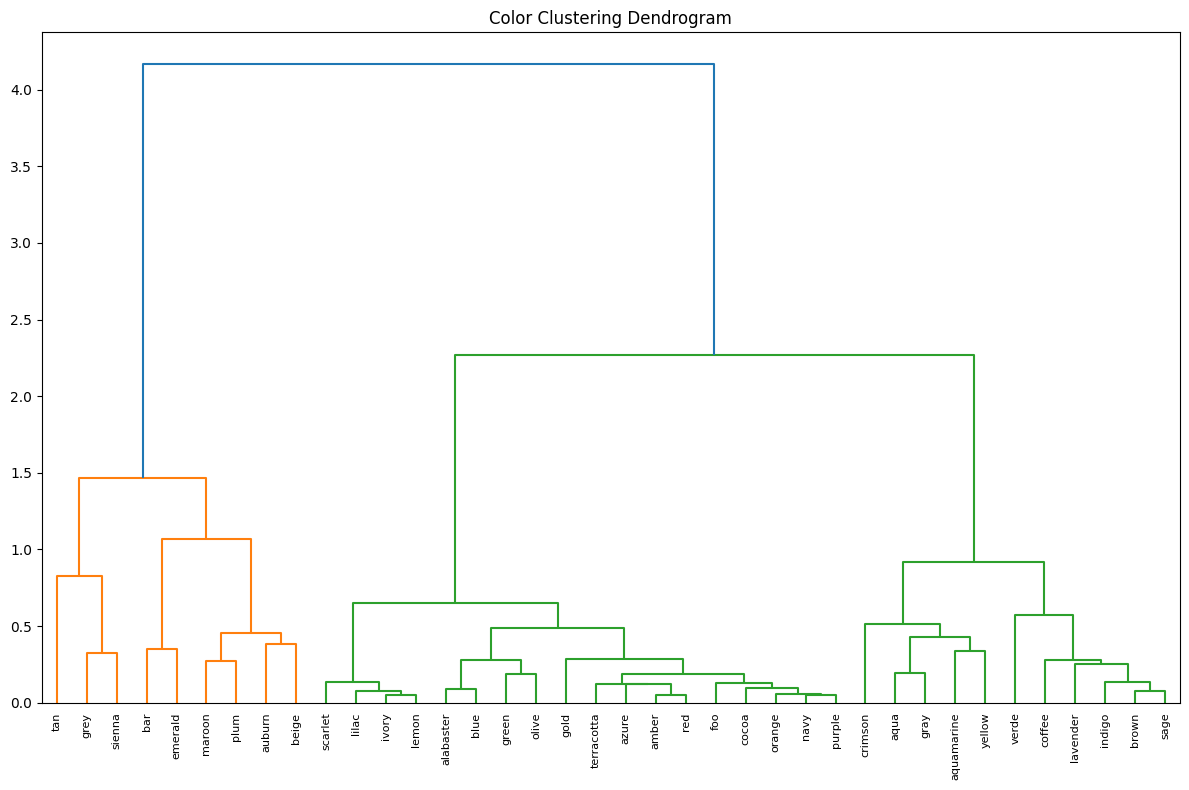

In [18]:
linkage_matrix = linkage(distributions, method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=distributions.index, leaf_rotation=90)
plt.title('Color Clustering Dendrogram')
plt.tight_layout()
plt.show()

Below is some further exploration of the findings

### Supporting inspection: color comparisons


In [19]:
similarity_df['verde']

,verde
clr,
alabaster,0.853689
amber,0.804664
aqua,0.918792
aquamarine,0.849871
auburn,0.125729
azure,0.793249
bar,0.287265
beige,0.293351
blue,0.831950


In [20]:
# how many times does each color appear + what are their categorical distributions?
print(df['clr'].value_counts()[['verde', 'coffee']])
print(distributions.loc[['verde', 'coffee']])

clr
verde     12742
coffee    40717
Name: count, dtype: int64
        bldgtype_C  bldgtype_H  bldgtype_M  bldgtype_S  bldgtype_W  \
clr                                                                  
verde     0.015988    0.122412    0.384366    0.008583    0.468651   
coffee    0.023432    0.054521    0.412229    0.015991    0.493826   

        damcat_COM  damcat_IND  damcat_PUB  damcat_RES  lc_barren  ...  \
clr                                                                ...   
verde     0.029176    0.002689    0.002063    0.966072   0.000000  ...   
coffee    0.047421    0.005570    0.001628    0.945380   0.000398  ...   

        lc_grass  lc_other  lc_shrub  lc_urban  lc_urban+barren  \
clr                                                               
verde   0.001216       0.0  0.023208  0.000000         0.000000   
coffee  0.001338       0.0  0.022067  0.287143         0.001637   

        lc_urban+crop  lc_urban+forest  lc_urban+grass  lc_urban+other  \
clr              

In [21]:
# how many times does each color appear + what are their categorical distributions?
print(df['clr'].value_counts()[['grey', 'gray']])
print(distributions.loc[['grey', 'gray']])

clr
grey    32094
gray    13665
Name: count, dtype: int64
      bldgtype_C  bldgtype_H  bldgtype_M  bldgtype_S  bldgtype_W  damcat_COM  \
clr                                                                            
grey    0.169184    0.025889    0.348652    0.052536    0.403738    0.326053   
gray    0.023507    0.037939    0.439590    0.008717    0.490247    0.040762   

      damcat_IND  damcat_PUB  damcat_RES  lc_barren  ...  lc_grass  lc_other  \
clr                                                  ...                       
grey    0.047903    0.019171    0.606873   0.001619  ...  0.005271       0.0   
gray    0.008360    0.002751    0.948128   0.007609  ...  0.007145       0.0   

      lc_shrub  lc_urban  lc_urban+barren  lc_urban+crop  lc_urban+forest  \
clr                                                                         
grey  0.013883  0.600878         0.013487       0.097907         0.083421   
gray  0.035510  0.040797         0.008288       0.329558         0.15

In [22]:
# how many times does each color appear + what are their categorical distributions?
print(df['clr'].value_counts()[['verde', 'green']])
print(distributions.loc[['verde', 'green']])

clr
verde     12742
green    119011
Name: count, dtype: int64
       bldgtype_C  bldgtype_H  bldgtype_M  bldgtype_S  bldgtype_W  damcat_COM  \
clr                                                                             
verde    0.015988    0.122412    0.384366    0.008583    0.468651    0.029176   
green    0.008503    0.029211    0.440737    0.004150    0.517400    0.014698   

       damcat_IND  damcat_PUB  damcat_RES  lc_barren  ...  lc_grass  lc_other  \
clr                                                   ...                       
verde    0.002689    0.002063    0.966072   0.000000  ...  0.001216       0.0   
green    0.001640    0.000771    0.982891   0.003212  ...  0.001181       0.0   

       lc_shrub  lc_urban  lc_urban+barren  lc_urban+crop  lc_urban+forest  \
clr                                                                          
verde  0.023208  0.000000         0.000000       0.068482         0.451448   
green  0.013188  0.413197         0.029676       0.039

## Conditional Distributions & Interaction Structure

In [23]:
# color distribution conditioned on landcover -- for each lc, what is the color distribution?

color_by_lc = df.groupby(['lc_type', 'clr'])['clr_cc'].sum().unstack(fill_value=0)
color_by_lc = color_by_lc.div(color_by_lc.sum(axis=1), axis=0)
color_by_lc

clr,alabaster,amber,aqua,aquamarine,auburn,azure,bar,beige,blue,brown,...,plum,purple,red,sage,scarlet,sienna,tan,terracotta,verde,yellow
lc_type,,,,,,,,,,,,,,,,,,,,,
barren,0.102273,0.041921,0.001982,0.008519,0.000084,0.001898,0.000084,0.009911,0.000801,0.006495,...,0.000253,0.017292,0.069293,0.002488,0.000000,0.001307,0.000000,0.004007,0.000000,0.000337
crop,0.226058,0.007698,0.002706,0.011456,0.000120,0.020086,0.014734,0.007848,0.007066,0.146165,...,0.000361,0.014884,0.015726,0.034519,0.000150,0.003608,0.001082,0.018643,0.001323,0.000000
forest,0.078258,0.010738,0.003359,0.002538,0.000002,0.006177,0.000550,0.007171,0.008072,0.202637,...,0.000051,0.005919,0.009758,0.062577,0.000004,0.000778,0.004199,0.032895,0.022647,0.000000
grass,0.240379,0.026827,0.002068,0.001128,0.000000,0.019932,0.003573,0.009151,0.002068,0.060925,...,0.000501,0.011345,0.027391,0.018052,0.000000,0.000752,0.001567,0.028018,0.002068,0.000000
other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
shrub,0.100819,0.023163,0.005601,0.002252,0.000000,0.024789,0.001148,0.019942,0.013185,0.129642,...,0.000224,0.006704,0.040286,0.036445,0.000015,0.003363,0.004064,0.035431,0.004698,0.000157
urban,0.053622,0.051934,0.000103,0.000038,0.000817,0.015710,0.000225,0.009185,0.007013,0.022942,...,0.000331,0.040057,0.062294,0.008774,0.002501,0.003615,0.000000,0.077469,0.000000,0.000068
urban+barren,0.085809,0.108148,0.000912,0.000608,0.000028,0.000668,0.000007,0.005137,0.001456,0.003187,...,0.000163,0.061133,0.142423,0.001180,0.000049,0.000922,0.000000,0.009698,0.000000,0.000226
urban+crop,0.081917,0.045936,0.004422,0.009249,0.000309,0.028559,0.001191,0.005290,0.007566,0.145122,...,0.000926,0.037373,0.055620,0.038822,0.002050,0.016561,0.000203,0.067317,0.003305,0.006531


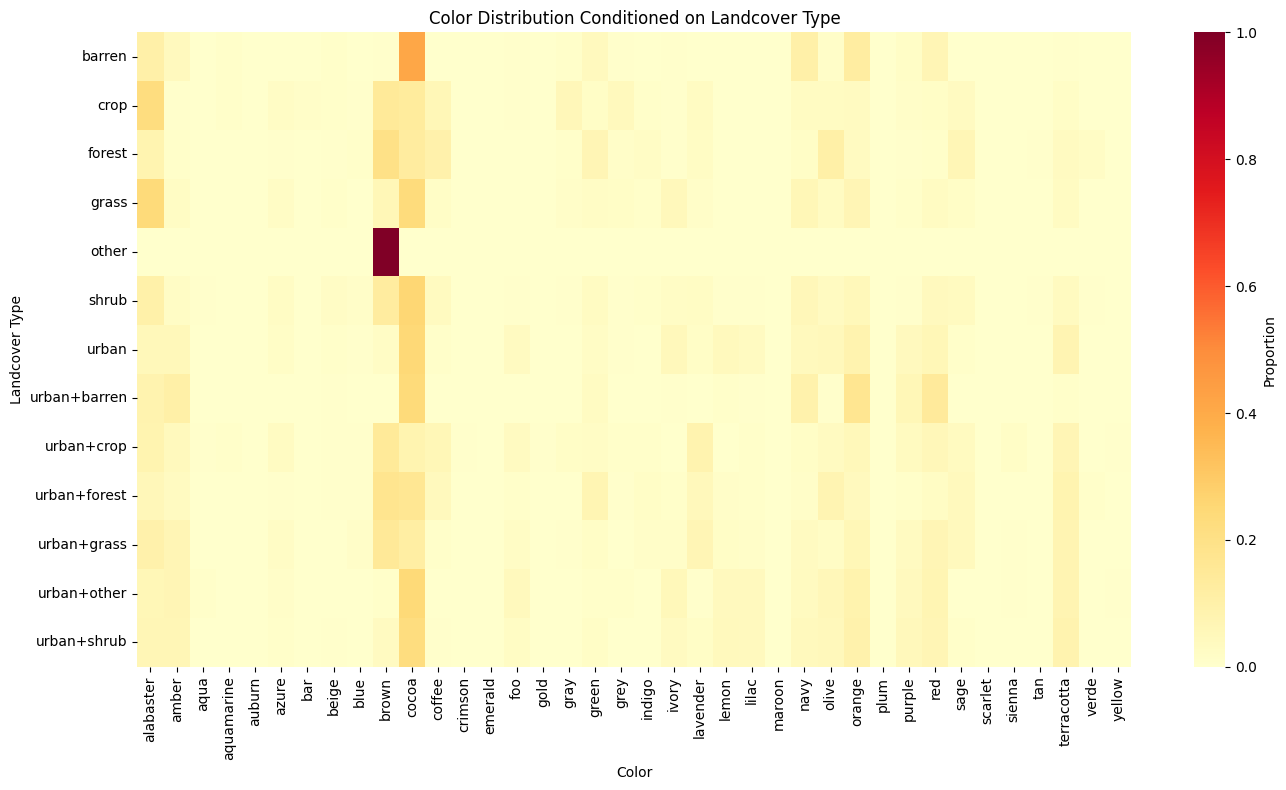

In [24]:
# heatmap of color distribution by landcover
plt.figure(figsize=(14, 8))
sns.heatmap(color_by_lc, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Proportion'})
plt.title('Color Distribution Conditioned on Landcover Type')
plt.xlabel('Color')
plt.ylabel('Landcover Type')
plt.tight_layout()
plt.show()

The heatmap shows that color distributions vary by landcover. Some colors like alabaster, amber, brown, and cocoa are generally popular, there are clear landcover-specific patterns:
- "other" landcover is almost entirely brown (100% spike)
- barren has higher proportions for cocoa, navy, and orange
- some colors (e.g. navy and orange) show identical patterns across landcover types -- this is correlated this the previous findings of "similar" colors

Conclusion: landcover affects color variability

In [25]:
# does conditioning reduce or reveal variability? (do colors vary more overall or within landcovers?)

# how much do color proportions vary across all data?
overall_clr_props = df.groupby('clr')['clr_cc'].sum()
overall_clr_props = overall_clr_props / overall_clr_props.sum()
overall_var = overall_clr_props.var()

# for each landcover, calculate color variance and then average
within_lc_vars = color_by_lc.var(axis=1)  # variance across colors for each landcover
avg_within_lc_var = within_lc_vars.mean()

print(f"overall variance: {overall_var}")
print(f"variance by landcover: {avg_within_lc_var}")

overall variance: 0.0014801425648715266
variance by landcover: 0.004131754404609256


Variance Analysis:
- Overall color variance: 0.0015
- Average within-landcover variance: 0.0041


Conditioning on landcover "reveals" variability. When we mix all landcovers together, color distribution appears somewhat even, but when we look at each landcover separately, we see that each has strong preferences for specific color/colors.

## What color-landcover combos are "stable" (common) and what combos are rare?

In [26]:
lc_clr_cnts = df.groupby(['lc_type', 'clr'])['clr_cc'].sum().reset_index(name='count')
lc_clr_cnts.head()

,lc_type,clr,count
0,barren,alabaster,2425
1,barren,amber,994
2,barren,aqua,47
3,barren,aquamarine,202
4,barren,auburn,2


In [27]:
# get proportions (color distributions within landcovers)
lc_totals = df.groupby('lc_type')['clr_cc'].sum().reset_index(name='total')
lc_clr_cnts = lc_clr_cnts.merge(lc_totals, on='lc_type')
lc_clr_cnts['proportion'] = lc_clr_cnts['count'] / lc_clr_cnts['total']
lc_clr_cnts.head(10)

,lc_type,clr,count,total,proportion
0,barren,alabaster,2425,23711,0.102273
1,barren,amber,994,23711,0.041921
2,barren,aqua,47,23711,0.001982
3,barren,aquamarine,202,23711,0.008519
4,barren,auburn,2,23711,0.000084
5,barren,azure,45,23711,0.001898
6,barren,bar,2,23711,0.000084
7,barren,beige,235,23711,0.009911
8,barren,blue,19,23711,0.000801
9,barren,brown,154,23711,0.006495


In [28]:
# flag stable vs variable combinations (taking 1000 as the threshold)
lc_clr_cnts['stable'] = lc_clr_cnts['count'] >= 1000

print(f"tolal landcover-color combos: {len(lc_clr_cnts)}")
print(f"stable combos (n >= 1000): {lc_clr_cnts['stable'].sum()}")
print(f"variable combos (n < 1000): {(~lc_clr_cnts['stable']).sum()}")

tolal landcover-color combos: 419
stable combos (n >= 1000): 215
variable combos (n < 1000): 204


In [29]:
# top stable combinations
lc_clr_cnts[lc_clr_cnts['stable']].nlargest(10, 'count')

,lc_type,clr,count,total,proportion,stable
182,urban,cocoa,1412584,5671471,0.249068,True
199,urban,orange,476889,5671471,0.084086,True
206,urban,terracotta,439366,5671471,0.077469,True
202,urban,red,353299,5671471,0.062294,True
172,urban,alabaster,304113,5671471,0.053622,True
173,urban,amber,294544,5671471,0.051934,True
192,urban,ivory,283141,5671471,0.049924,True
198,urban,olive,266701,5671471,0.047025,True
194,urban,lemon,264955,5671471,0.046717,True
197,urban,navy,245540,5671471,0.043294,True


In [30]:
# top rarest combinations
lc_clr_cnts[~lc_clr_cnts['stable']].nsmallest(10, 'count')

,lc_type,clr,count,total,proportion,stable
23,barren,maroon,1,23711,0.000042,False
71,forest,auburn,1,485853,0.000002,False
113,grass,crimson,1,15954,0.000063,False
371,urban+other,maroon,1,449,0.002227,False
377,urban+other,sage,1,449,0.002227,False
4,barren,auburn,2,23711,0.000084,False
6,barren,bar,2,23711,0.000084,False
97,forest,scarlet,2,485853,0.000004,False
166,shrub,scarlet,2,134092,0.000015,False
214,urban+barren,bar,2,283037,0.000007,False


Stable vs variable landcover-color combinations:
- stable: 215  
- variable: 204

Most stable: All top 10 are urban (urban+cocoa has ~5.6M structures). Urban dominates most likely because it contains the most structures.

Rarest: Many combinations have fewer structures.

## Conclusions

Why landcover should be accounted for in any method:
- Landcover strongly structures color distributions. Conditioning on landcover reveals that each landcover type has distinct color "preferences". Ignoring landcover would mask these patterns.

Which strata are appropriate for pooling:
- Colors: "similar" colors (navy/orange, verde/coffee) can be pooled based on their high similarity scores and nearly identical distributions
- Landcover-color combinations: 49% of combinations are rare and can be unreliable for modeling. Stable combinations are concentrated in urban landcovers.

In [31]:
lc_clr_cnts.to_csv('landcover_color_combinations.csv', index=False)

---

### Supporting inspection: potential heatmap refinements

Potential follow-up: exclude `other`, cap the heatmap at 0.6, and compare similar counties.


## Optional follow-up: county heatmaps


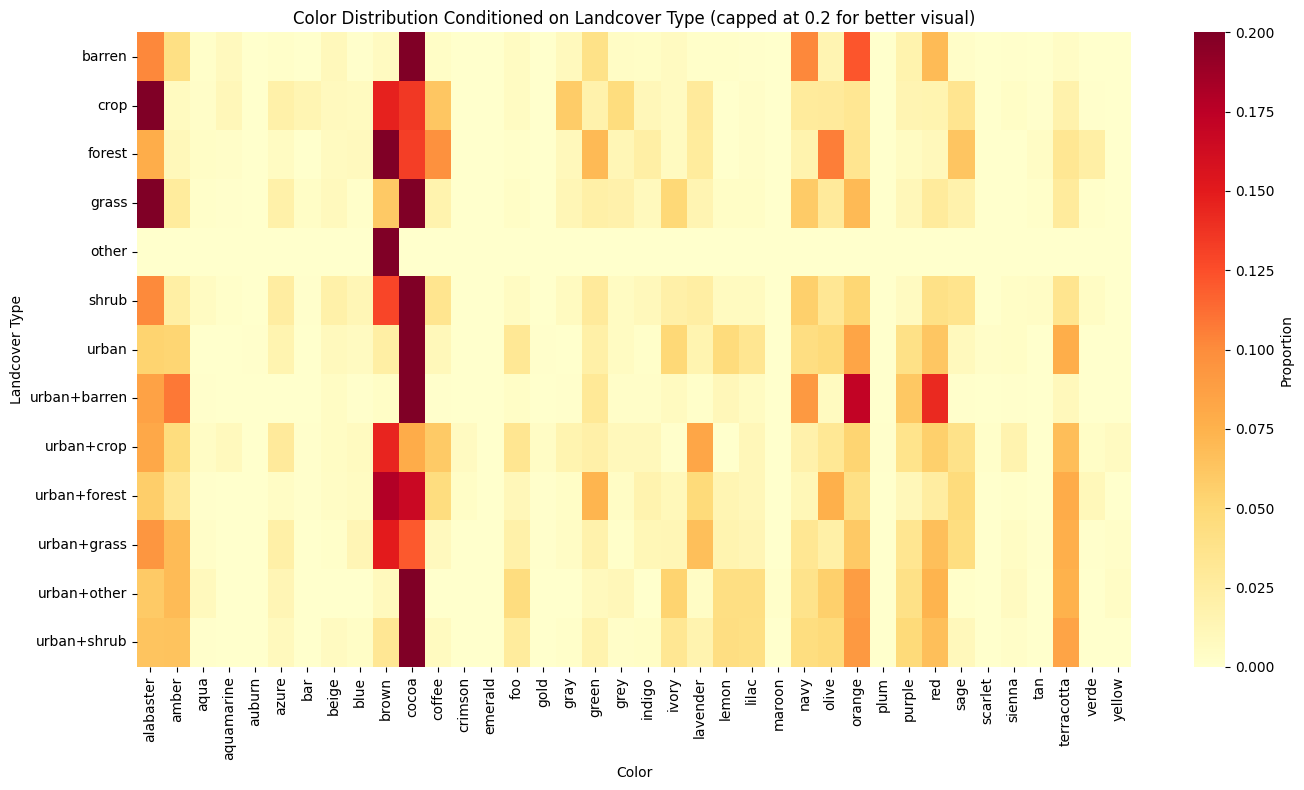

In [33]:
# Sort for consistent ordering
colors_sorted = sorted(color_by_lc.columns)
lc_types_sorted = sorted(color_by_lc.index)
color_by_lc_sorted = color_by_lc.loc[lc_types_sorted, colors_sorted]

plt.figure(figsize=(14, 8))
sns.heatmap(color_by_lc_sorted, cmap='YlOrRd', annot=False, vmax=0.2, cbar_kws={'label': 'Proportion'})
plt.title('Color Distribution Conditioned on Landcover Type (capped at 0.2 for better visual)')
plt.xlabel('Color')
plt.ylabel('Landcover Type')
plt.tight_layout()
plt.savefig('general_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

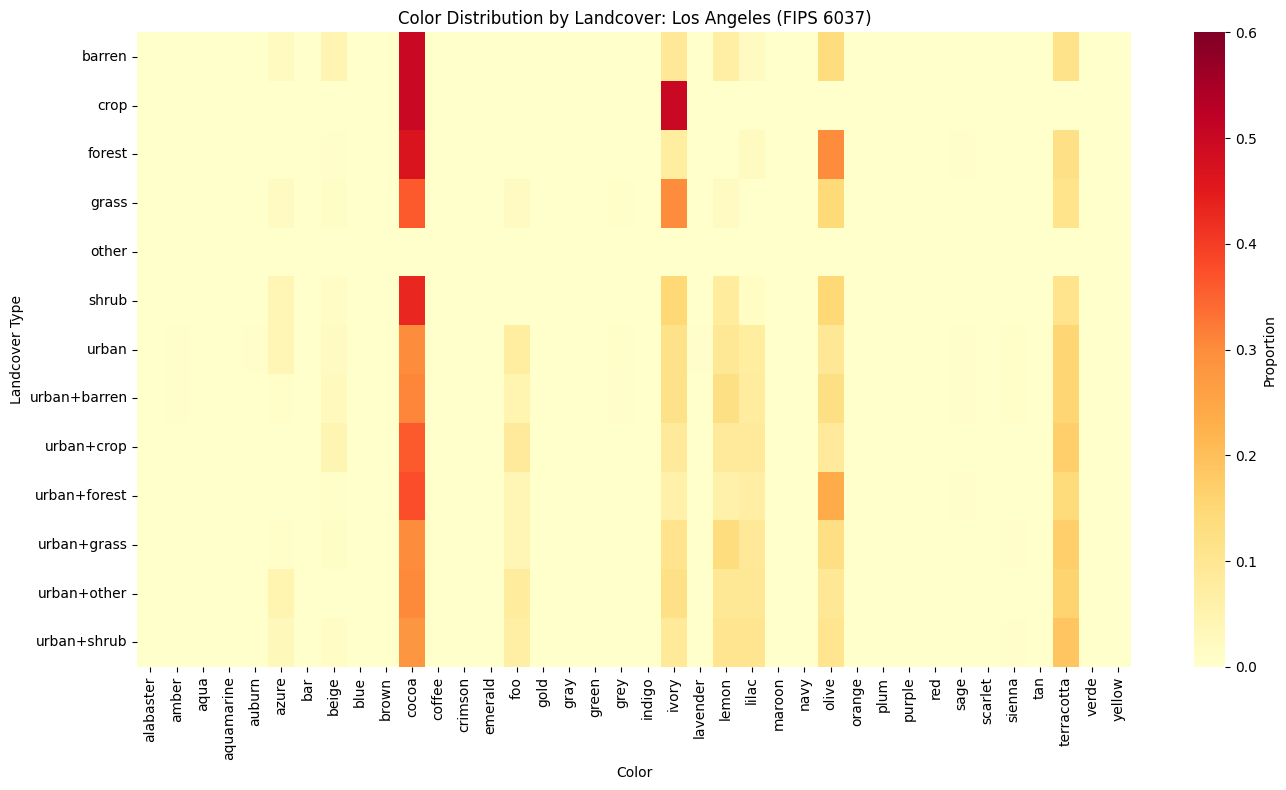

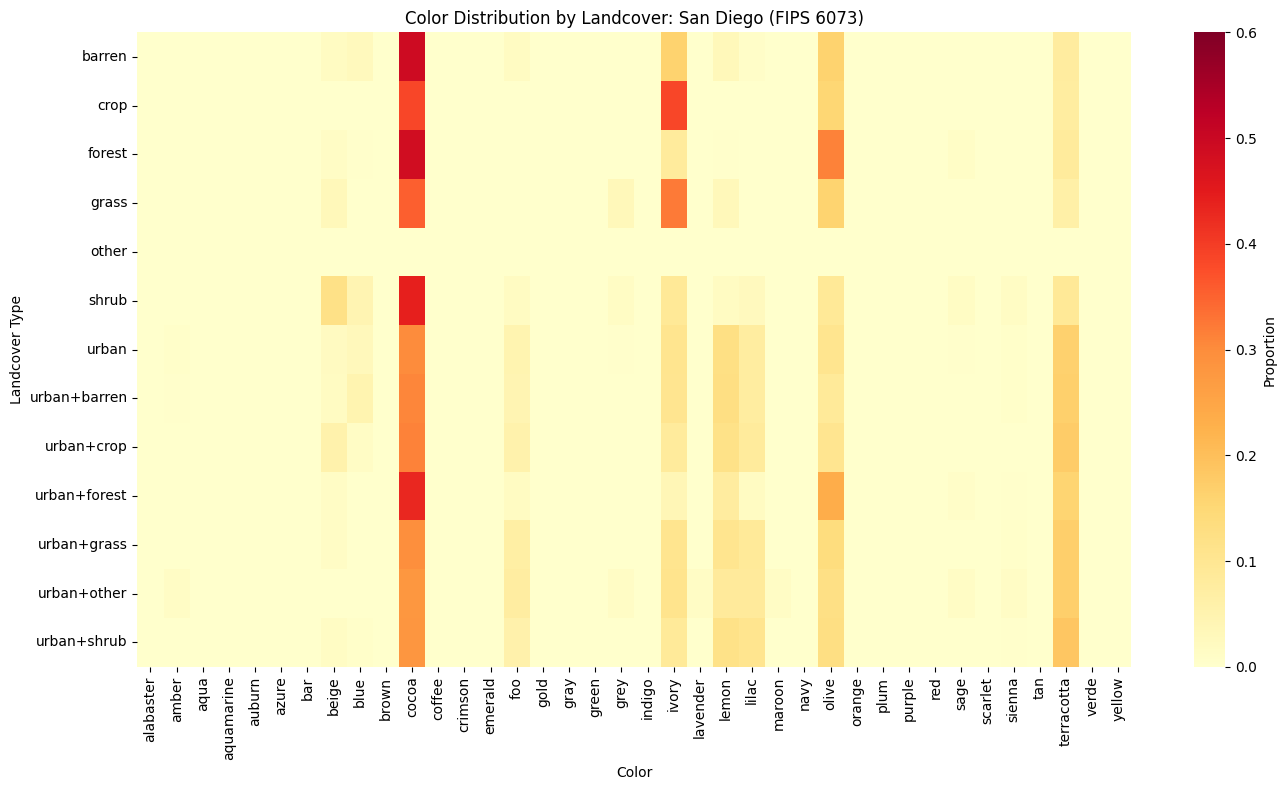

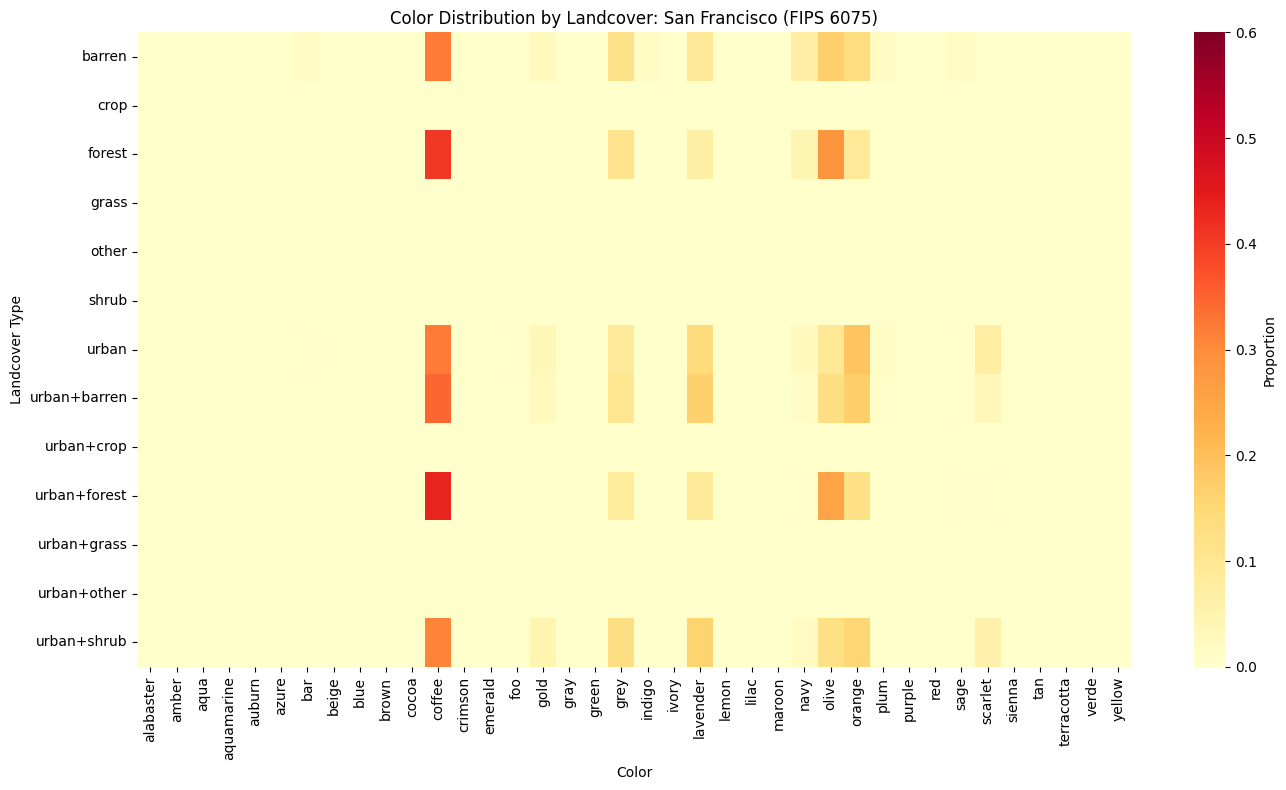

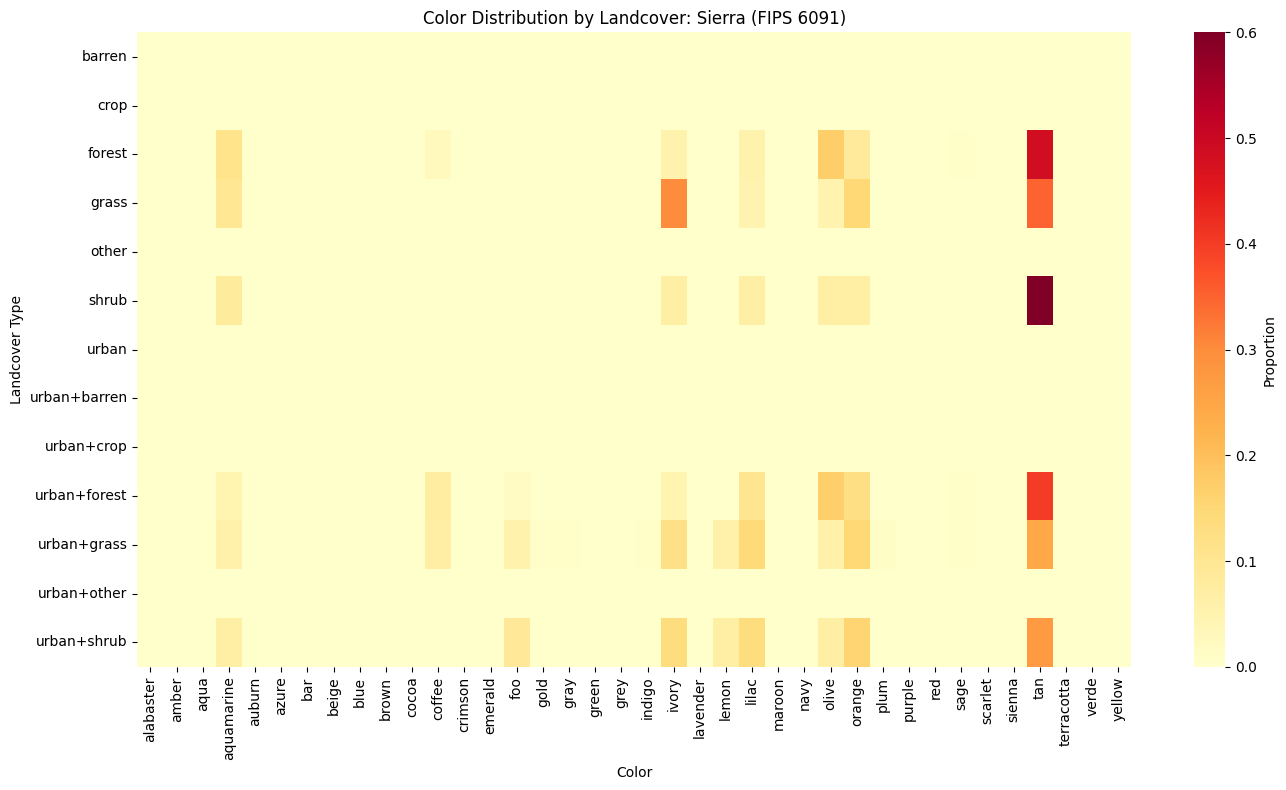

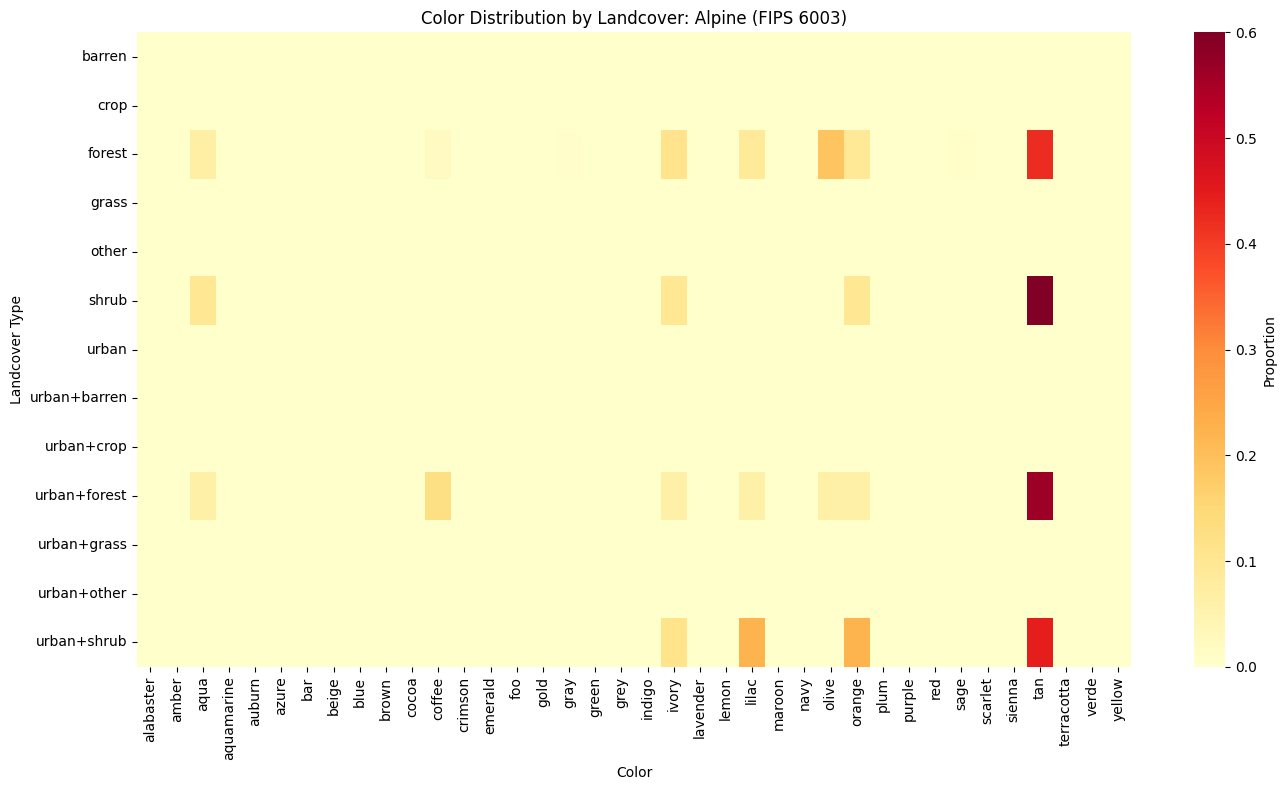

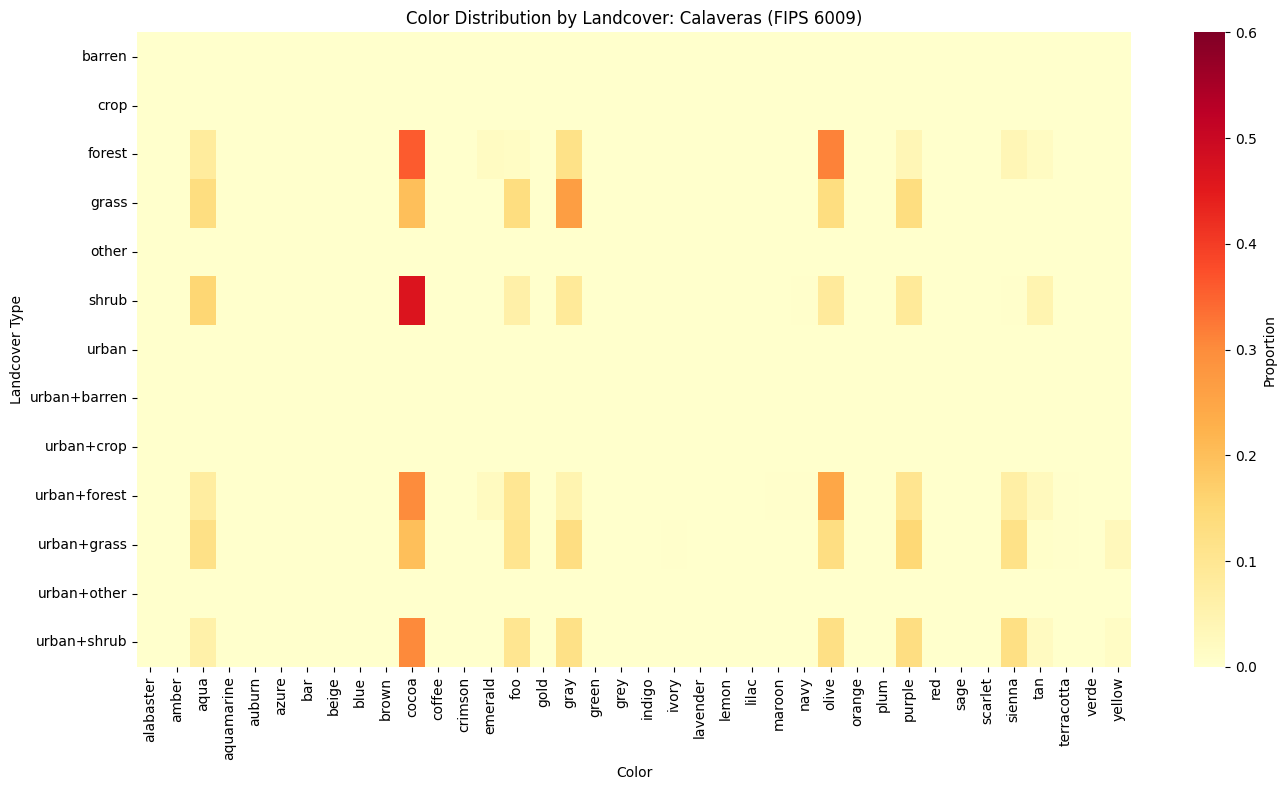

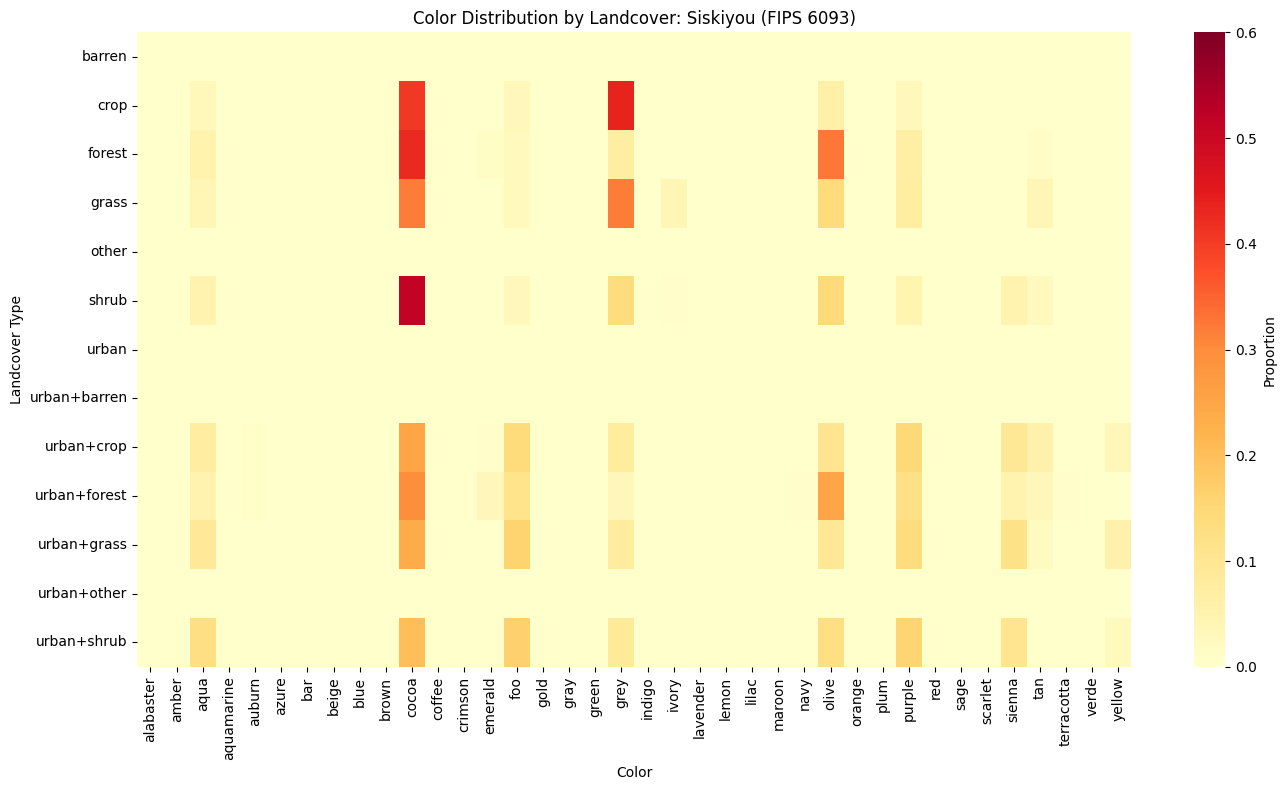

In [34]:
urban_counties = {
    6037: 'Los Angeles',
    6073: 'San Diego',
    6075: 'San Francisco'
}

rural_counties = {
    6091: 'Sierra', # very small mountain county
    6003: 'Alpine', # smallest CA county by population
    6009: 'Calaveras', # gold rush country, rural
    6093: 'Siskiyou' # northern rural/forest county
}

# func to plot county heatmap
def plot_county_heatmap(fips_code, county_name=''):
    county_data = df[df['fips'] == fips_code]
    if len(county_data) == 0:
        print(f"No data for {county_name} (FIPS {fips_code})")
        return

    county_color_by_lc = county_data.groupby(['lc_type', 'clr'])['clr_cc'].sum().unstack(fill_value=0)
    county_color_by_lc = county_color_by_lc.div(county_color_by_lc.sum(axis=1), axis=0)

    # Get all possible colors and landcovers from the full dataset (alphabetically sorted)
    all_colors = sorted(df['clr'].unique())
    all_lc_types = sorted(df['lc_type'].unique())

    # Reindex to include all colors/landcovers, filling missing with 0
    county_color_by_lc = county_color_by_lc.reindex(index=all_lc_types, columns=all_colors, fill_value=0)

    plt.figure(figsize=(14, 8))
    sns.heatmap(county_color_by_lc, cmap='YlOrRd', annot=False, vmax=0.6, cbar_kws={'label': 'Proportion'})
    plt.title(f'Color Distribution by Landcover: {county_name} (FIPS {fips_code})')
    plt.xlabel('Color')
    plt.ylabel('Landcover Type')
    plt.tight_layout()
    plt.savefig(f'{county_name}_county_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


for fips, name in urban_counties.items():
    plot_county_heatmap(fips, name)

for fips, name in rural_counties.items():
    plot_county_heatmap(fips, name)

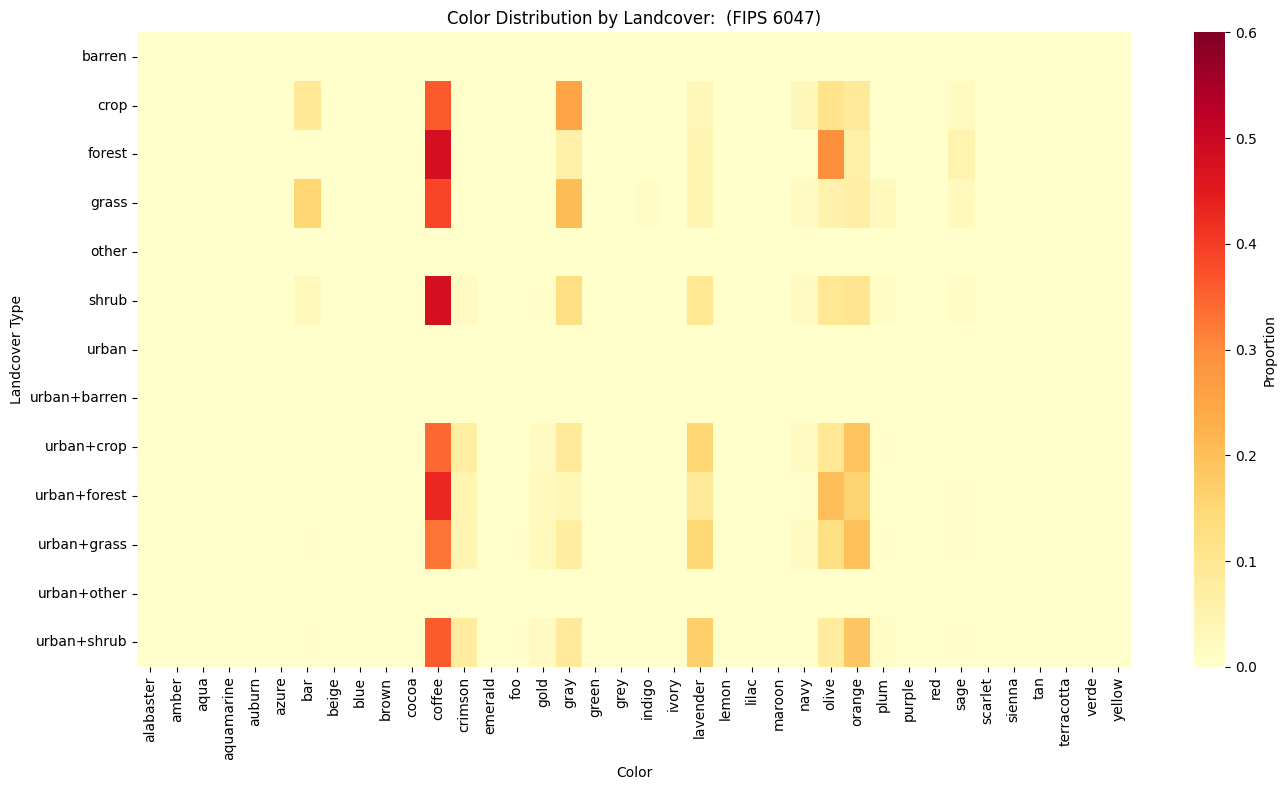

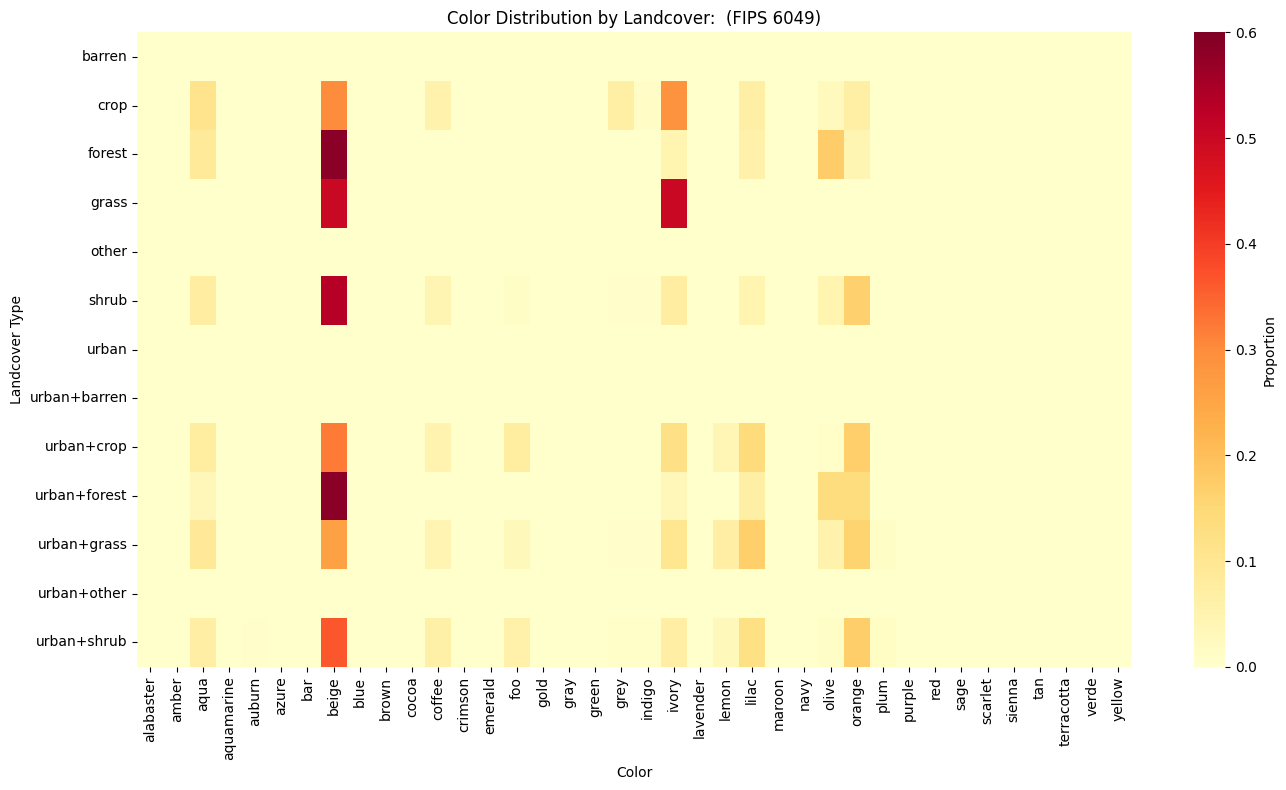

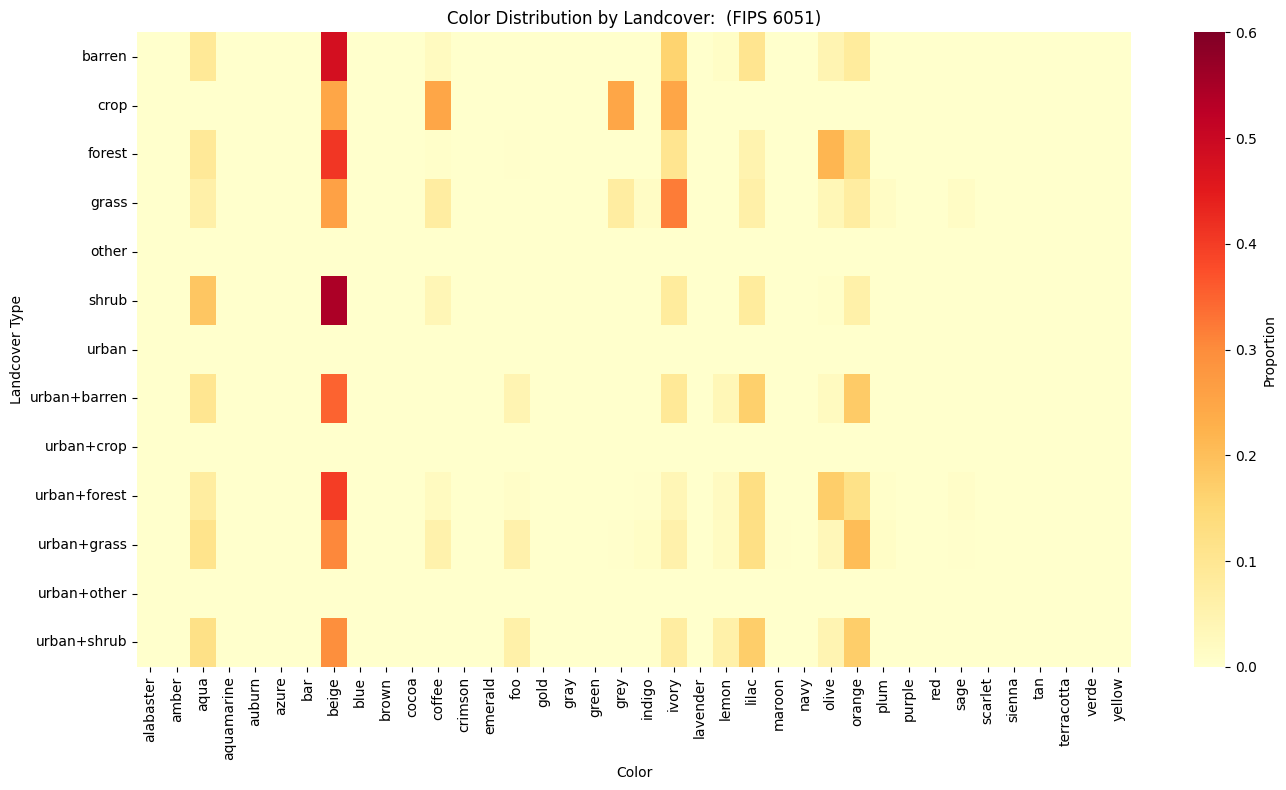

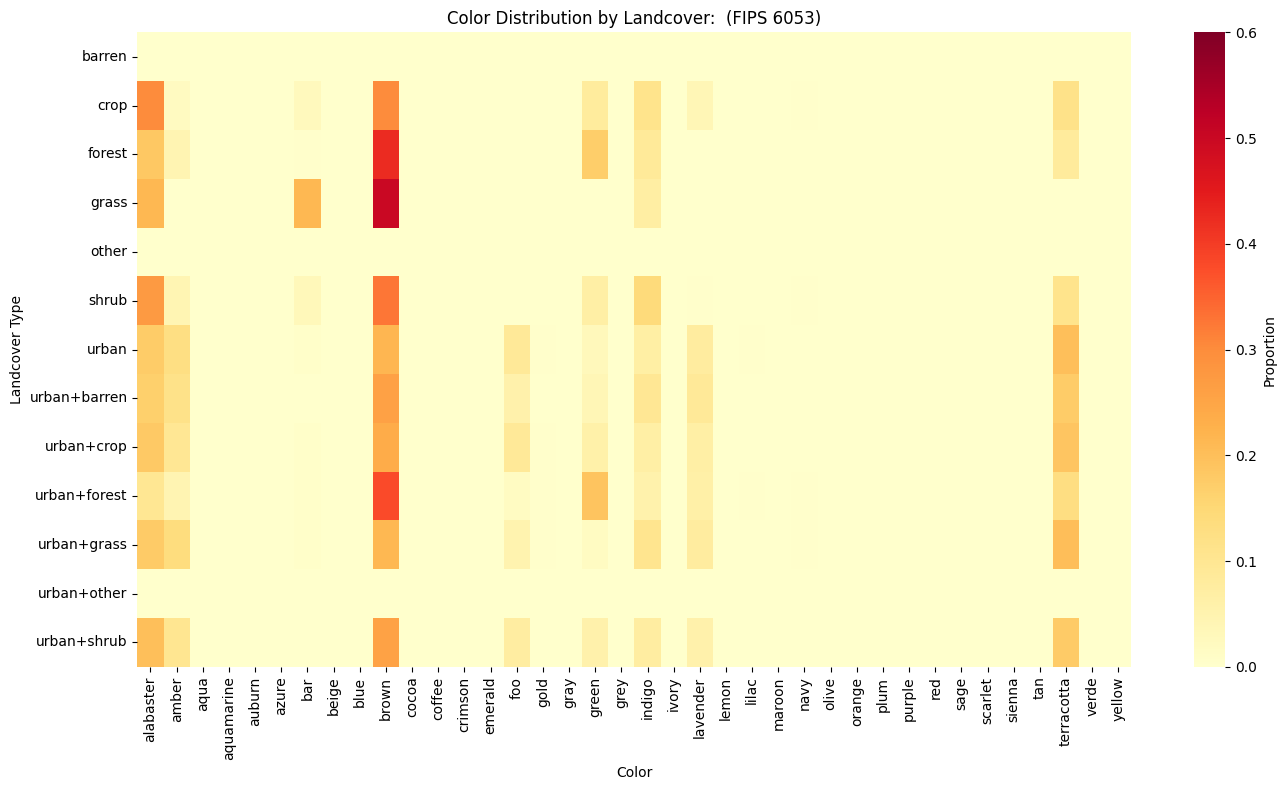

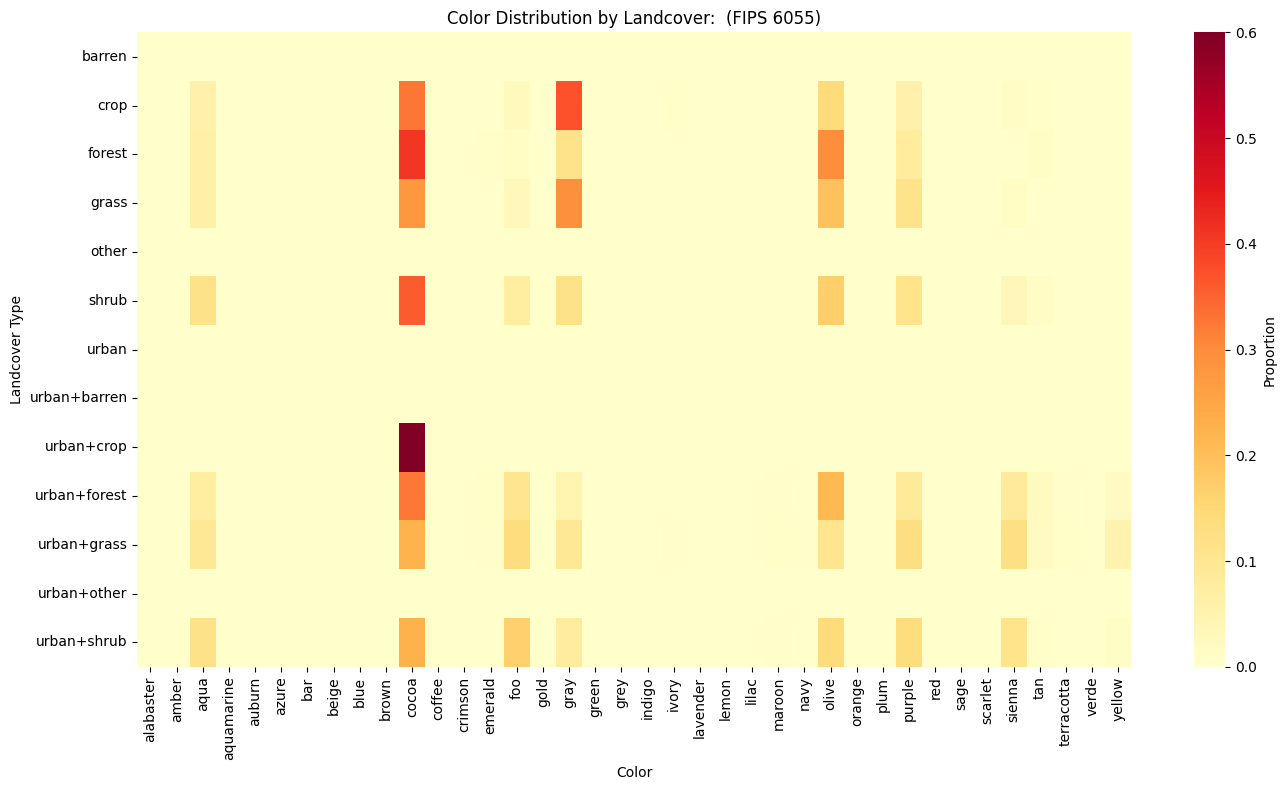

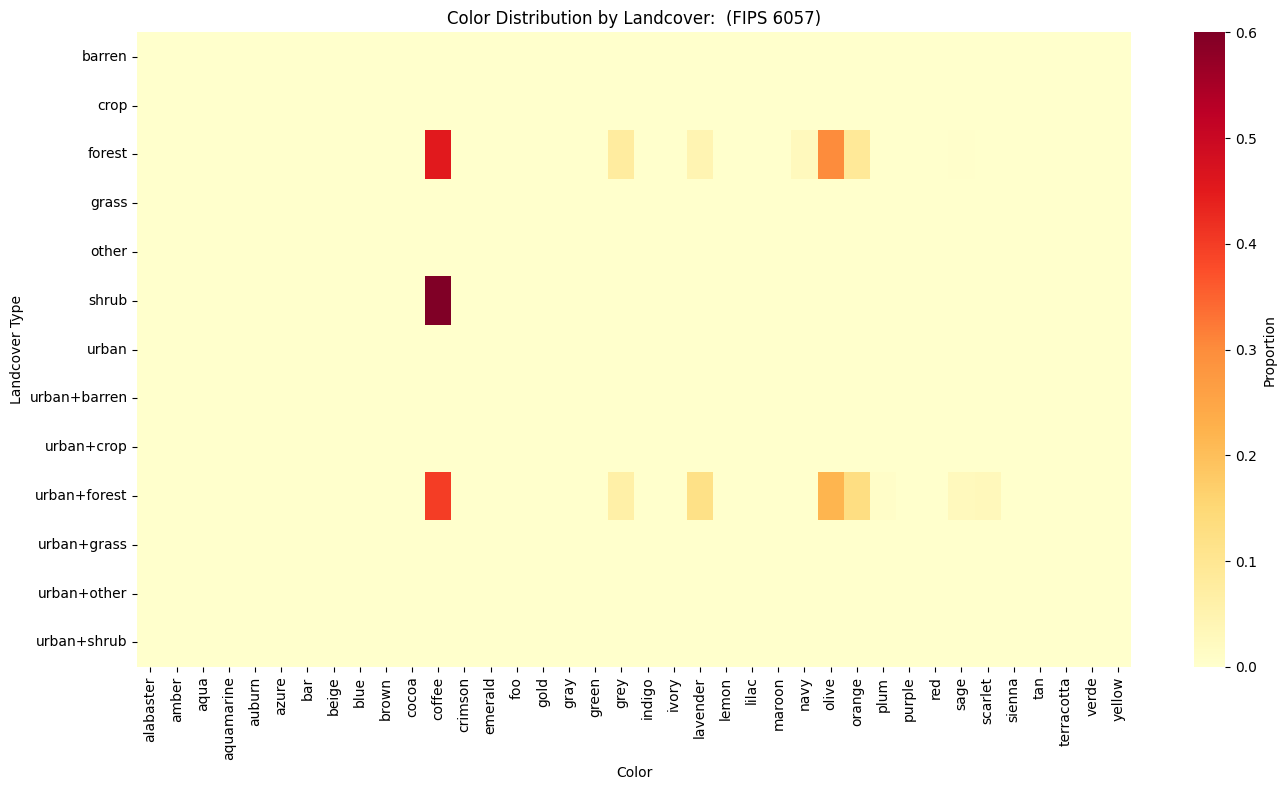

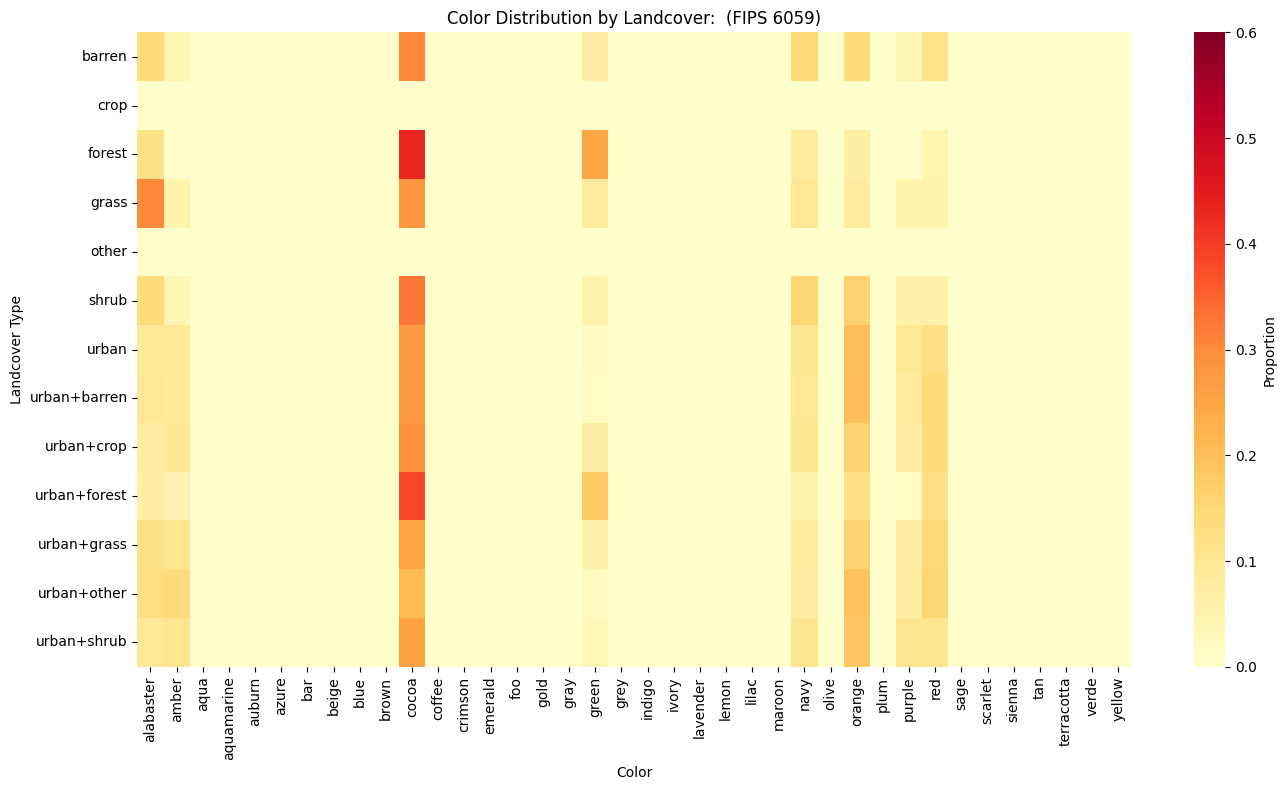

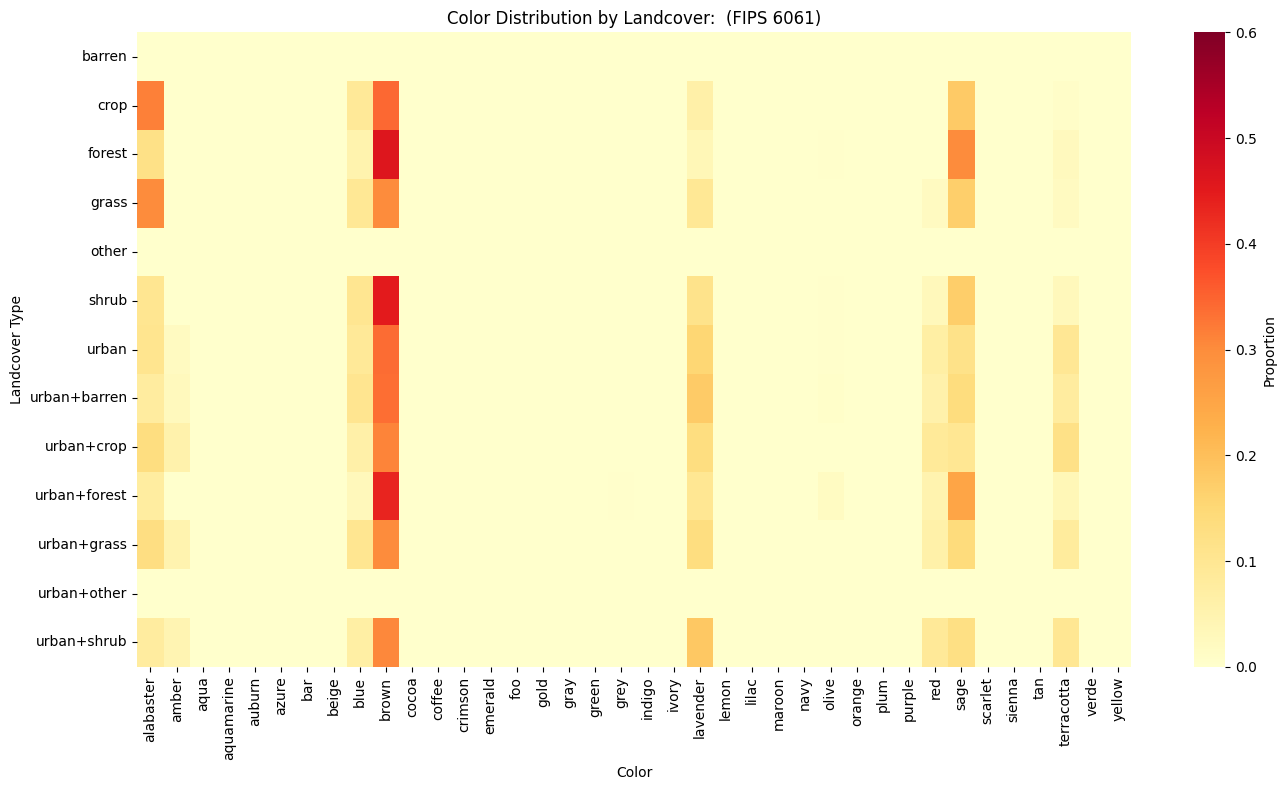

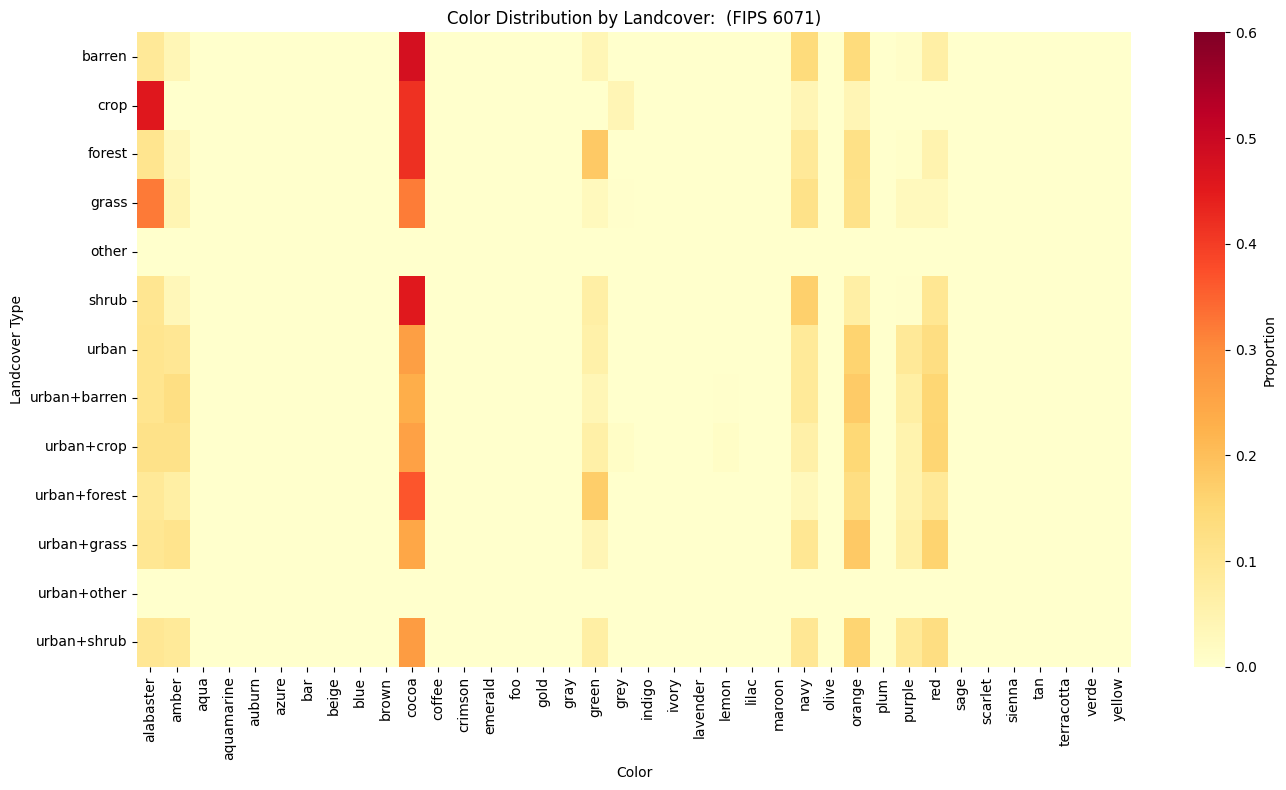

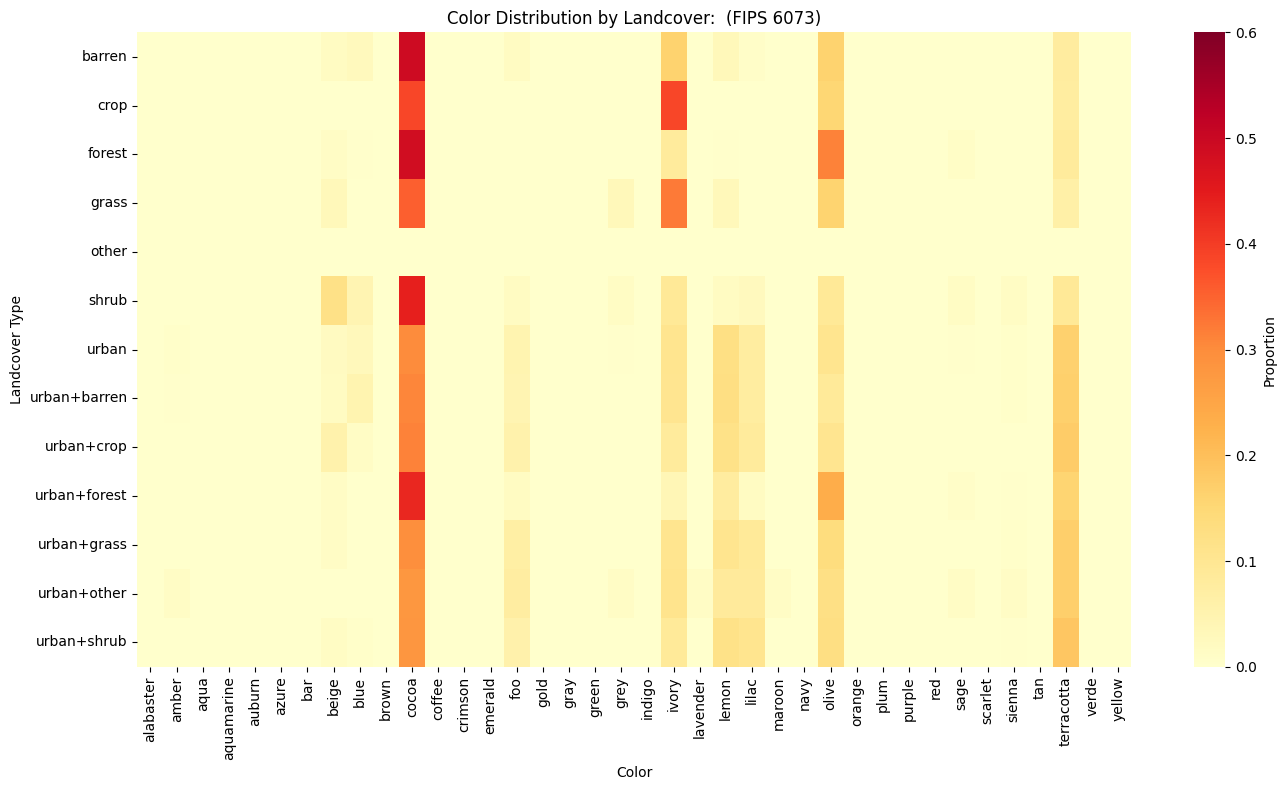

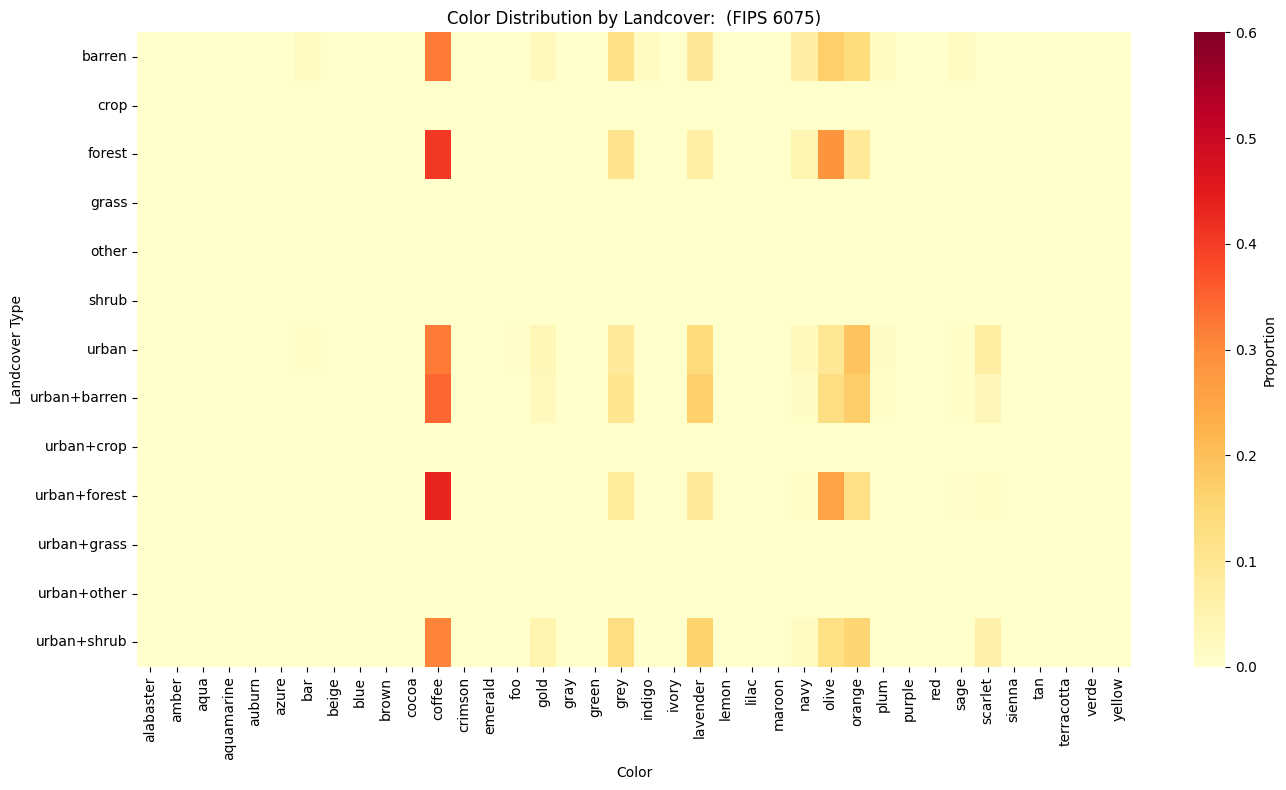

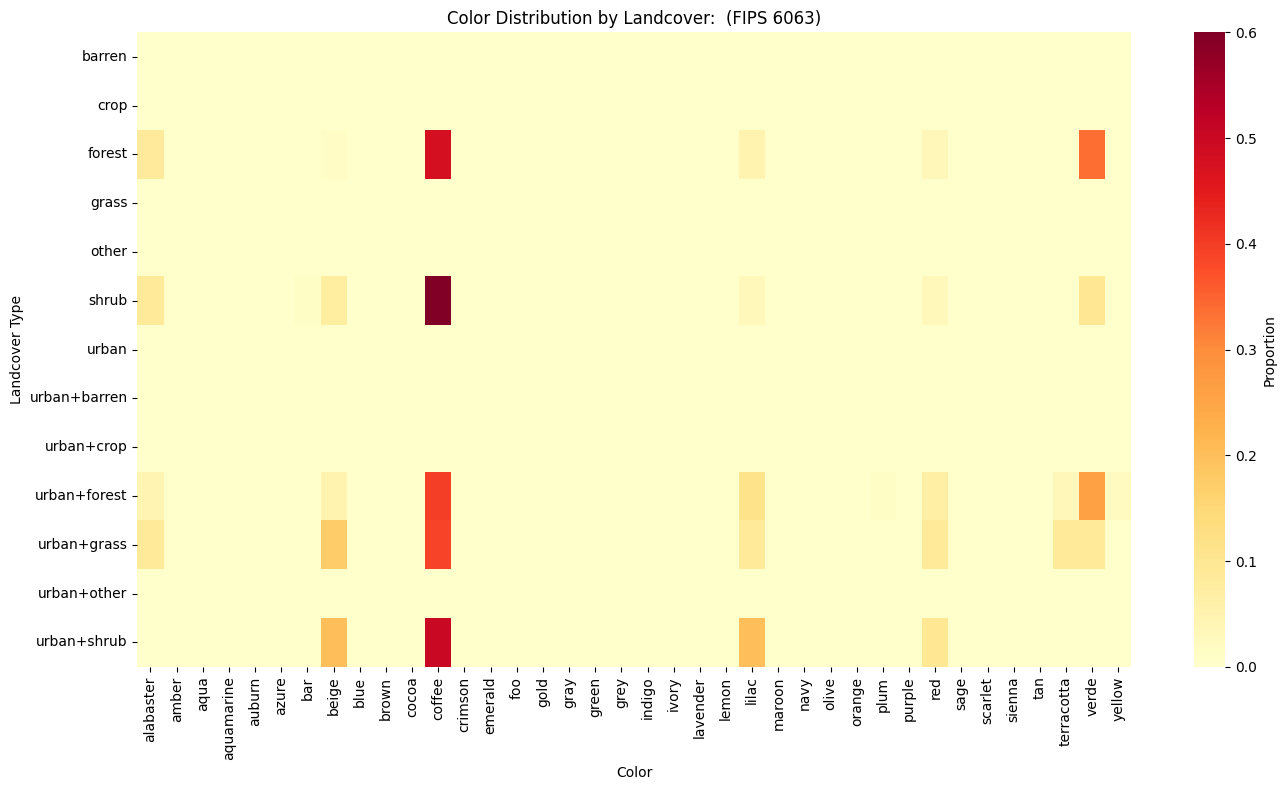

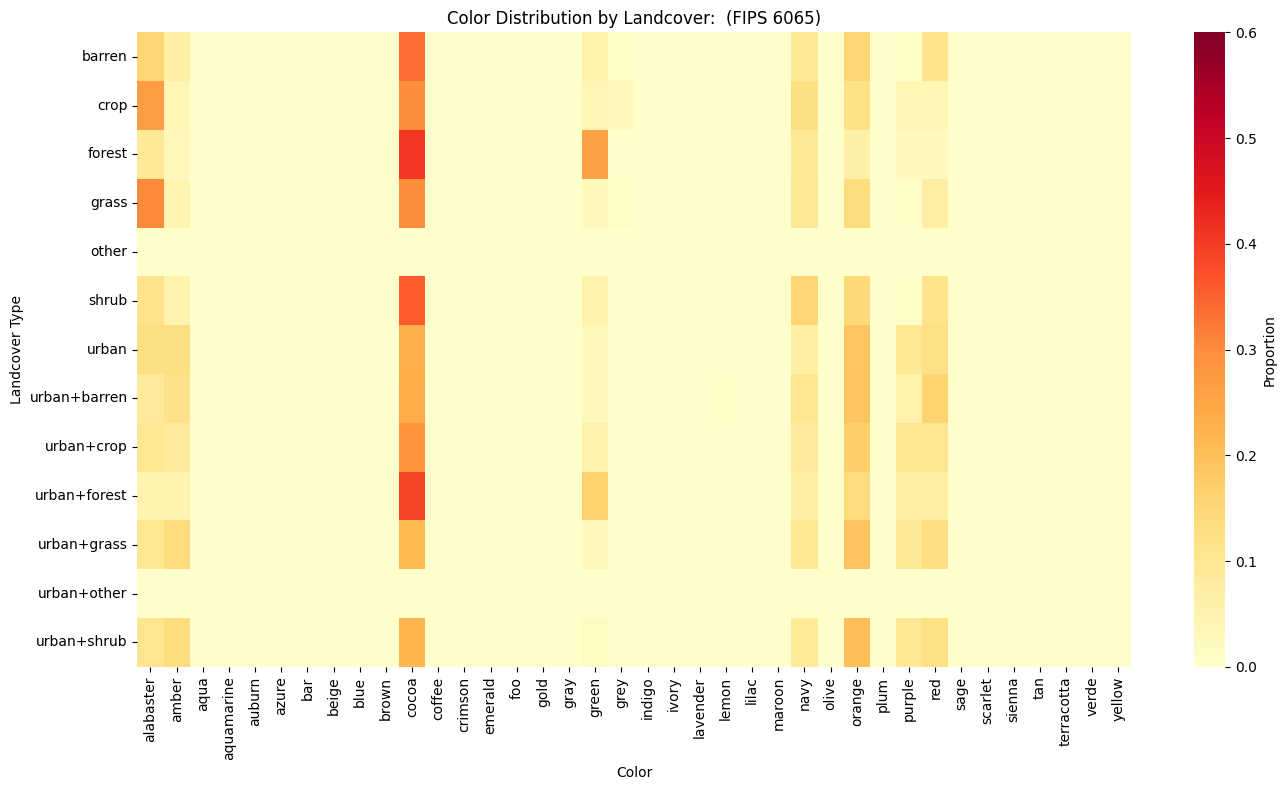

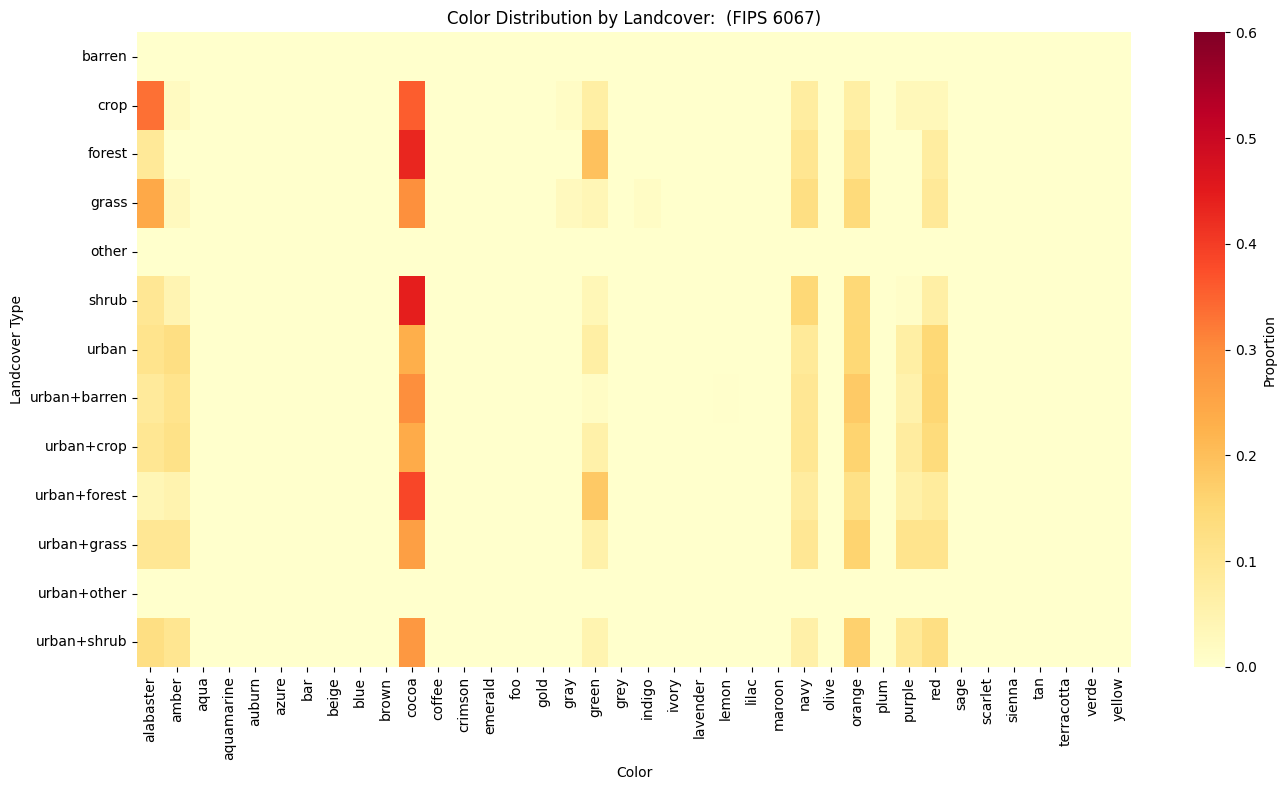

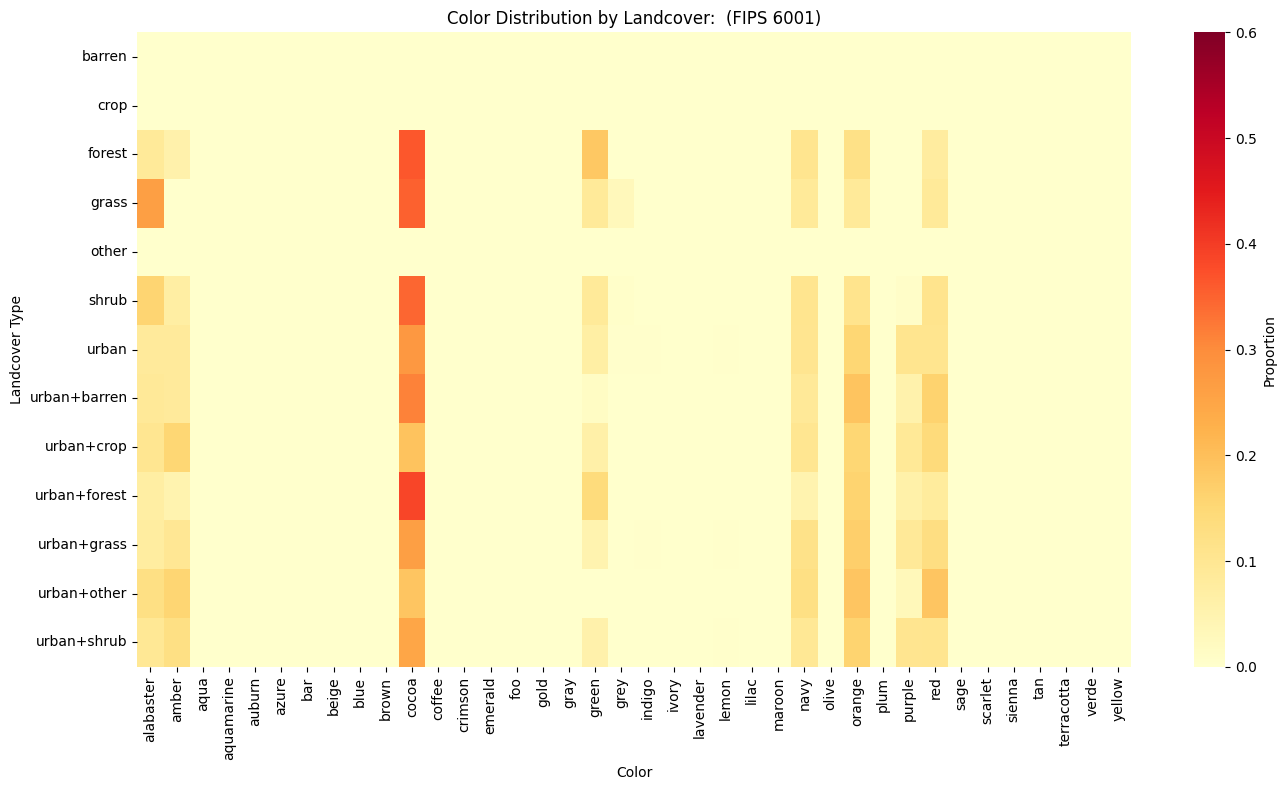

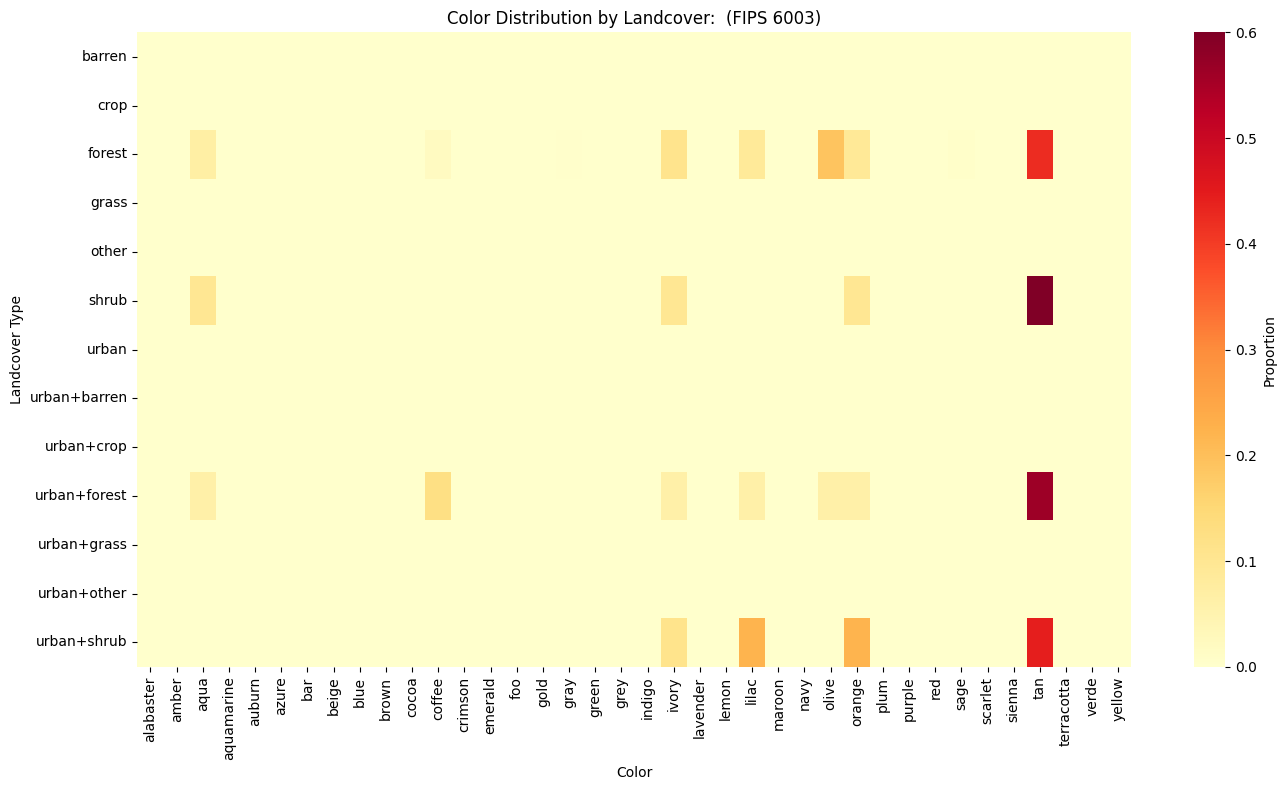

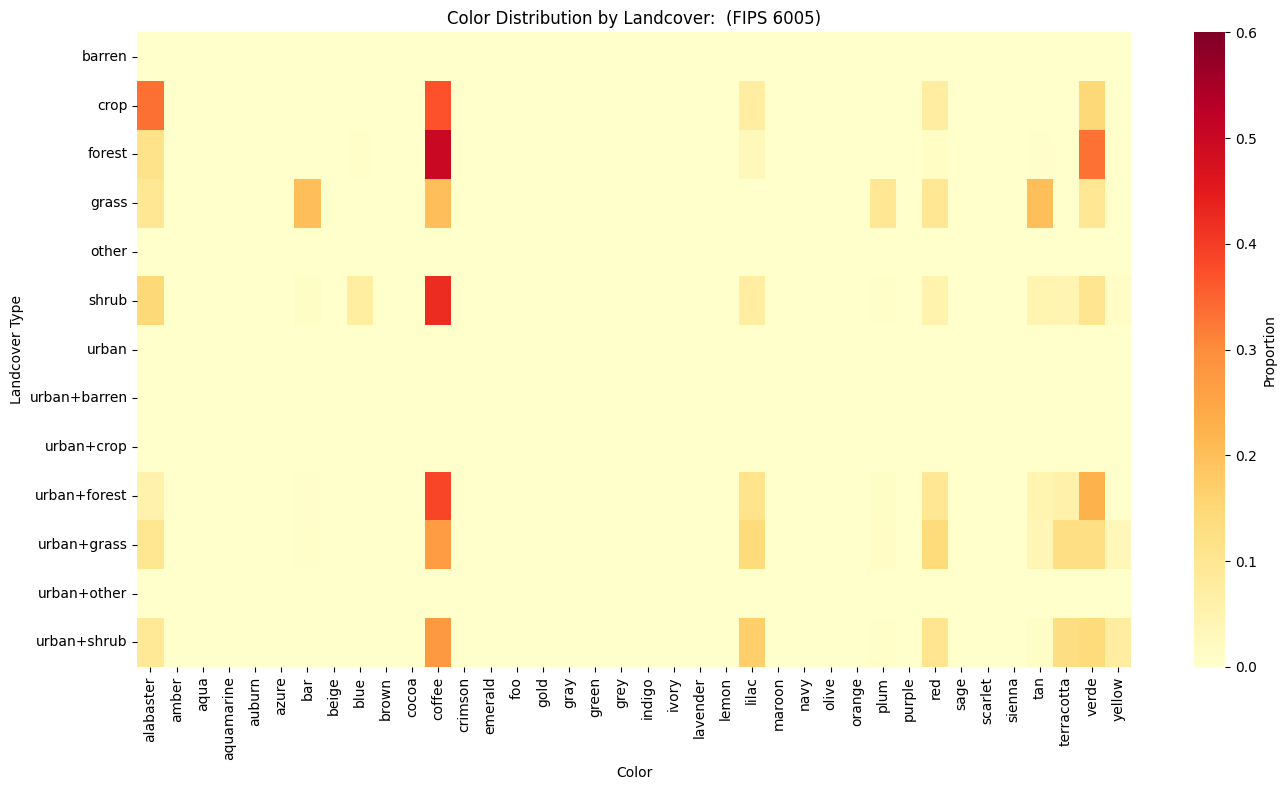

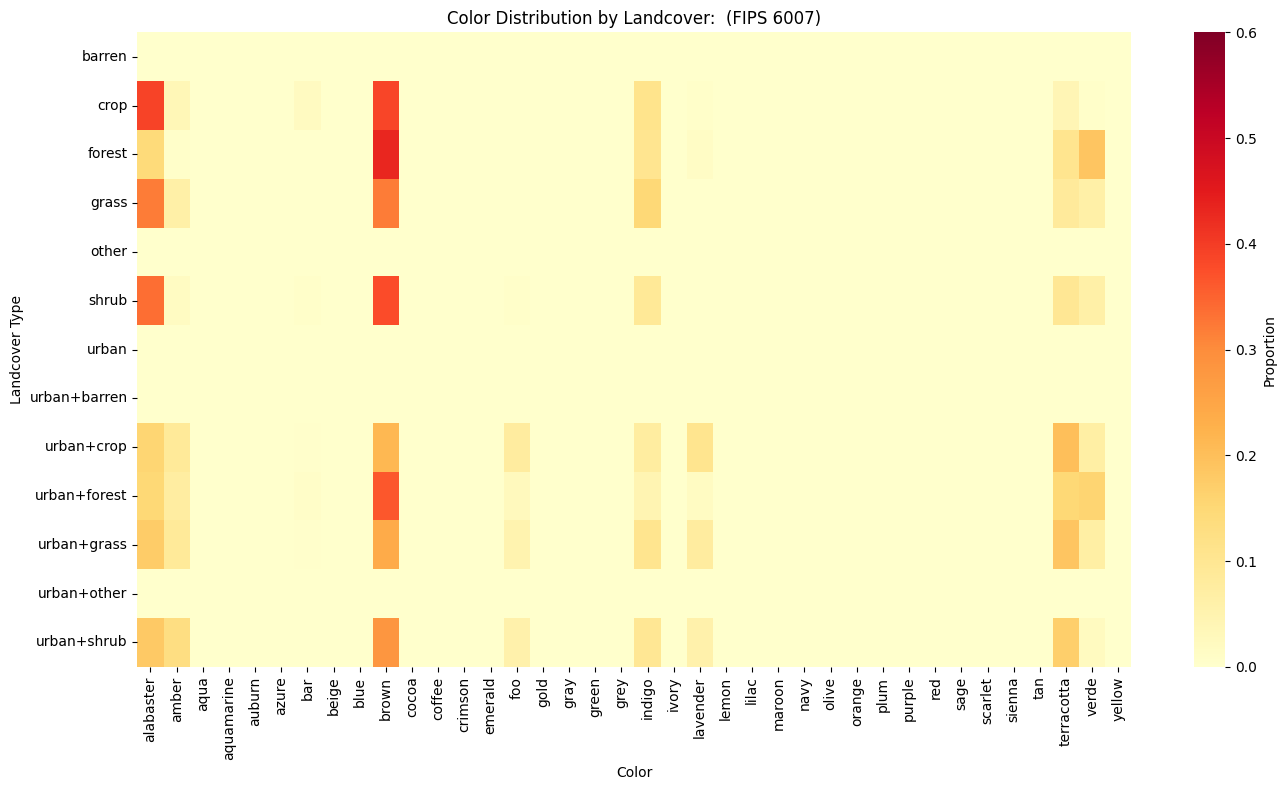

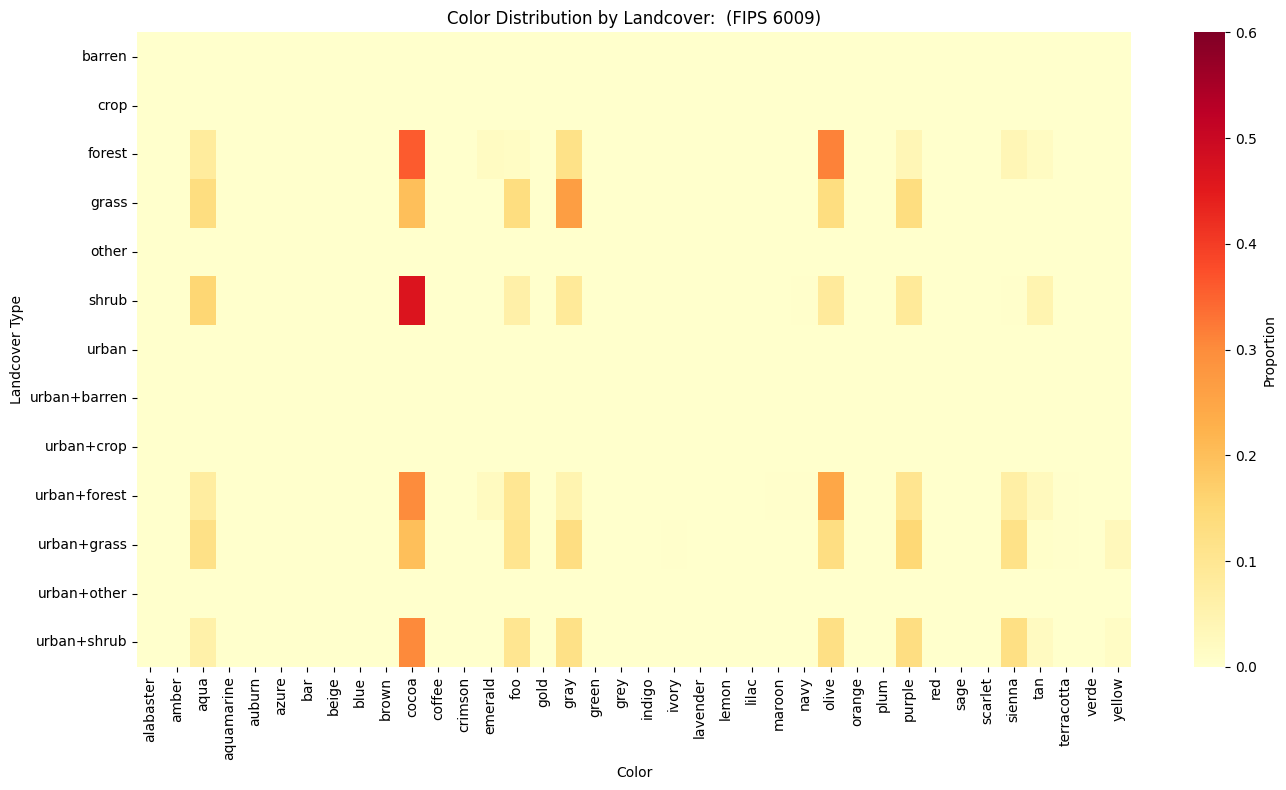

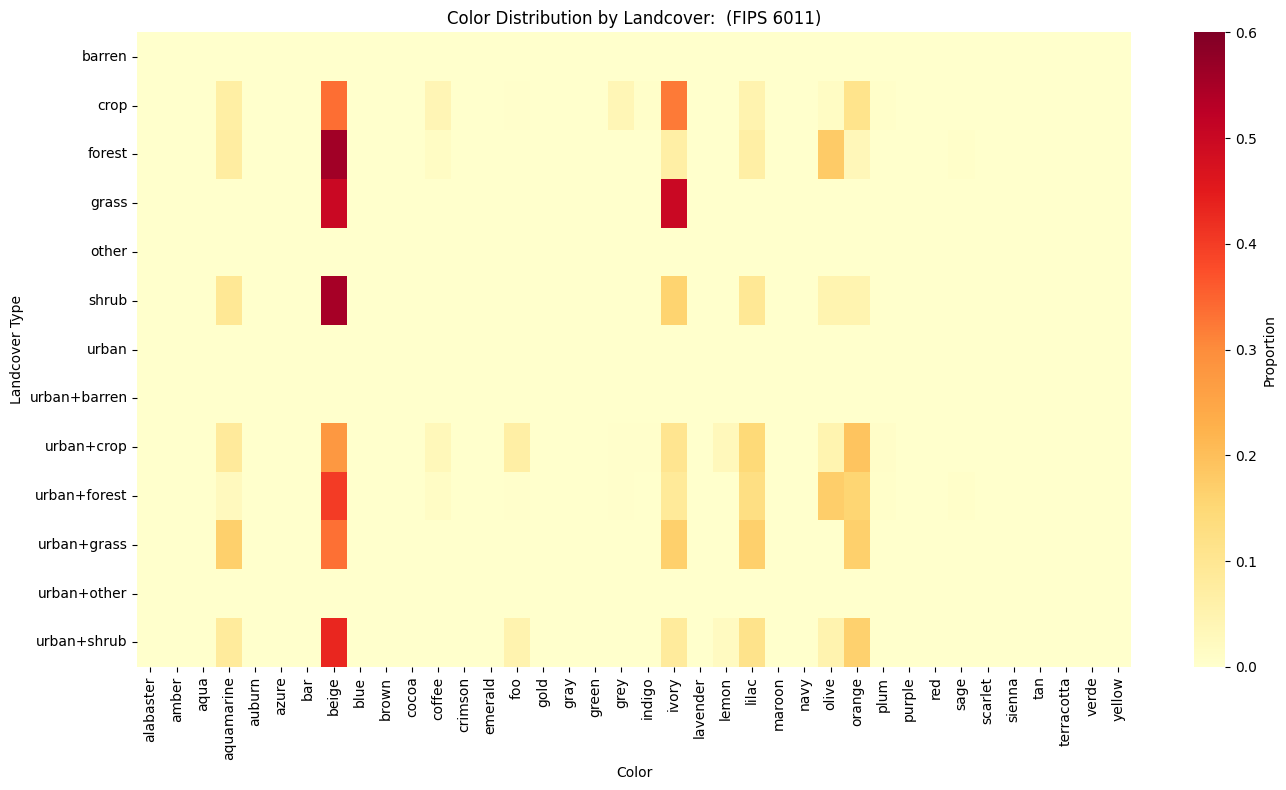

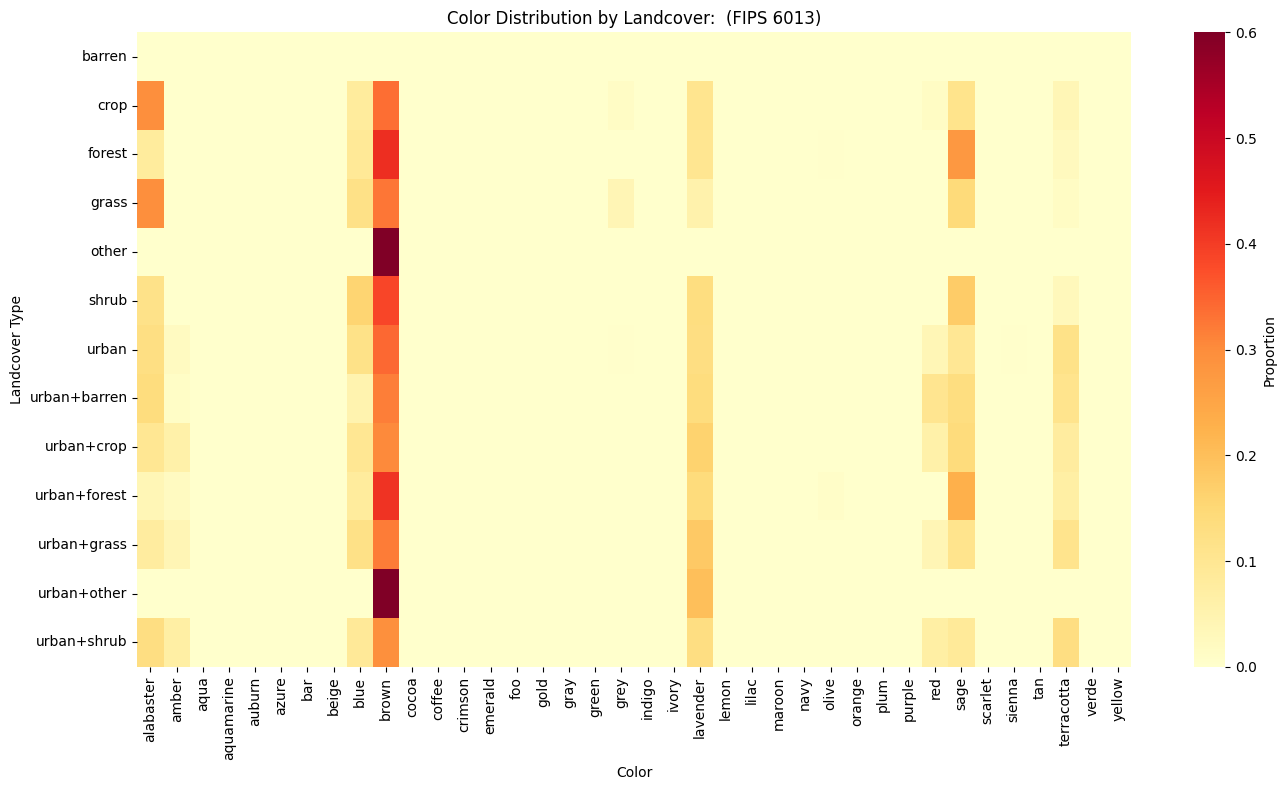

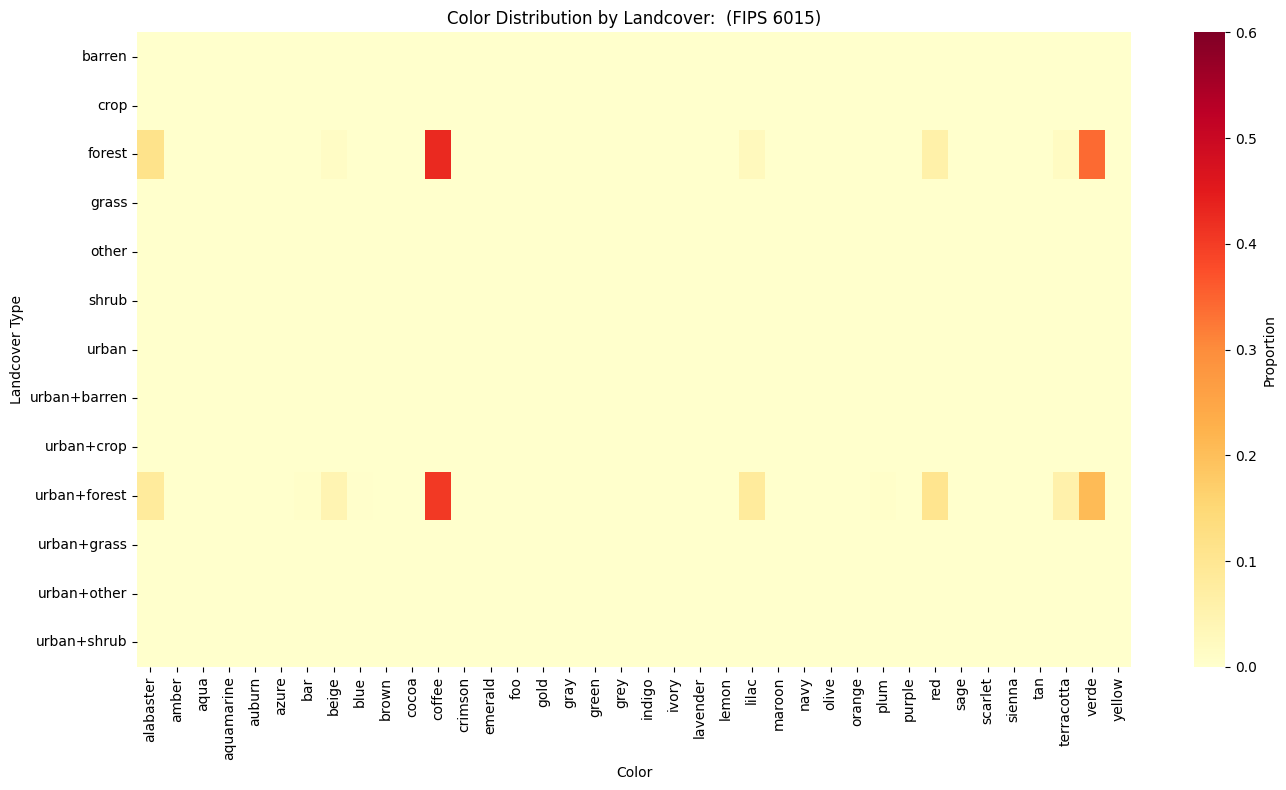

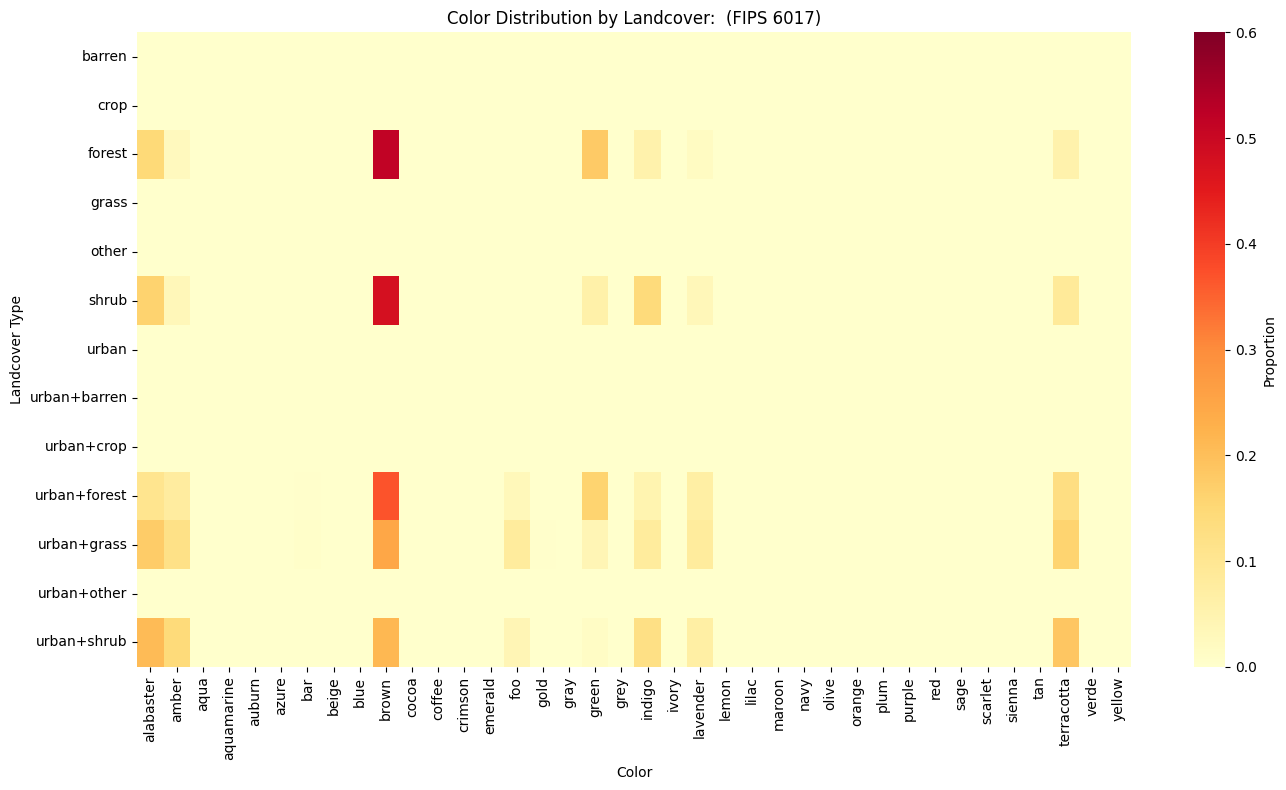

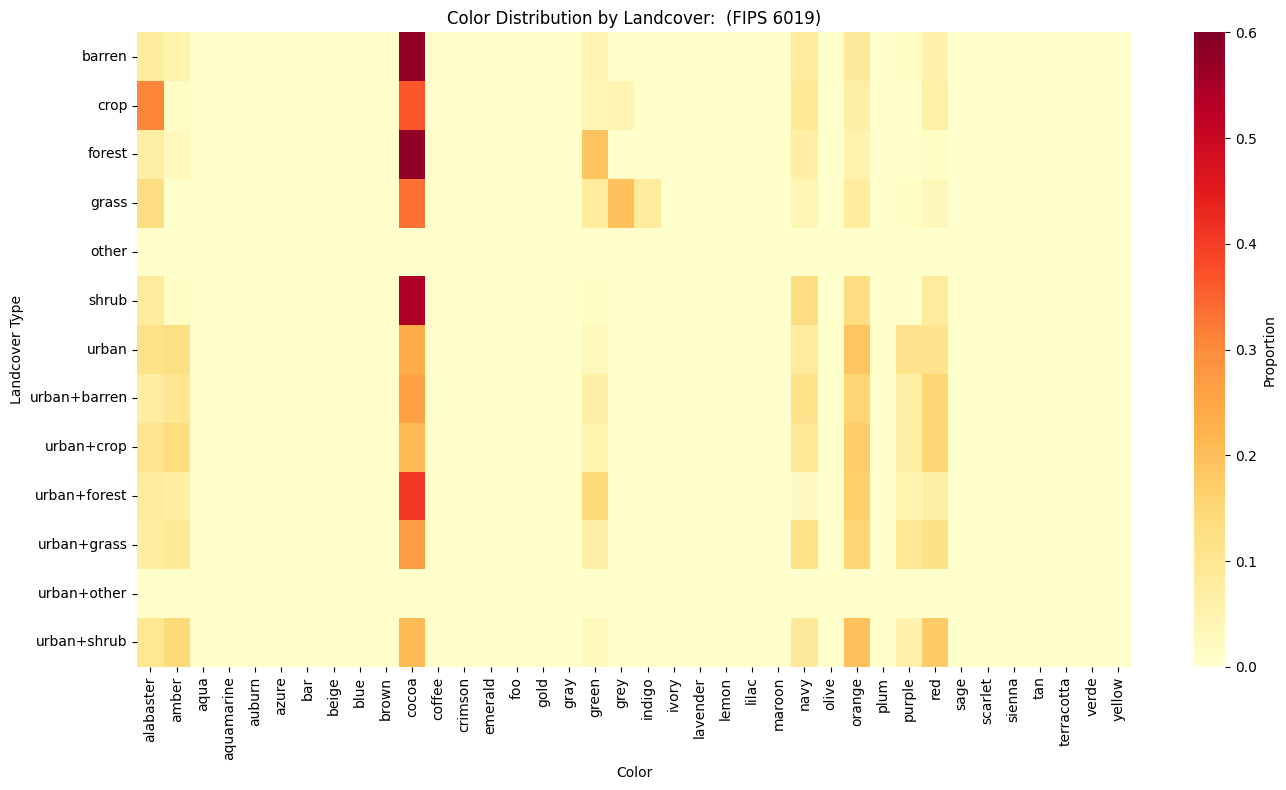

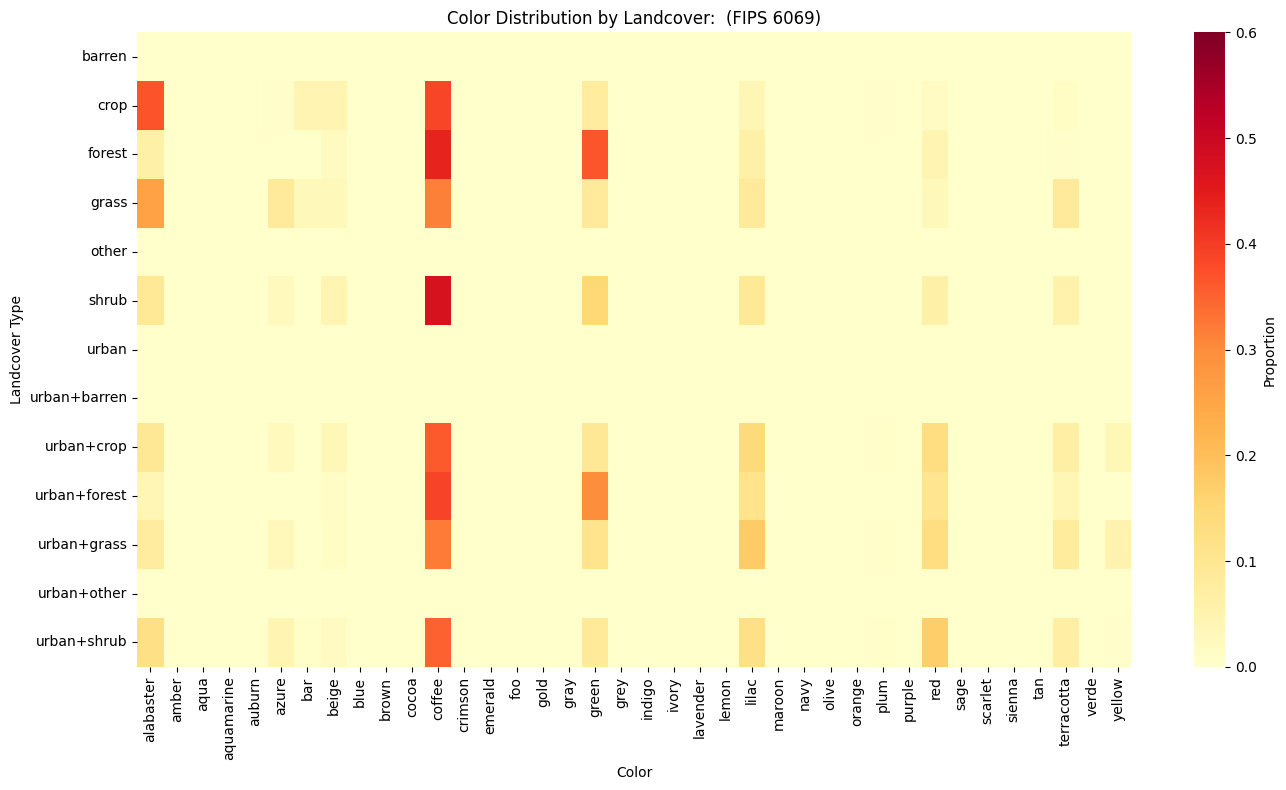

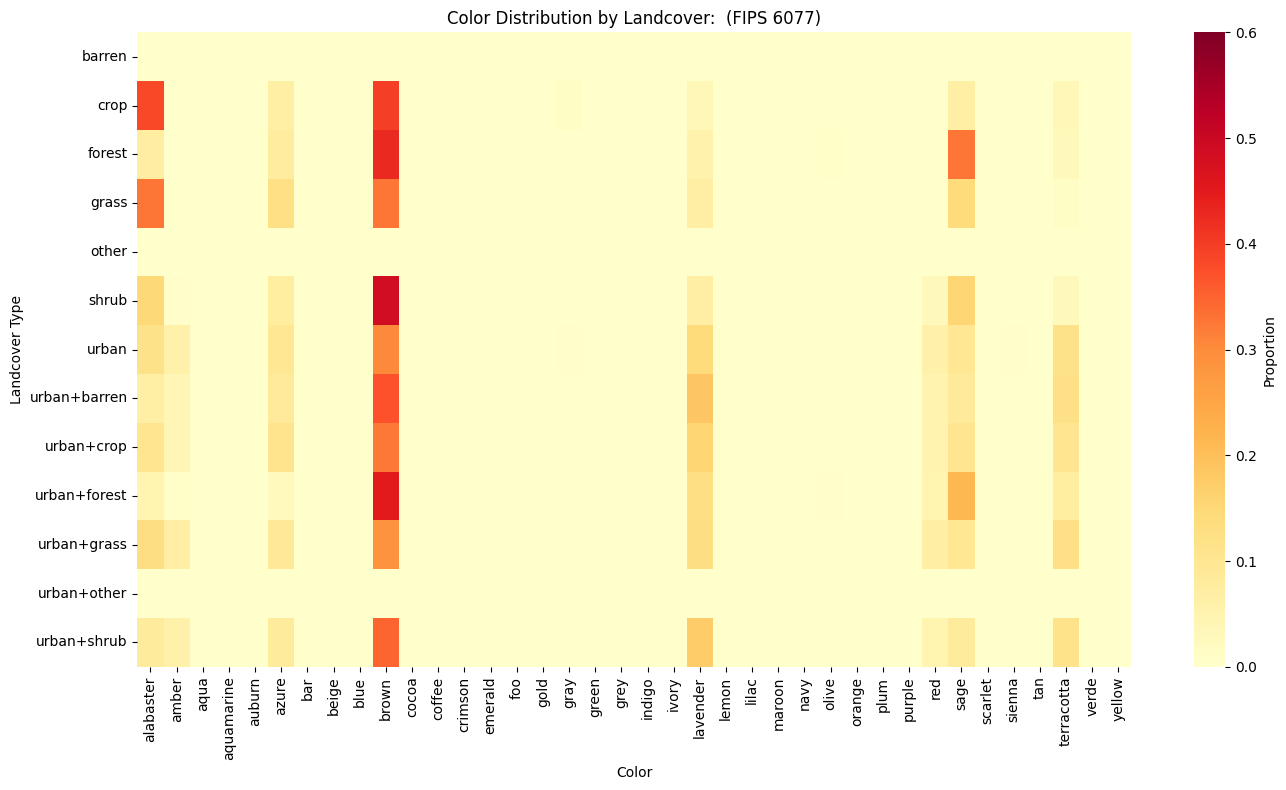

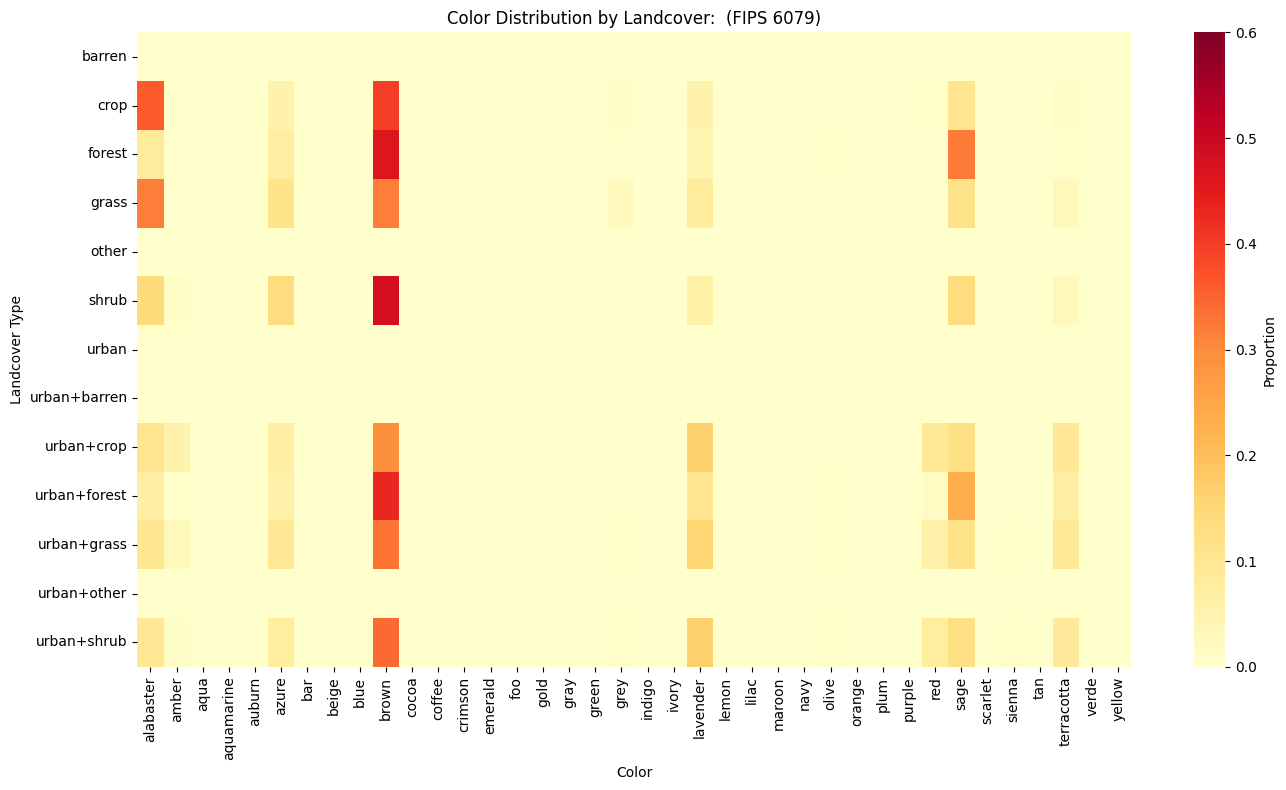

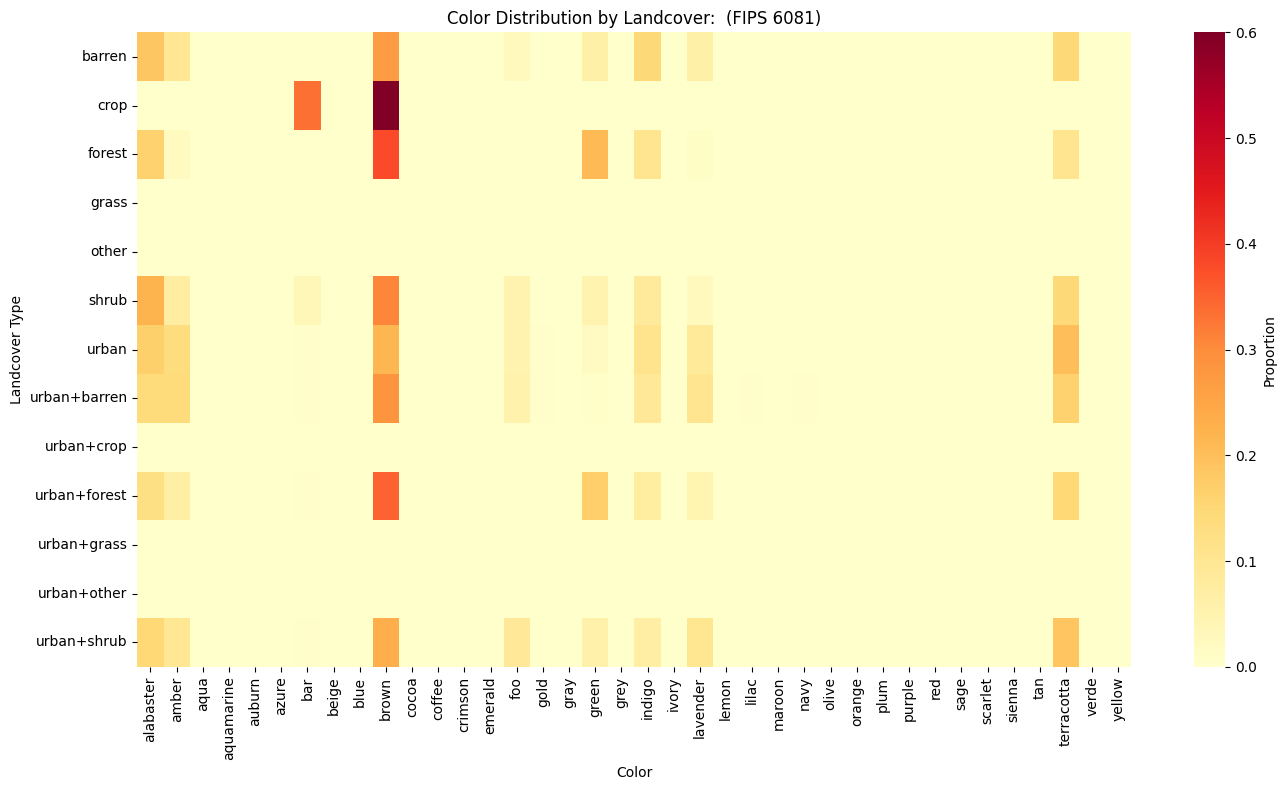

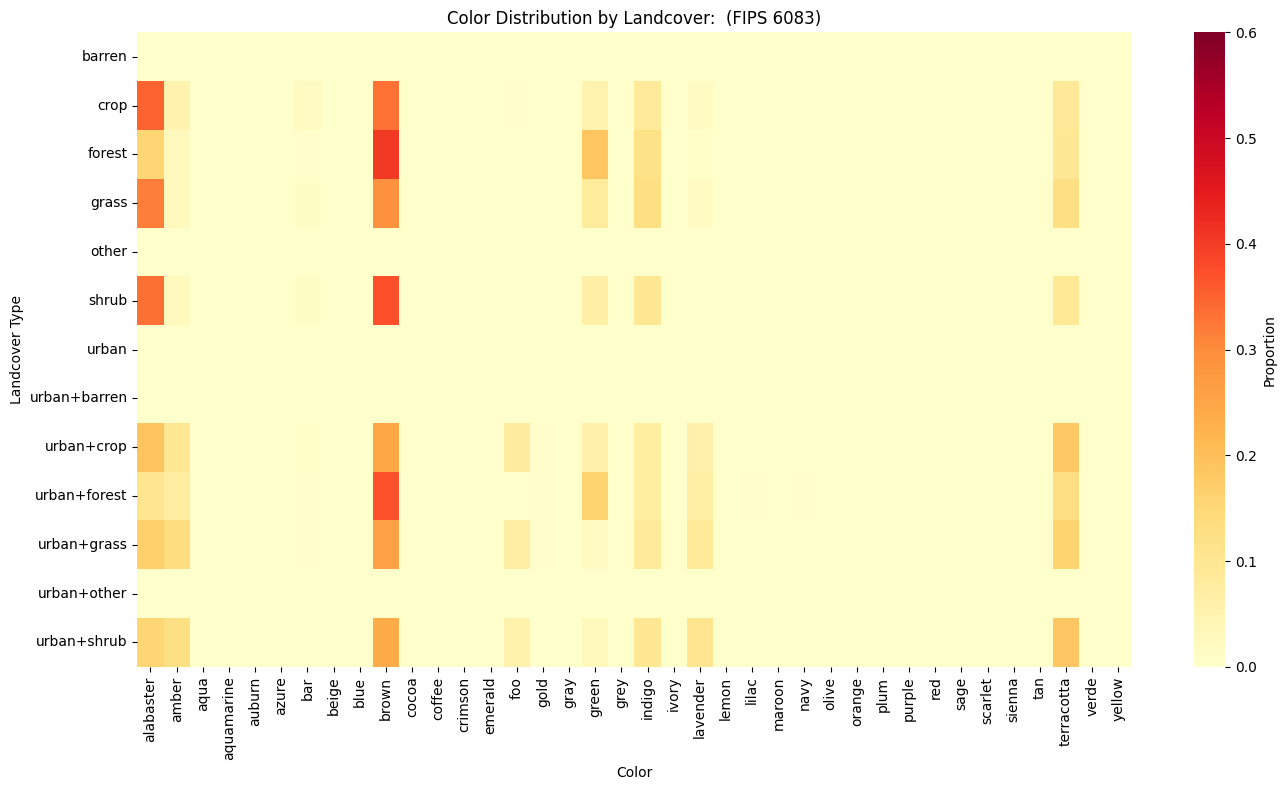

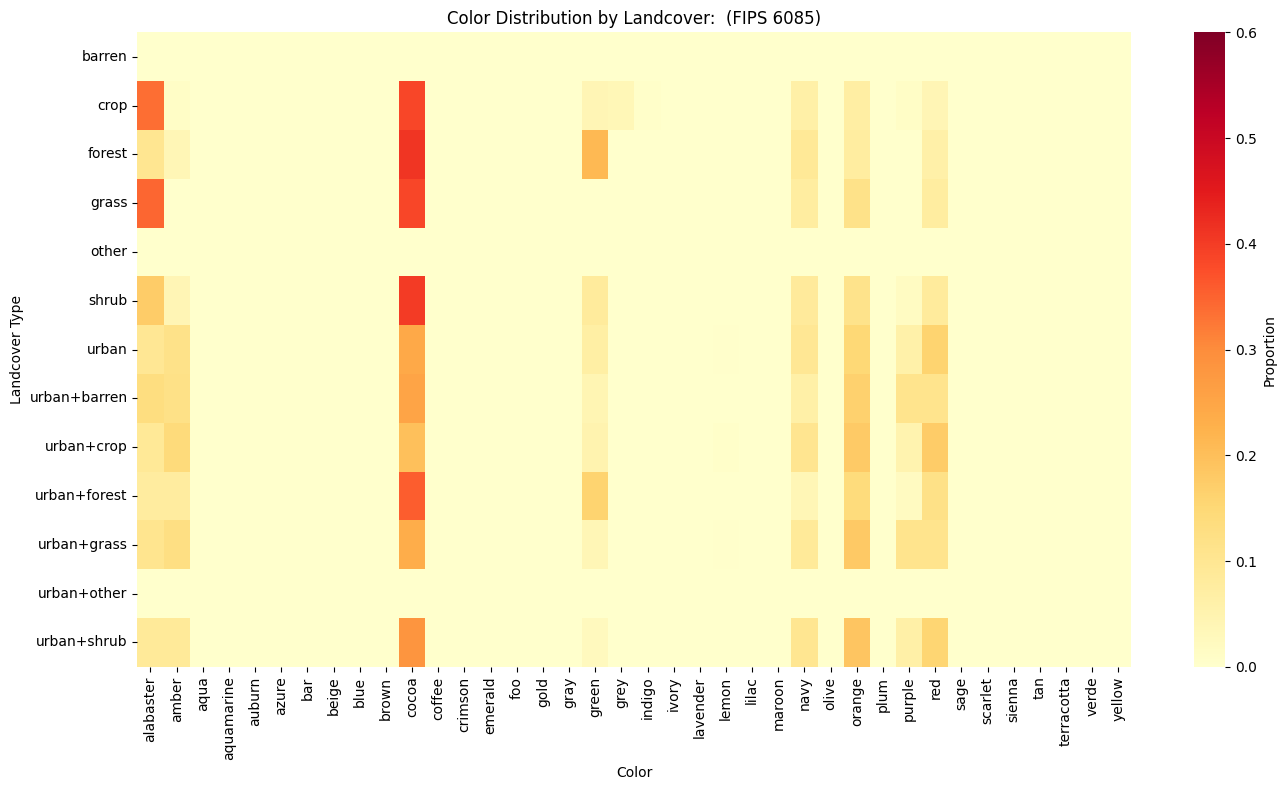

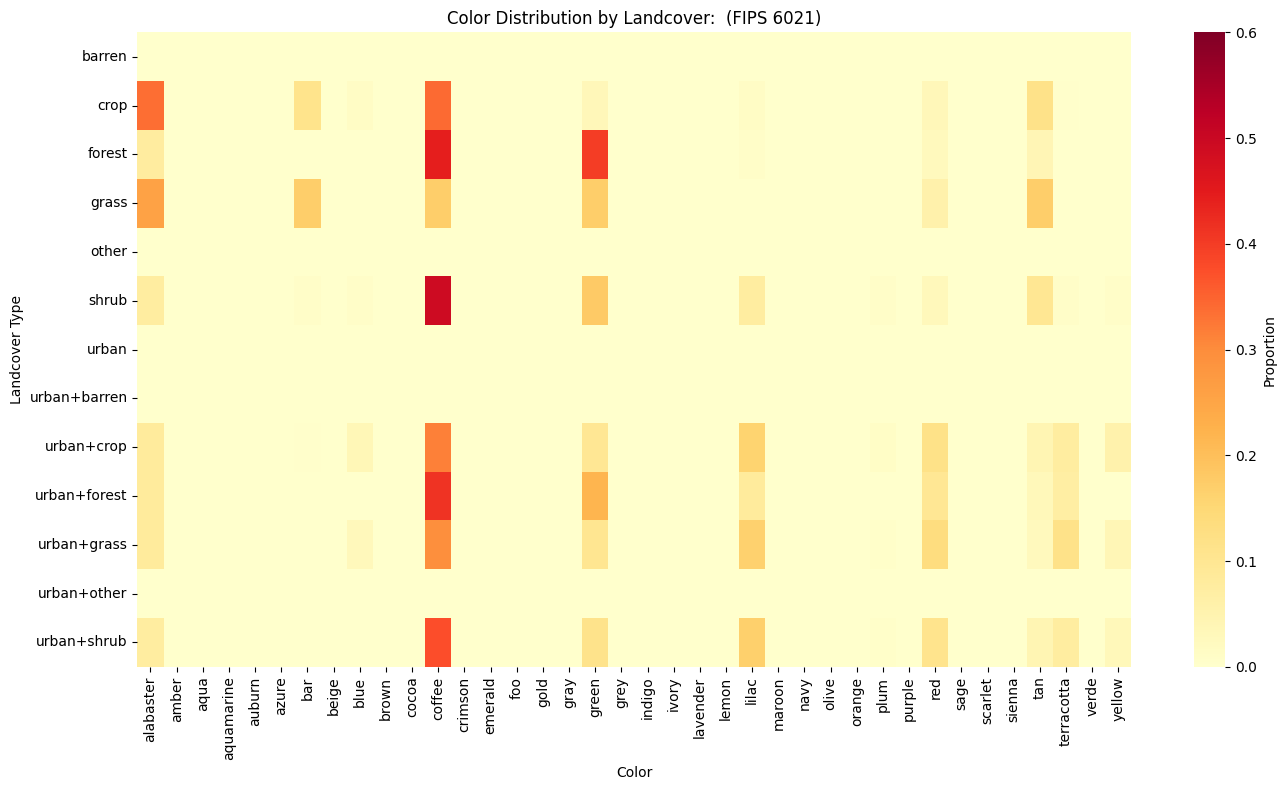

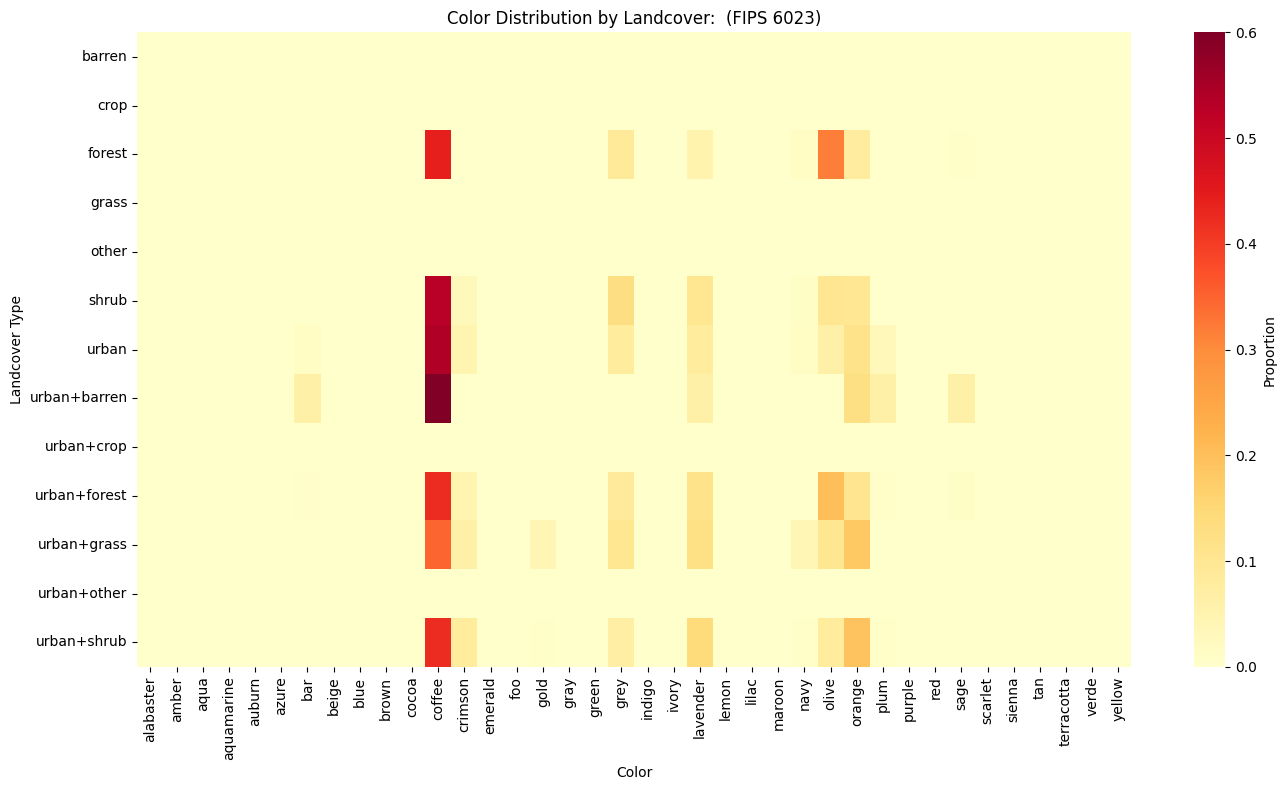

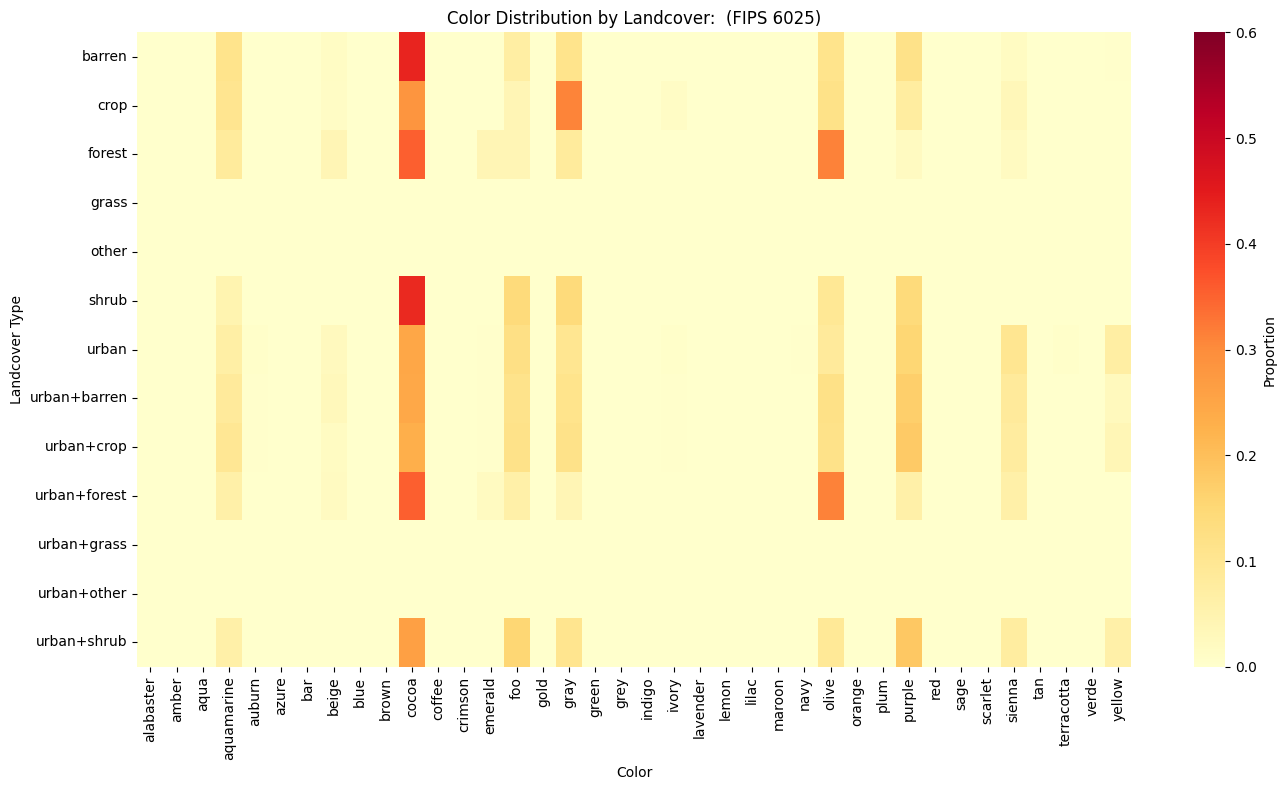

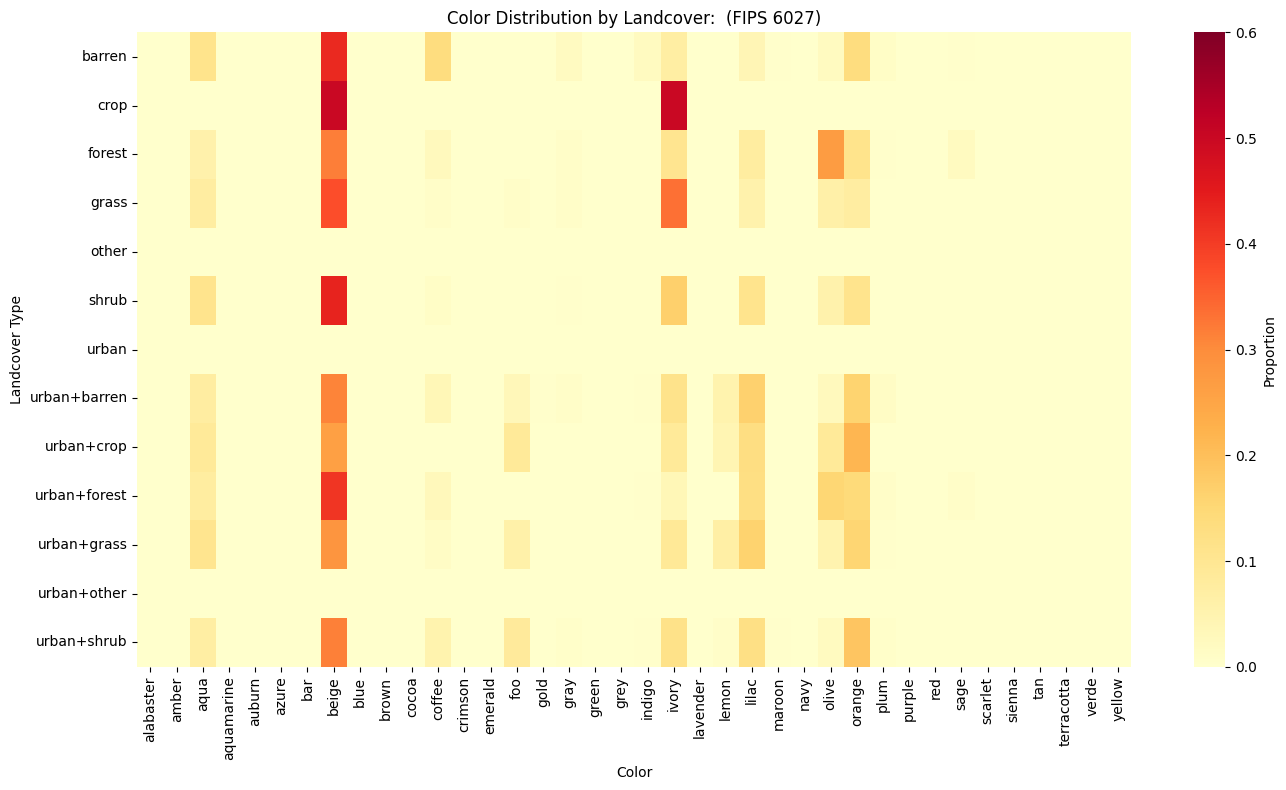

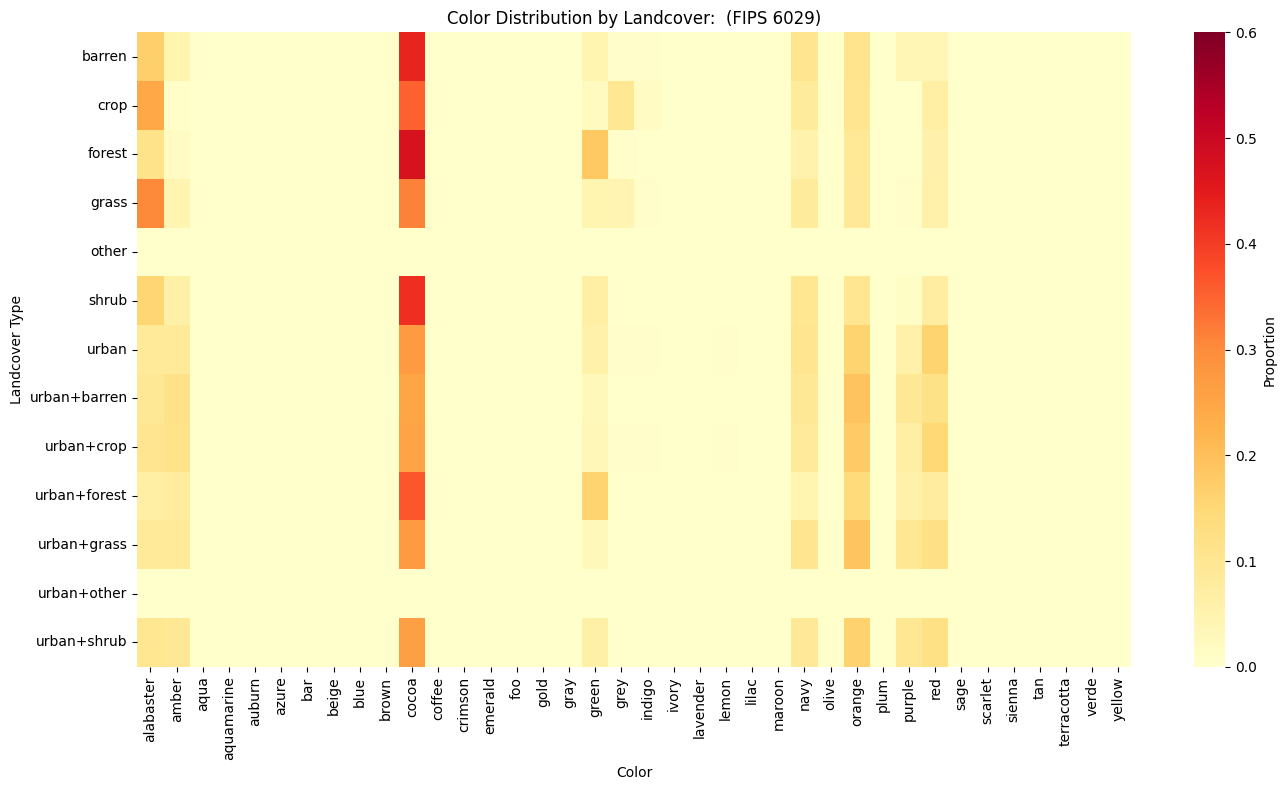

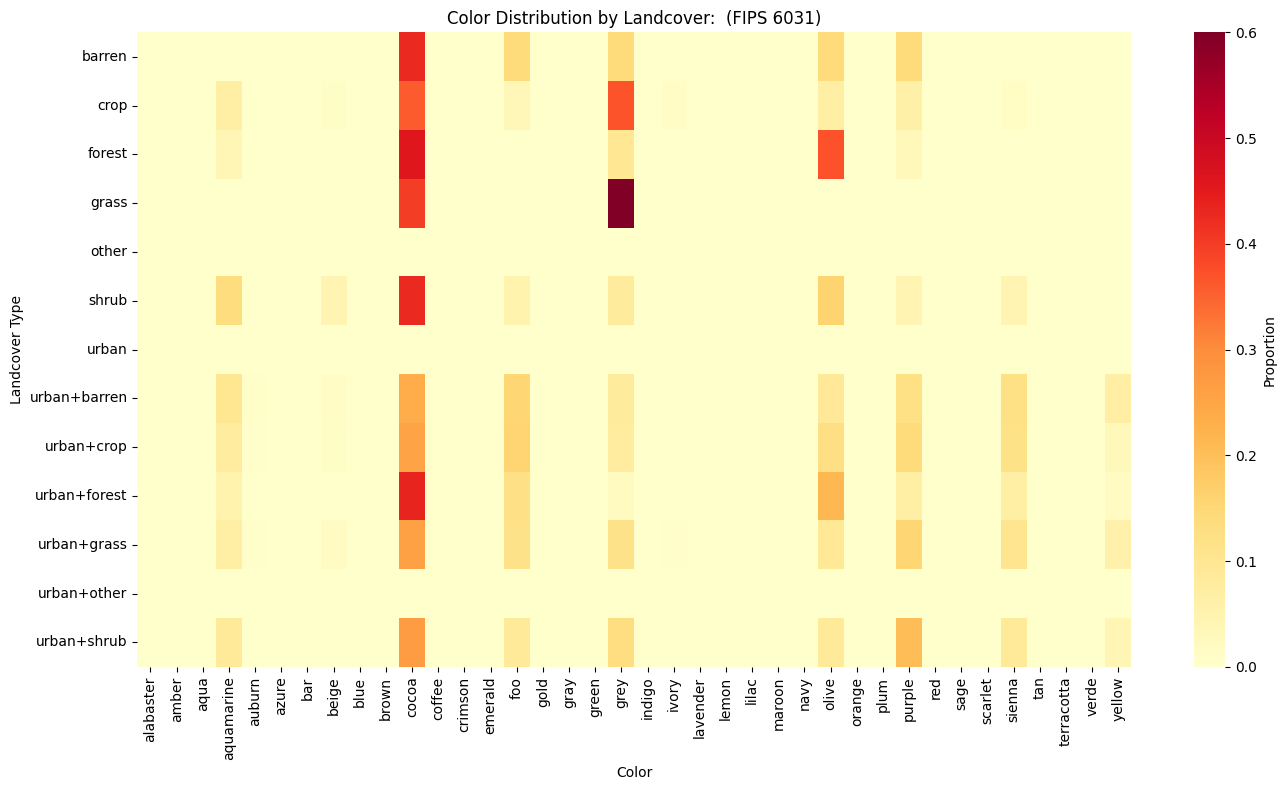

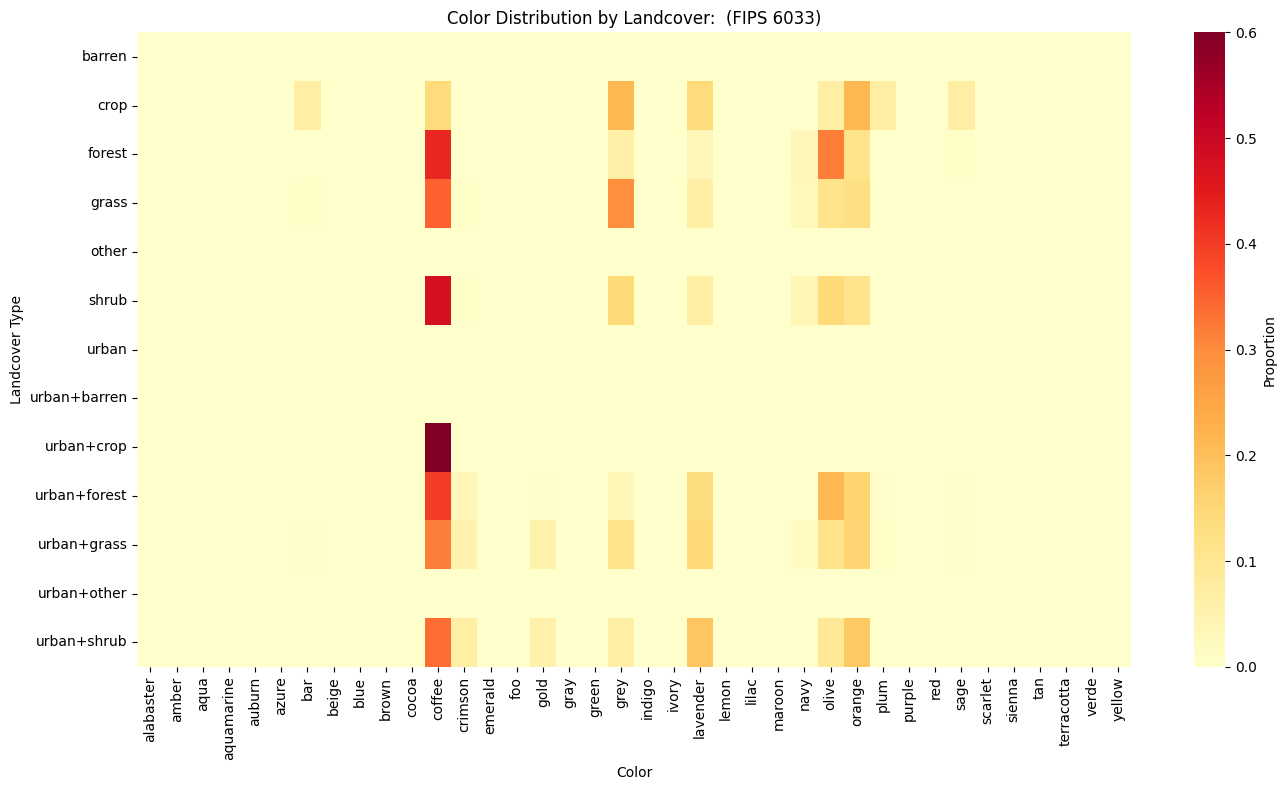

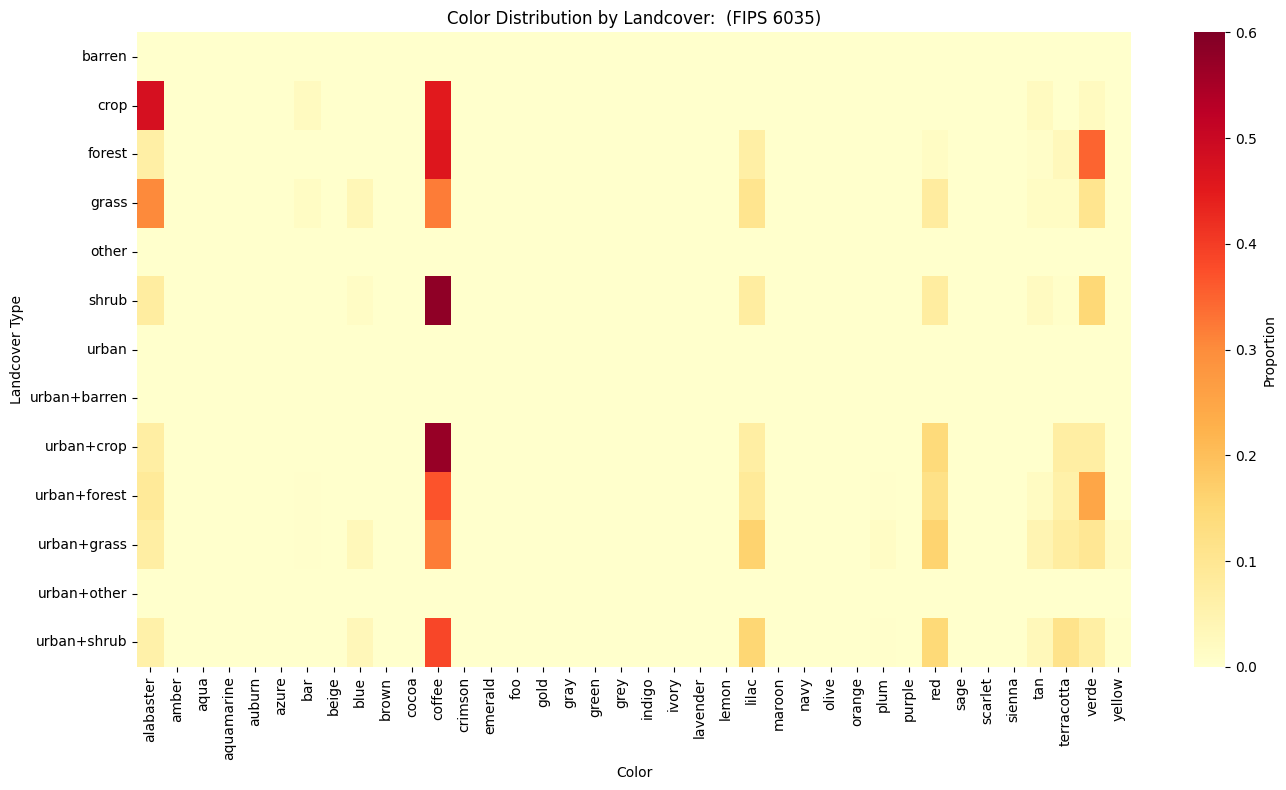

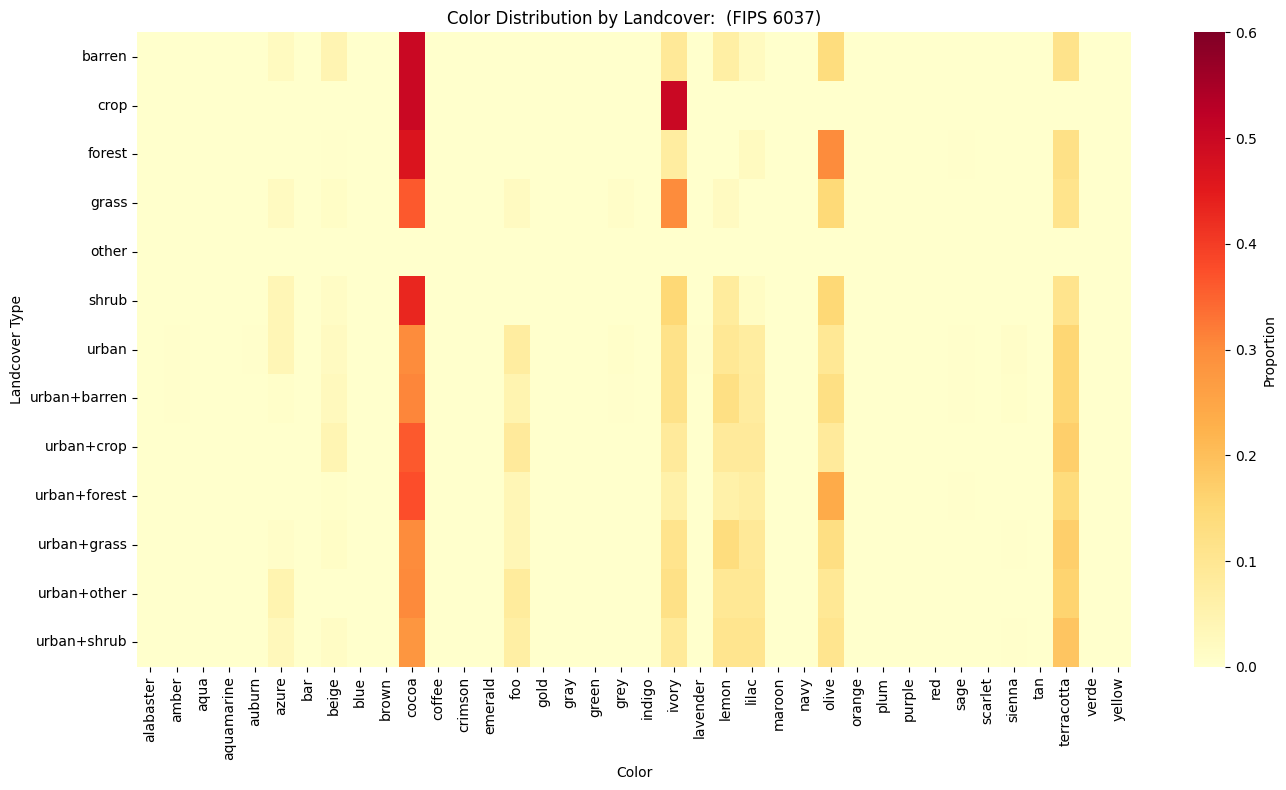

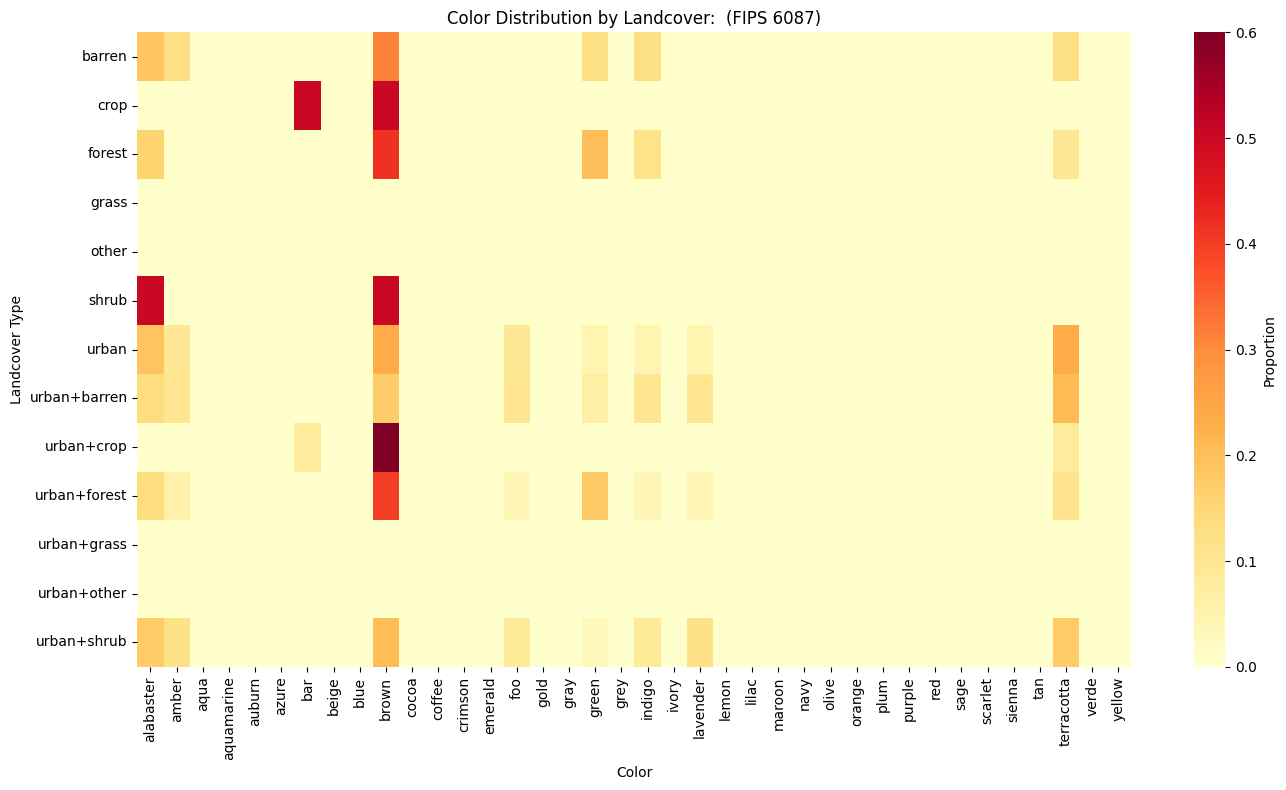

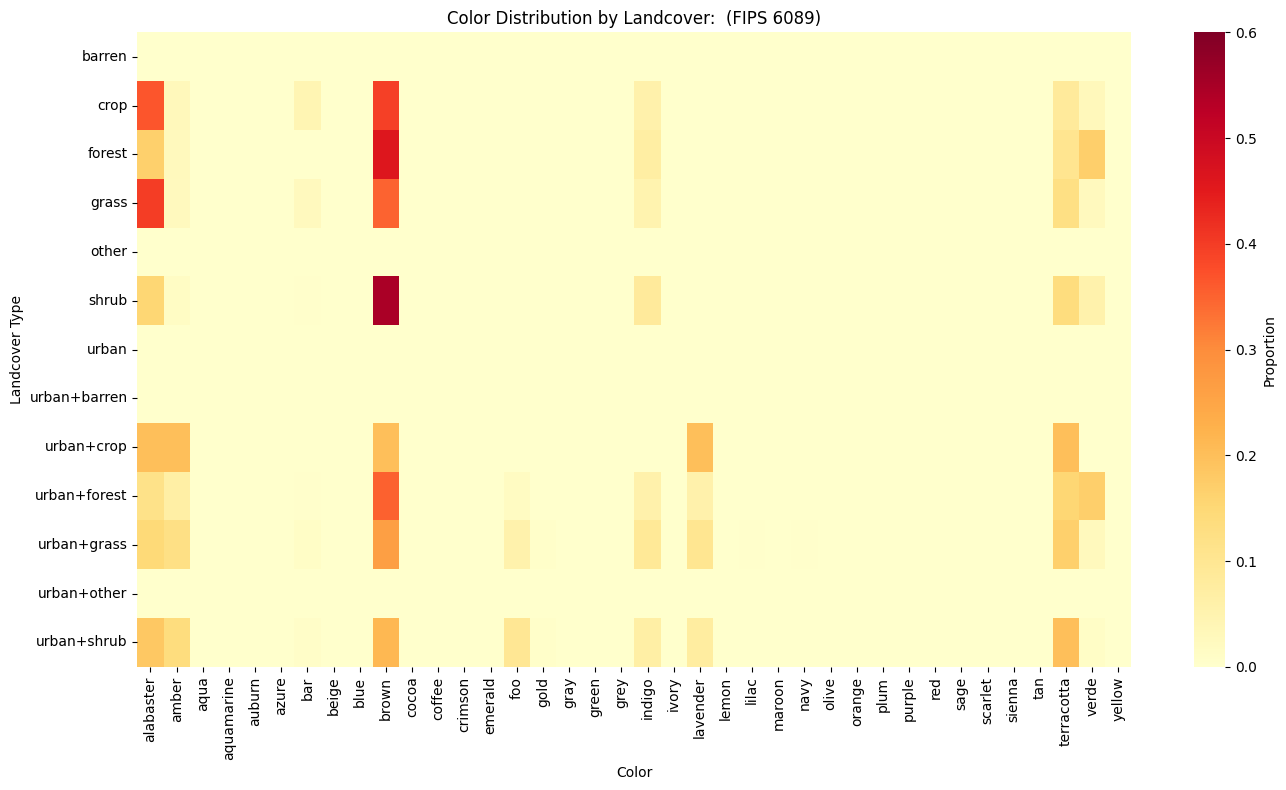

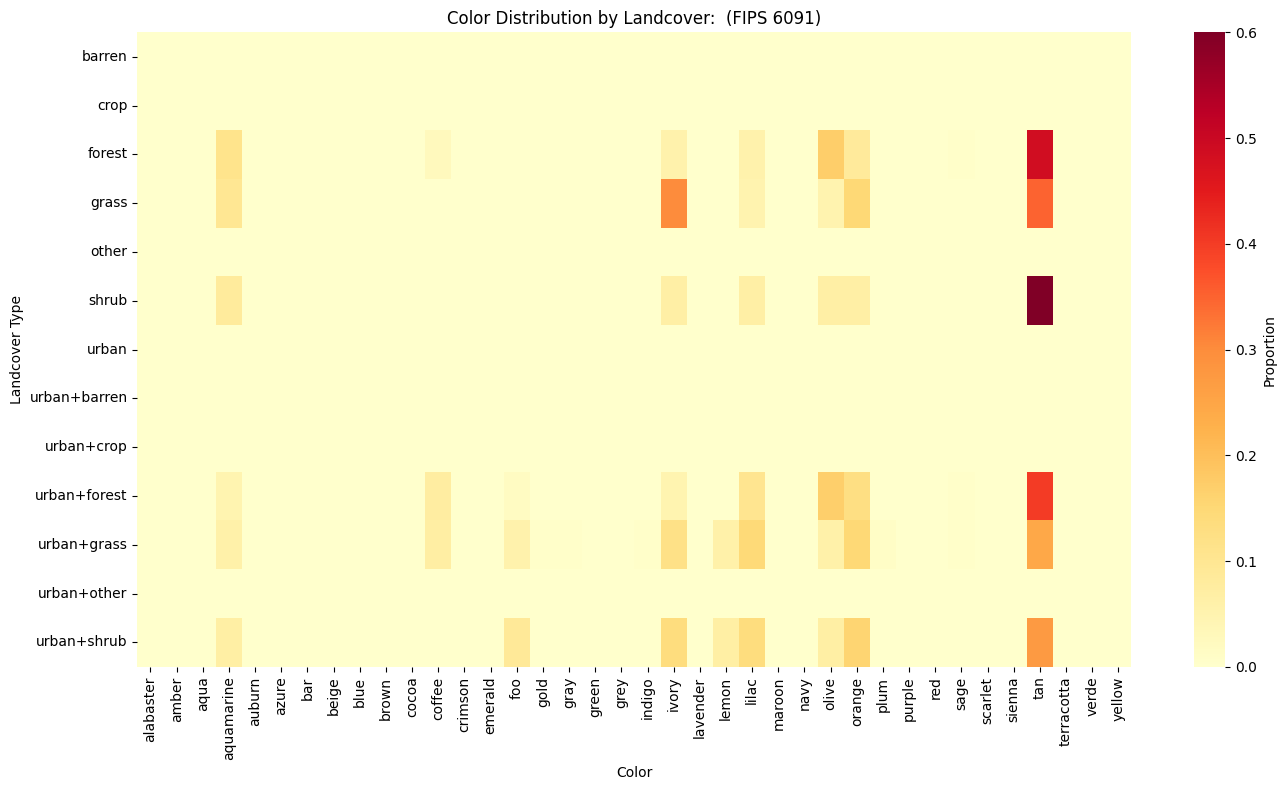

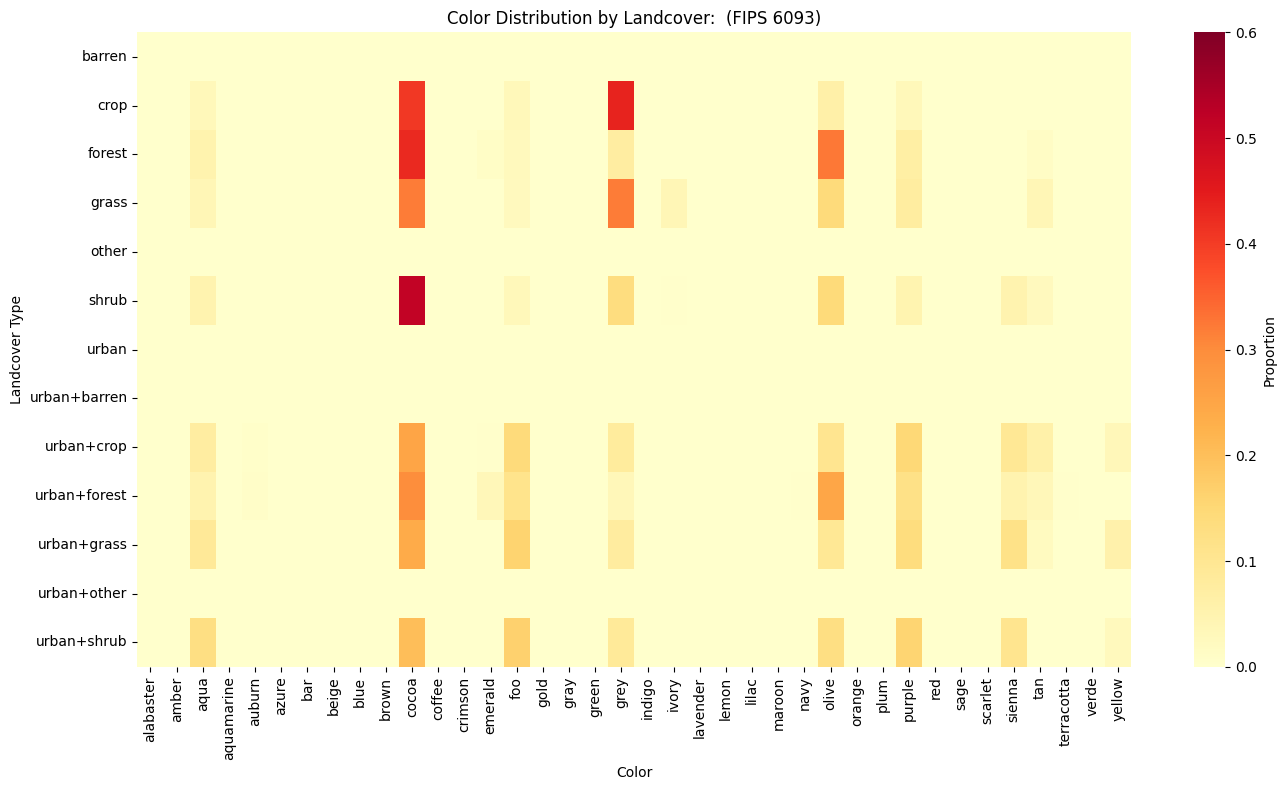

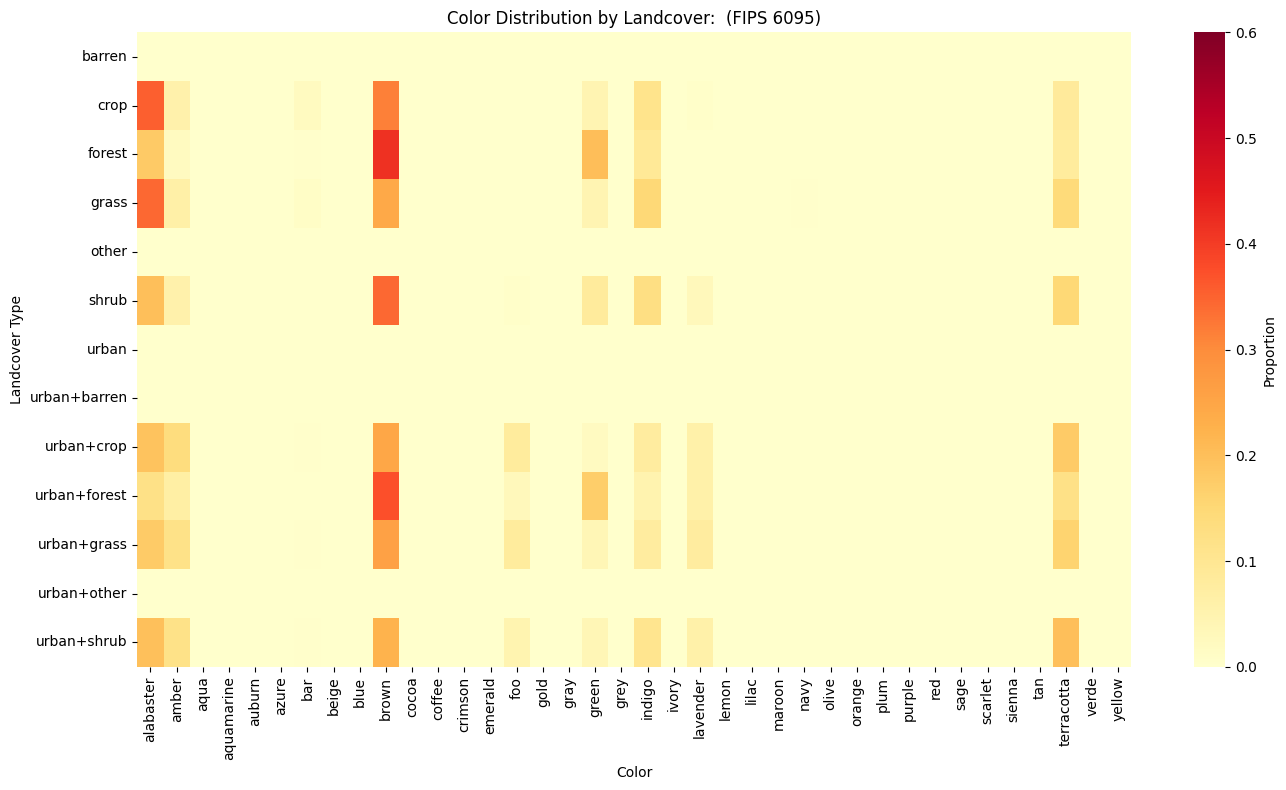

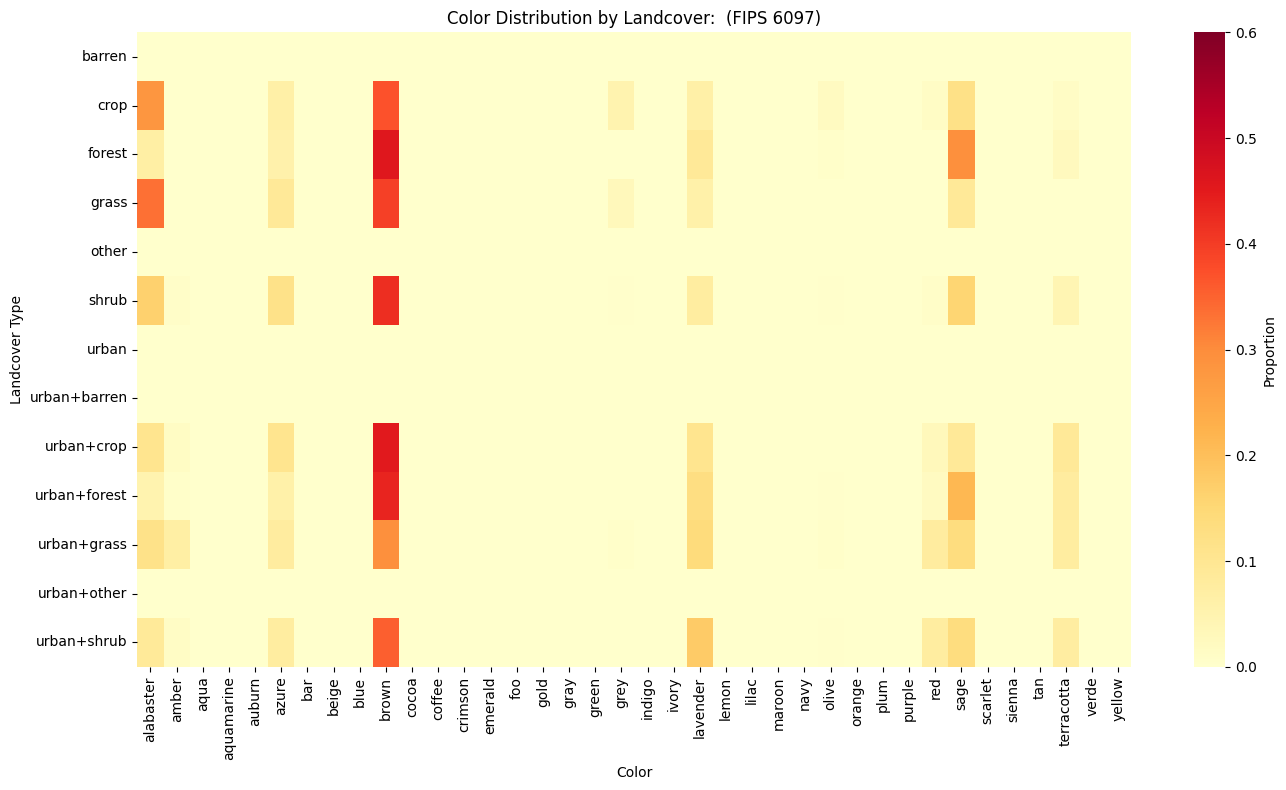

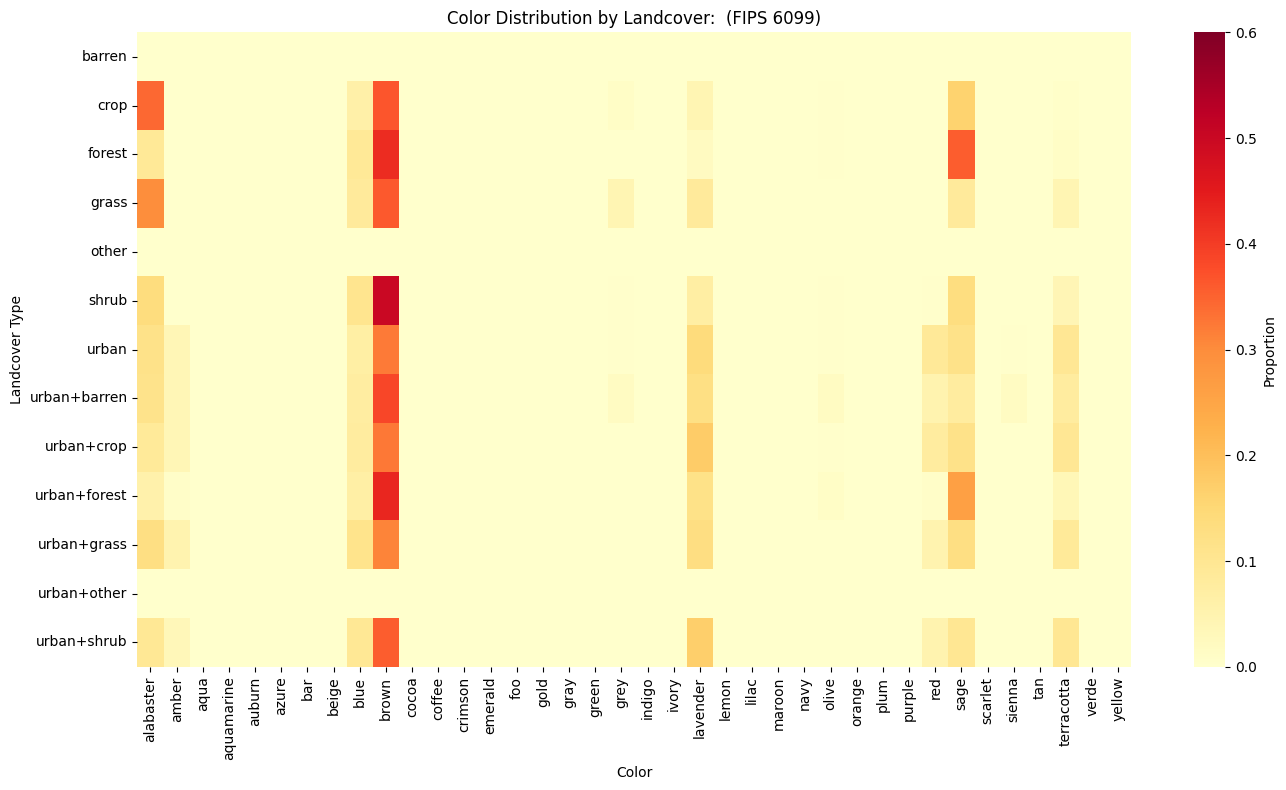

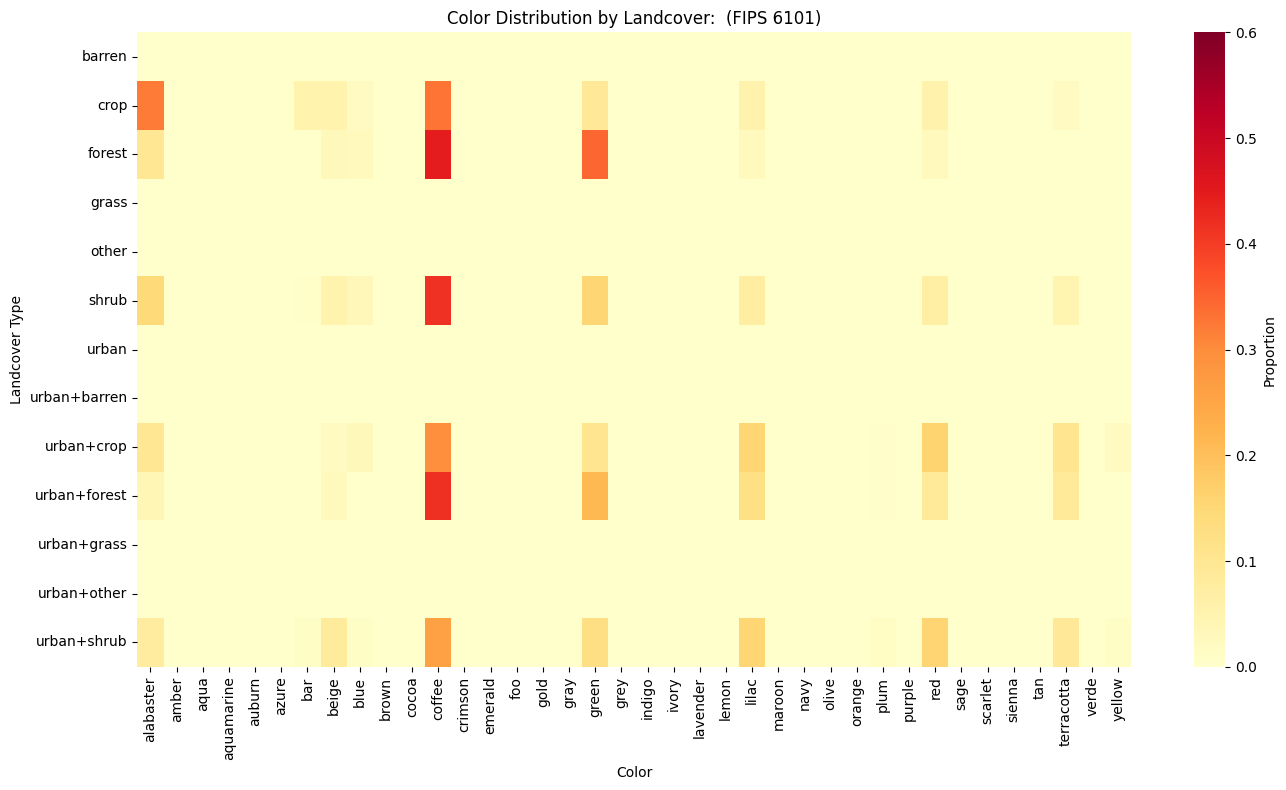

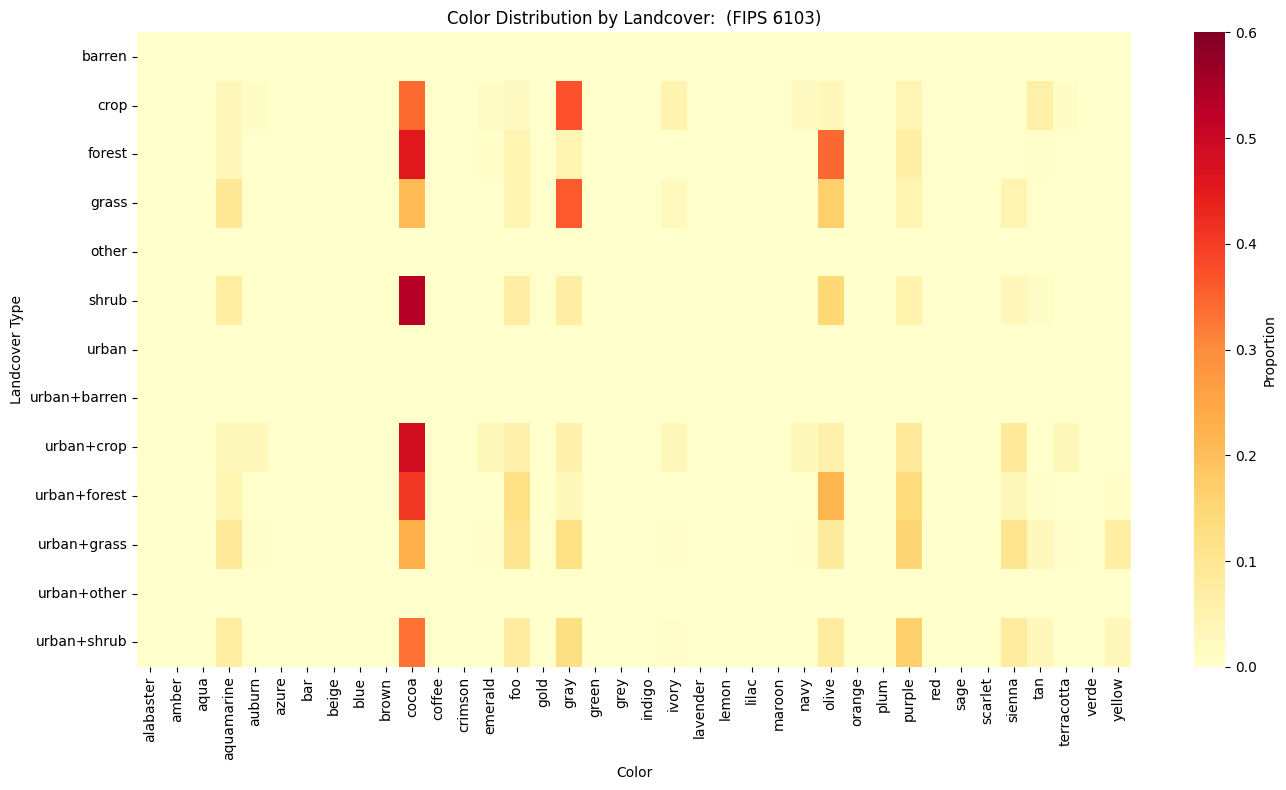

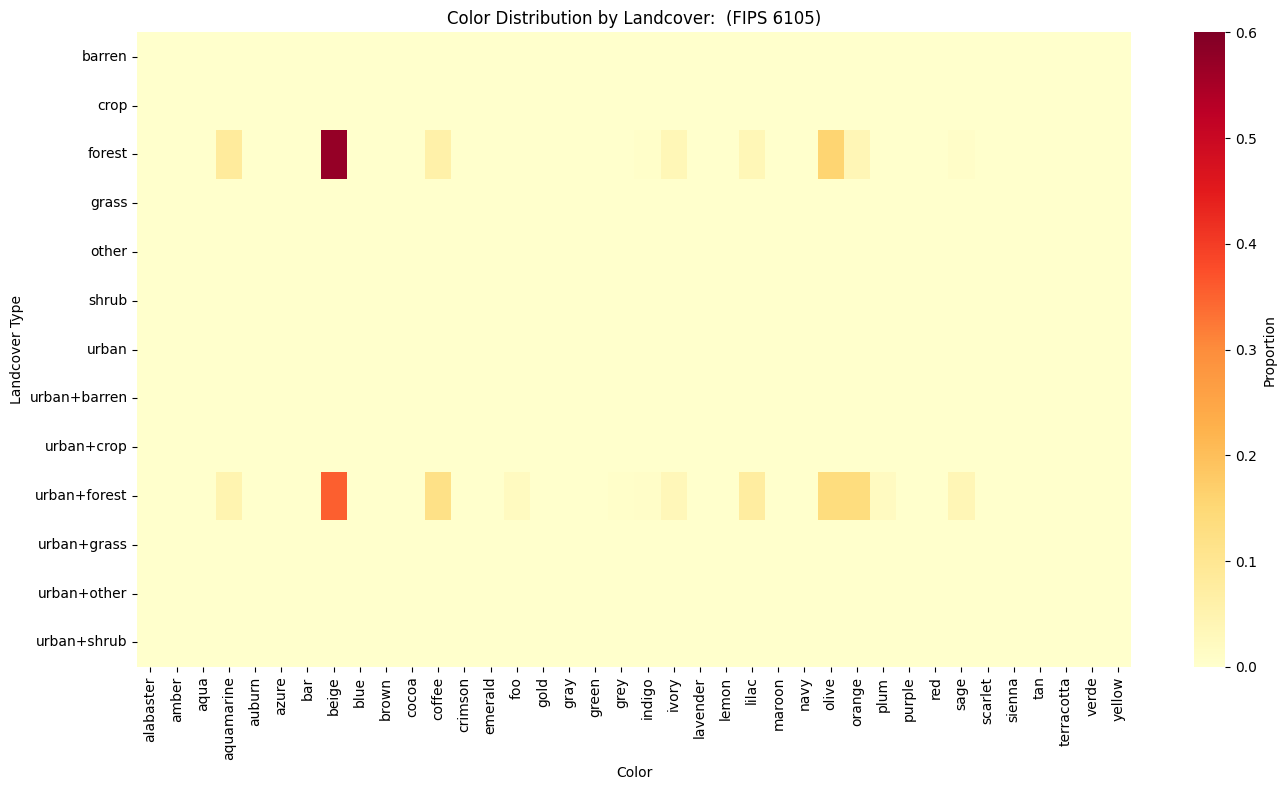

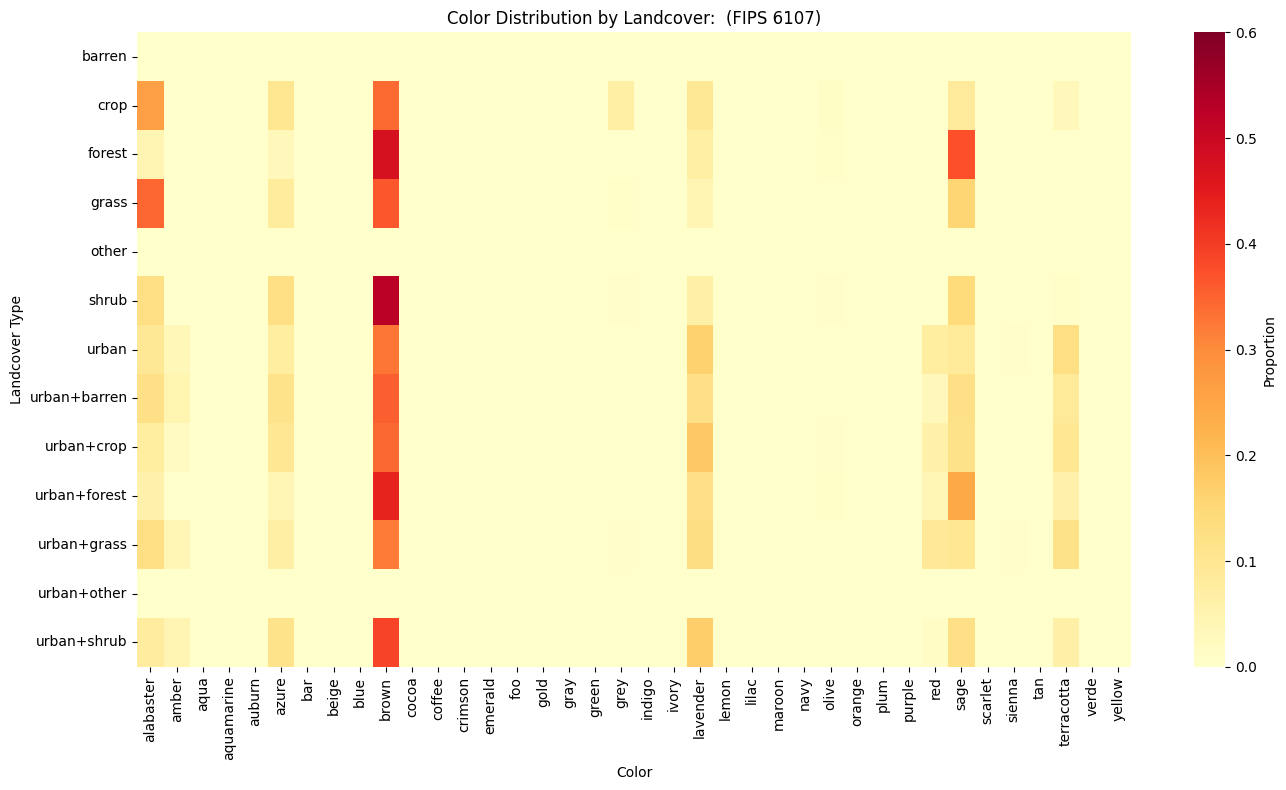

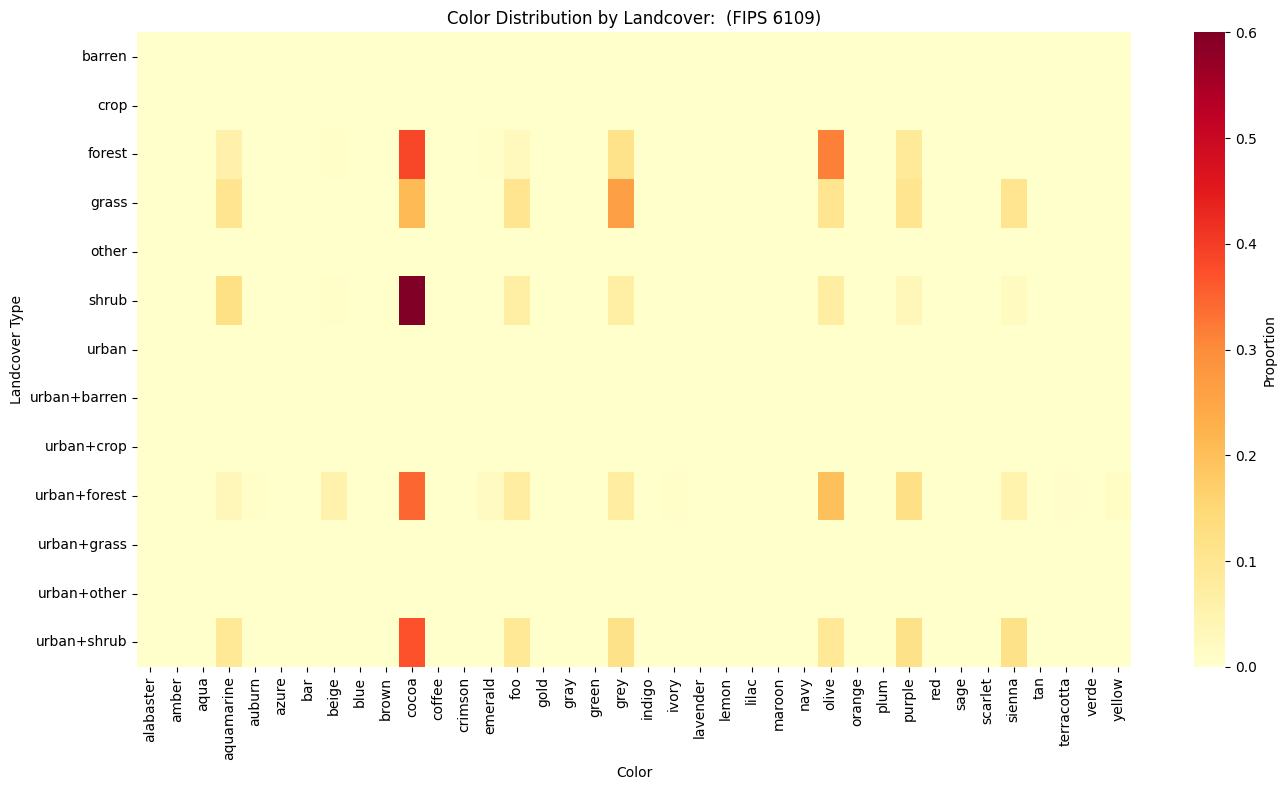

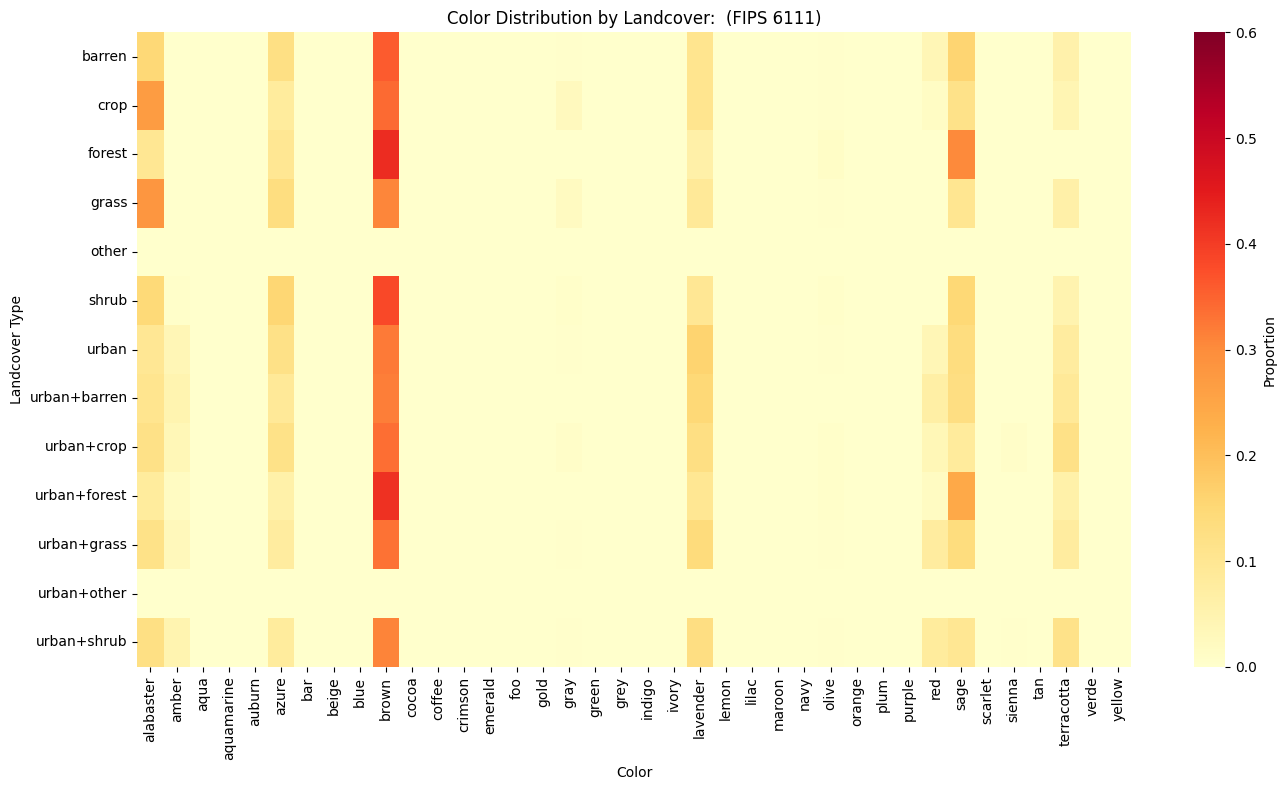

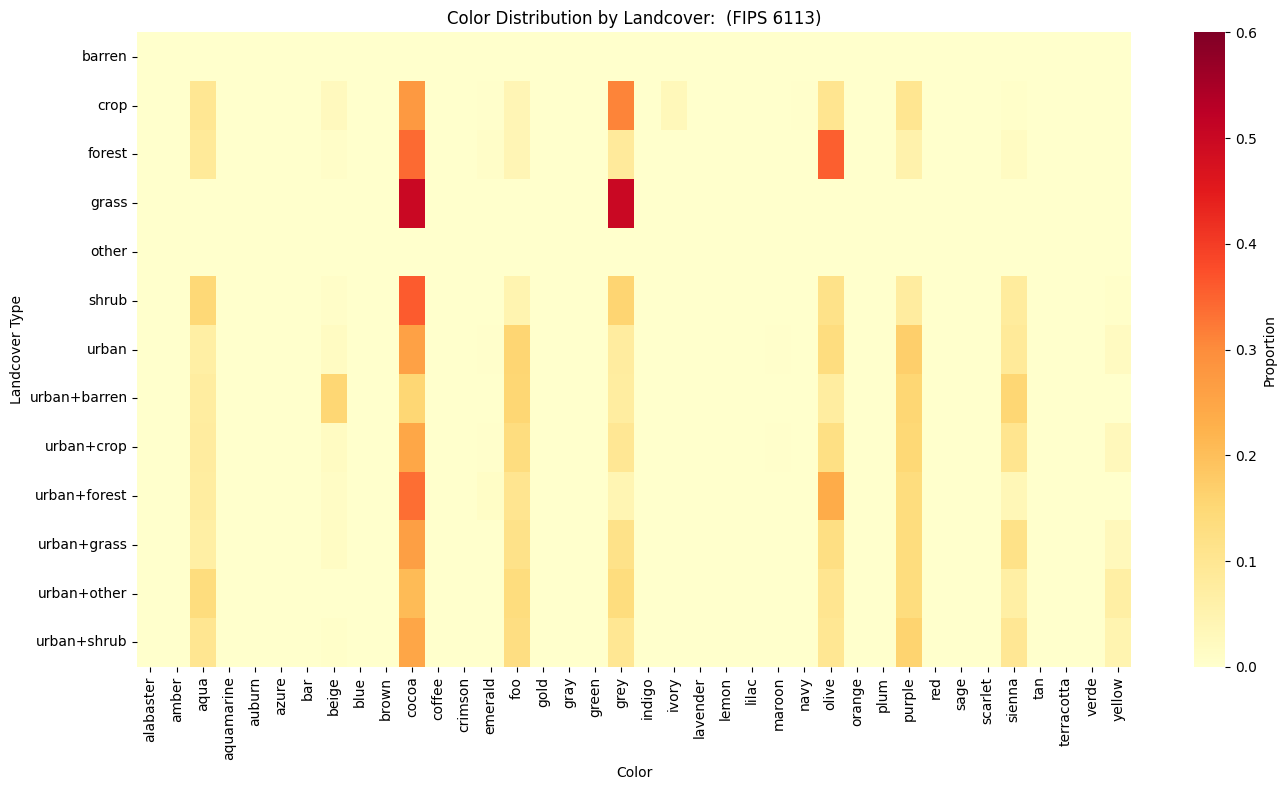

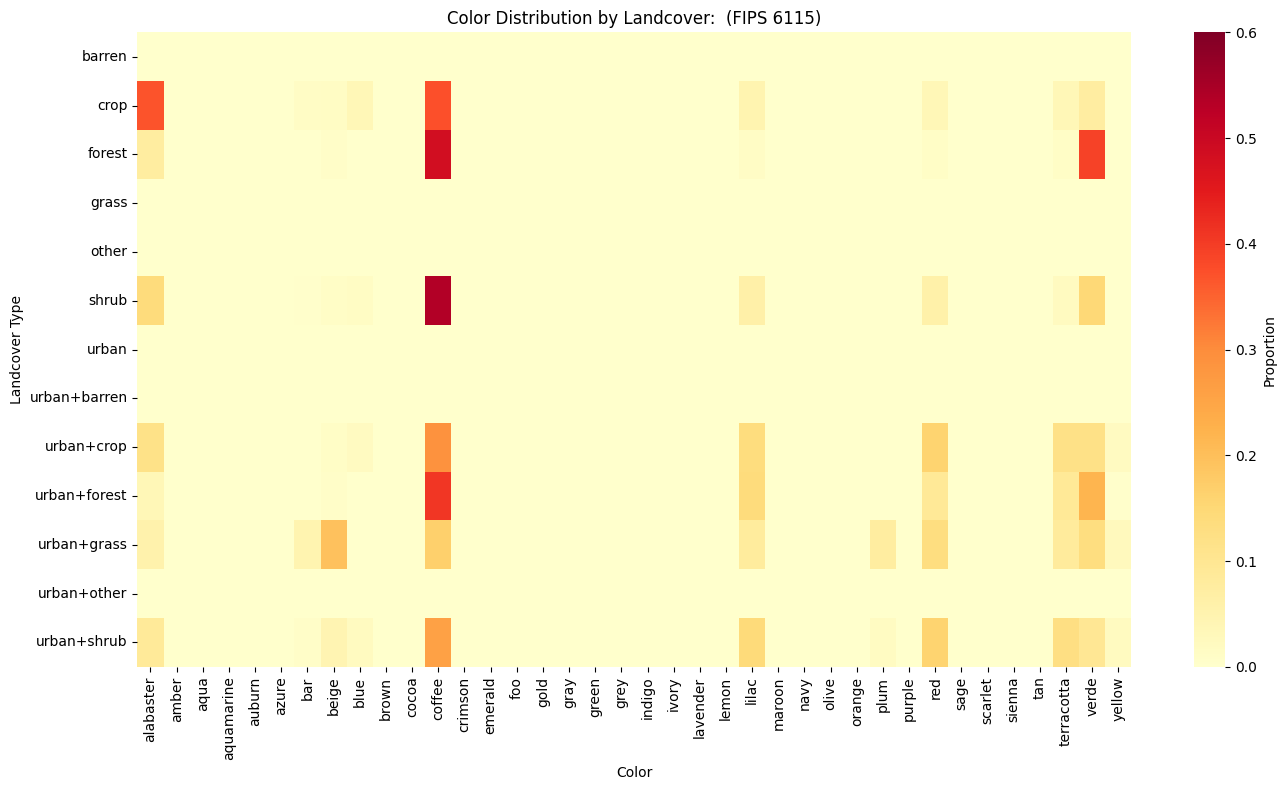

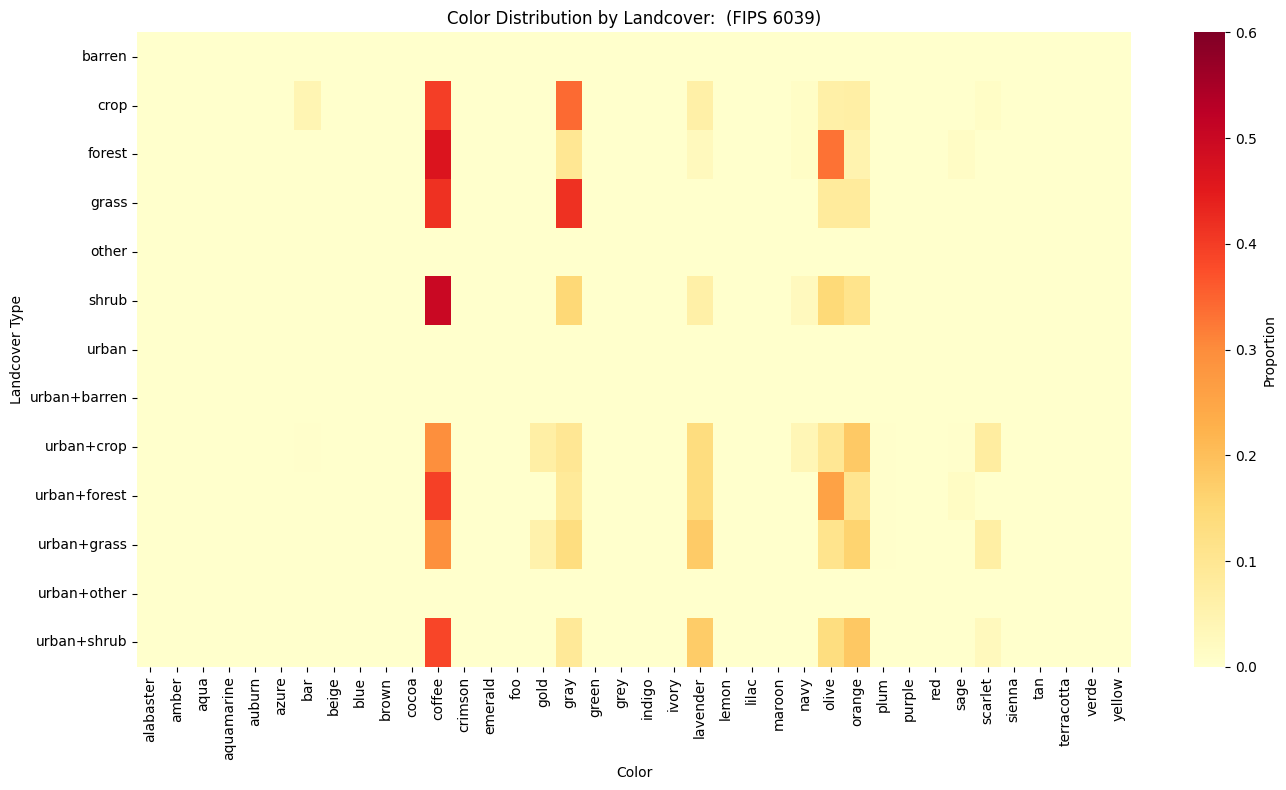

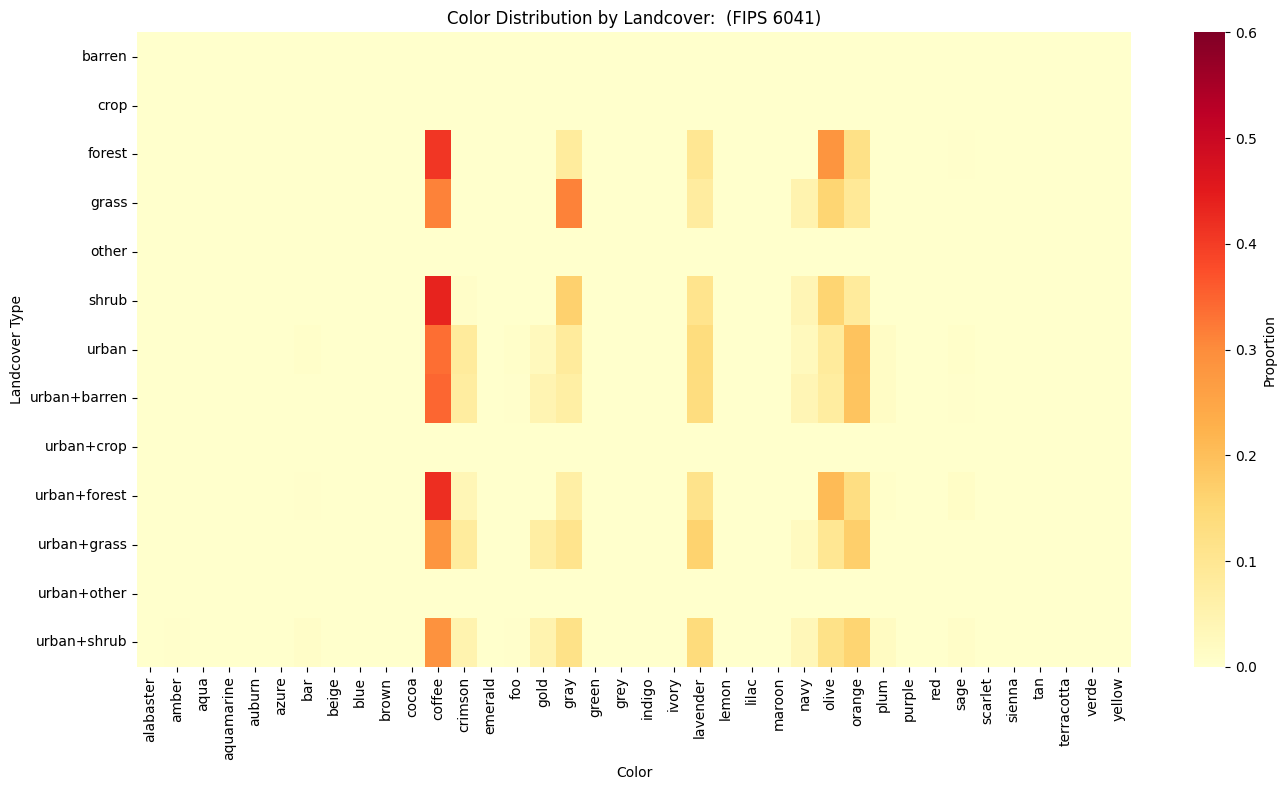

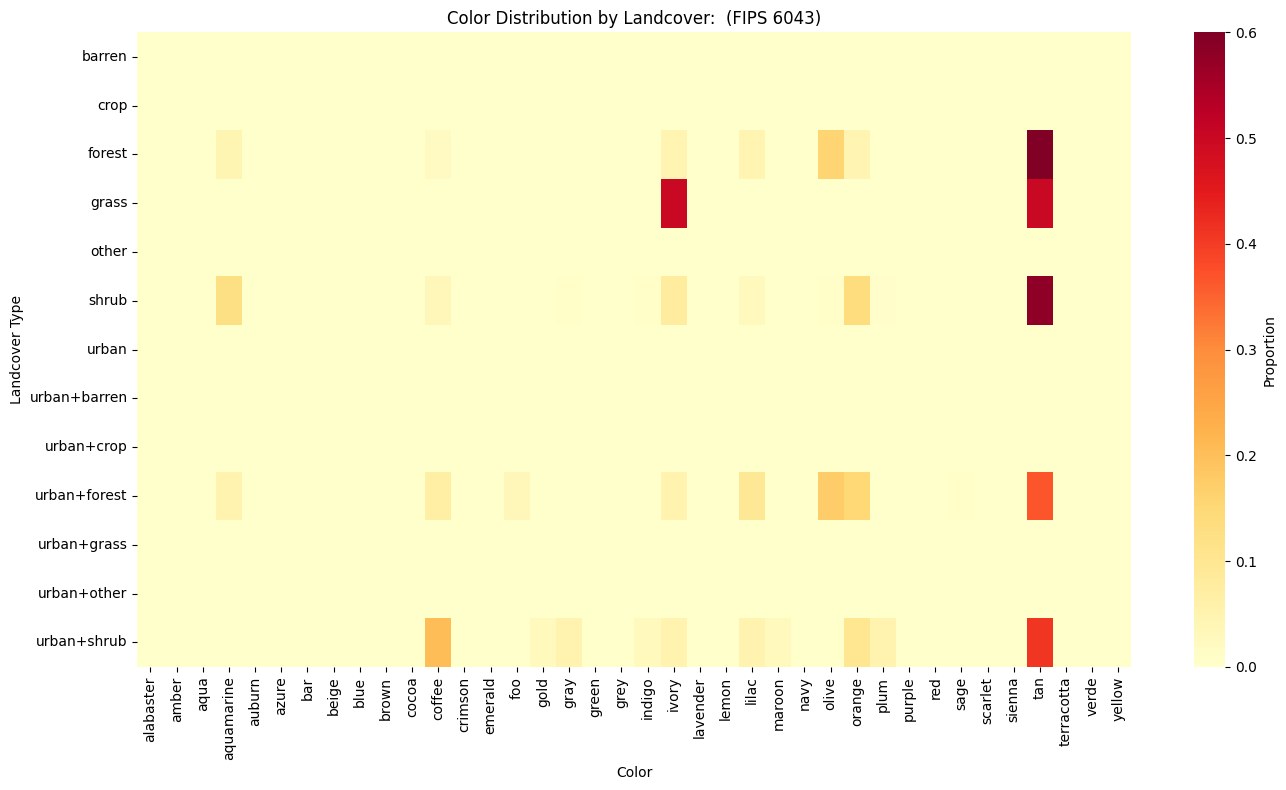

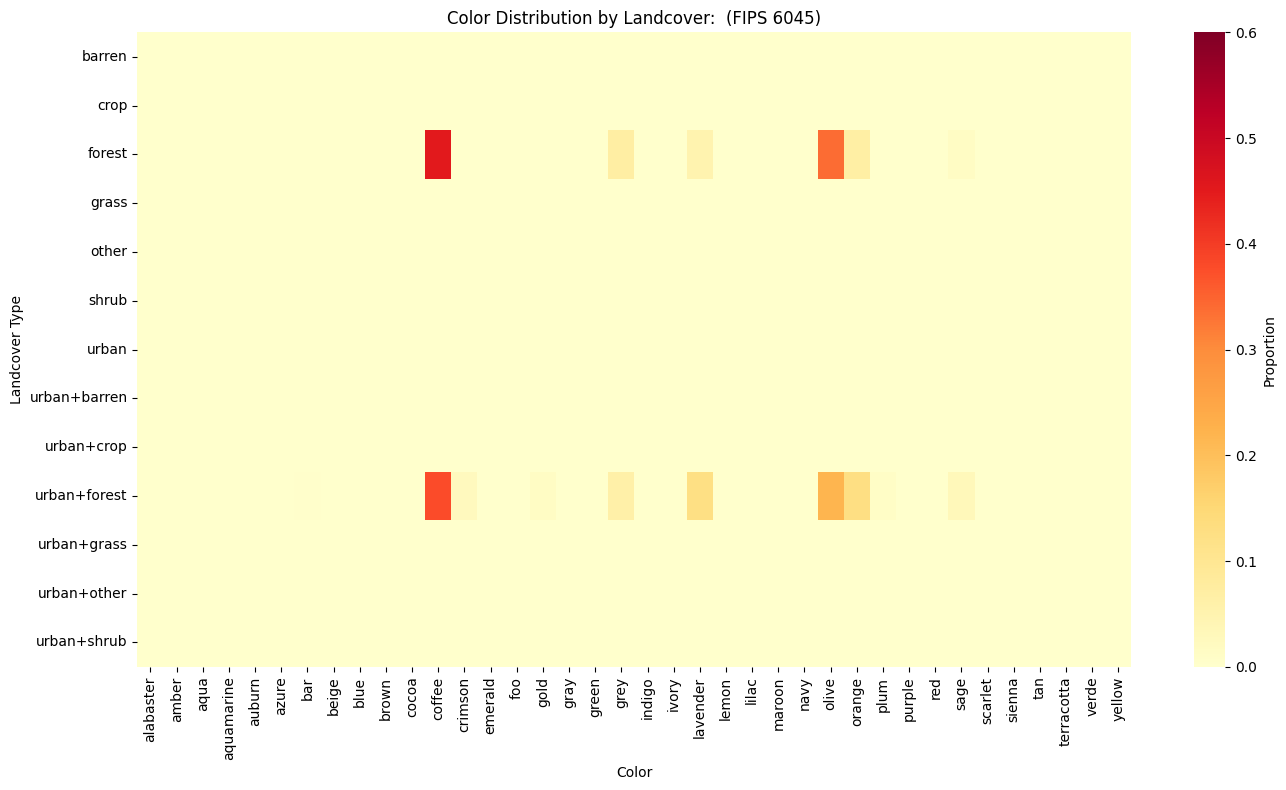

In [35]:
# heatmaps for all counties
for fips in list(df['fips'].unique()):
    plot_county_heatmap(fips)